# MSAAI 511 Final Project — MIDI Composer Classification





## Abstract

This project classifies classical MIDI compositions among four composers (Bach, Beethoven,
Chopin, Mozart) using 58 hand-engineered musical descriptors (pitch, rhythm, dynamics, harmony,
and instrumentation statistics) extracted per composition. A team-sourced imbalance-correction
effort added Beethoven/Chopin/Mozart compositions from several public MIDI collections, improving
the Bach:Chopin train-set ratio from roughly 7.5:1 to 3.2:1. Two neural architectures — a 1D CNN
treating the feature vector as an ordered sequence, and an LSTM treating each composition as a
single-timestep gated classifier — are trained with class-weighted loss and evaluated on a
held-out test set with accuracy, macro-averaged precision/recall/F1, ROC-AUC, confusion matrices,
permutation feature importance, and SHAP. The CNN is the stronger model on this feature
representation; per-class results show the imbalance correction, not architecture choice, drives
most of the improvement over the original single-source dataset.

## Project description

- **Problem**: 4-way composer classification from MIDI files, framed as a supervised
  classification task over per-composition numeric features (not raw audio or symbolic sequences).
- **Dataset provenance**: an original `midiclassics` corpus plus 8 additional harvested sources
  (Hugging Face datasets, Kaggle, piano-midi.de, Wikimedia Commons, and others), deduplicated by a
  MIDI-signature fingerprint before feature extraction.
- **Feature schema**: 63 CSV columns per composition — 3 identifiers (`composer`, `filename`,
  `relative_path`) plus 60 numeric descriptors covering pitch/pitch-class statistics, rhythm and
  timing, dynamics (velocity), harmony (chord counts), polyphony, and General MIDI instrumentation.
- **Modeling approach**: 1D CNN vs. LSTM over the standardized 58-feature vector (2 columns are
  constant in the training split and dropped), class-weighted training, held-out test evaluation.
- **Headline result**: see Section 15 (Consolidated Observations) for the numbers from this run.


## Table of contents

0. Front matter (this section) &nbsp;&nbsp; 
1. Environment & configuration &nbsp;&nbsp;
2. Data acquisition &nbsp;&nbsp; 
3. Feature extraction &nbsp;&nbsp; 
4. Data cleaning & dedup &nbsp;&nbsp;
5. Incremental feature generation &nbsp;&nbsp; 
6. Merge & validation &nbsp;&nbsp;
7. Exploratory data analysis &nbsp;&nbsp; 
8. Preprocessing & scaling &nbsp;&nbsp;
9. Model building &nbsp;&nbsp; 
10. Model training &nbsp;&nbsp; 
11. Held-out test evaluation &nbsp;&nbsp;
12. Extended evaluation (test vs. validation) &nbsp;&nbsp;
13. Hyperparameter tuning &nbsp;&nbsp; 
14. Reproducibility & metric reconciliation &nbsp;&nbsp;
15. Consolidated observations &nbsp;&nbsp; 
16. Conclusion &nbsp;&nbsp; 
17. Limitations & future work &nbsp;&nbsp;
18. Attribution & reproducibility manifest

## 1. Environment & Global Configuration

This section establishes the runtime environment and shared configuration used throughout the
notebook, so that later sections can assume a consistent, reproducible starting state.

- **Library imports and global seeding.** All third-party libraries used across the notebook
  (pandas, NumPy, TensorFlow/Keras, scikit-learn, Keras Tuner, seaborn/matplotlib) are imported
  once at the top, and a single random seed (`SEED = 42`) is applied to Python's `random`, NumPy,
  `PYTHONHASHSEED`, and TensorFlow's global seed, so that results are reproducible across
  notebook restarts.
- **Shared plotting style.** A single seaborn theme and pandas display format are set once for
  the entire notebook, avoiding inconsistent plot styling between sections originally authored
  separately.
- **Path constants and output directories.** Paths to the feature CSVs, split plan, and a
  dedicated output folder (`final_submission_outputs_tuned_v2/`) are defined, keeping this run's
  artifacts separate from prior standalone-notebook runs used later for reconciliation
  (Section 14).
- **Preflight data-availability audit.** Presence of the original feature CSVs, harvested
  feature CSVs, combined feature CSVs, split plan, and raw MIDI folders is checked
  programmatically, determining which downstream sections (2-5) can be live-executed versus
  documented as reference-only code.

In [1]:
"""Environment setup and global configuration for the consolidated submission notebook.

Combines the import lists of all three authors' original notebooks (deduplicated), sets a
single global random seed, and defines shared path/logging utilities used throughout.
"""
import hashlib
import json
import os
import random
import shutil
import sys
from datetime import datetime
import warnings
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore", category=FutureWarning)

# One shared plot style for the whole notebook (Jacob's EDA and Beakal's evaluation cells
# each set a different style independently in their source notebooks; picking one here
# avoids the later one silently overriding the earlier one mid-notebook).
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Python/TensorFlow environment:")
print("  TensorFlow:", tf.__version__)
print("  scikit-learn features available:", True)
print("  GPU devices:", tf.config.list_physical_devices("GPU"))


def log(stage, message):
    """Print a timestamped, stage-labeled log line.

    Used to bracket sections of original authors' code with explanatory context, without
    editing their function bodies. Google-style docstring per project documentation standard.

    Args:
        stage: Short section label, e.g. "SECTION 6 (Jacob)".
        message: Human-readable status message.
    """
    print(f"[{stage}] {message}")

Python/TensorFlow environment:
  TensorFlow: 2.21.0
  scikit-learn features available: True
  GPU devices: []


In [2]:
# Resolve the repository root even when this notebook is opened from final_submission/.
LAUNCH_DIR = Path.cwd().resolve()

def find_repo_root(start_dir):
    """Return the nearest parent that contains this project's data and submission folders."""
    for candidate in (start_dir, *start_dir.parents):
        if (candidate / "data").is_dir() and (candidate / "final_submission").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root. Open this notebook from within the project folder."
    )

REPO_ROOT = find_repo_root(LAUNCH_DIR)
# Source data-preparation cells use paths such as data/...; make them reliable regardless
# of the directory from which Jupyter was launched.
os.chdir(REPO_ROOT)
PROJECT_ROOT = REPO_ROOT
FINAL_SUBMISSION_DIR = REPO_ROOT / "final_submission"
TRAINING_PROJECT_DIR = REPO_ROOT / "composer_model_project"
FEATURE_DIR = REPO_ROOT / "data" / "features"
ORIGINAL_FEATURE_DIR = FEATURE_DIR / "original features"
SPLIT_PLAN_PATH = REPO_ROOT / "data" / "split_plans" / "candidate_split_plan.csv"
RUN_LABEL = "tuned"
# Keep downloads opt-in: the required local source folders are already present.
RUN_DOWNLOADS = False
# Set True before Run All to save copies of CSV inputs and the split plan before Sections 3-6 rewrite them.
BACKUP_DATA_FILES = False
OUTPUT_DIR = FINAL_SUBMISSION_DIR / f"final_submission_outputs_{RUN_LABEL}_v2"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_OUTPUT_DIR = OUTPUT_DIR
ARTIFACT_DIR = OUTPUT_DIR / "models"
ARTIFACT_DIR.mkdir(exist_ok=True)
BASELINE_METRICS_DIR = REPO_ROOT / "model_evaluation" / "evaluation_outputs"
BASELINE_TUNED_METRICS_DIR = REPO_ROOT / "model_evaluation" / "evaluation_outputs_tuned"
log("SECTION 1", f"PROJECT_ROOT={PROJECT_ROOT}")
log("SECTION 1", f"REPO_ROOT={REPO_ROOT}")
log("SECTION 1", f"Model outputs will be written to {MODEL_OUTPUT_DIR}")


[SECTION 1] PROJECT_ROOT=C:\Users\Maxtw\OneDrive\Desktop\511 Project
[SECTION 1] REPO_ROOT=C:\Users\Maxtw\OneDrive\Desktop\511 Project
[SECTION 1] Model outputs will be written to C:\Users\Maxtw\OneDrive\Desktop\511 Project\final_submission\final_submission_outputs_tuned_v2


## Raw MIDI archive restoration

The raw MIDI inputs are distributed as `data_archives/midiclassics.zip` and `data_archives/new_midi_files.zip`. This cell restores an archive only when its matching directory under `data/` is absent; existing local raw-data folders are never overwritten. After restoration, run Sections 3-7 for data preparation. Sections 8-13 train/evaluate models and are not needed to prepare the data.



In [3]:
RAW_ARCHIVE_DIR = REPO_ROOT / "data_archives"
RAW_ARCHIVES = {
    "midiclassics": RAW_ARCHIVE_DIR / "midiclassics.zip",
    "new_midi_files": RAW_ARCHIVE_DIR / "new_midi_files.zip",
}

def restore_raw_midi_archive(dataset_name, archive_path):
    """Extract one trusted project archive only when its destination directory is absent."""
    destination = REPO_ROOT / "data" / dataset_name
    if destination.is_dir():
        print(f"Using existing raw-data directory: {destination}")
        return
    if not archive_path.is_file():
        raise FileNotFoundError(f"Missing raw-MIDI archive: {archive_path}")
    import zipfile
    destination.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(destination)
    print(f"Restored {dataset_name} from {archive_path}")

for _dataset, _archive in RAW_ARCHIVES.items():
    restore_raw_midi_archive(_dataset, _archive)


Using existing raw-data directory: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\midiclassics
Using existing raw-data directory: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\new_midi_files


In [4]:
"""Preflight data-availability audit.

Checks that the local raw-MIDI inputs required for the runnable ingestion and feature
generation stages are available.
"""
def check_path(label, path):
    exists = Path(path).exists()
    print(f"  [{'OK' if exists else 'MISSING'}] {label}: {path}")
    return exists

print("Data-availability audit:")
HAS_ORIGINAL_FEATURES = check_path("original features CSVs", ORIGINAL_FEATURE_DIR / "train_features.csv")
HAS_NEW_FEATURES = check_path("new feature CSVs", FEATURE_DIR / "new_train_features.csv")
HAS_COMBINED_FEATURES = check_path("combined feature CSVs", FEATURE_DIR / "combined_train_features.csv")
HAS_SPLIT_PLAN = check_path("candidate split plan", SPLIT_PLAN_PATH)
HAS_RAW_MIDICLASSICS = check_path("data/midiclassics/ (original raw MIDI)", REPO_ROOT / "data" / "midiclassics")
HAS_RAW_NEW_MIDI = check_path("data/new_midi_files/ (harvested raw MIDI)", REPO_ROOT / "data" / "new_midi_files")

Data-availability audit:
  [OK] original features CSVs: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\original features\train_features.csv
  [OK] new feature CSVs: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\new_train_features.csv
  [OK] combined feature CSVs: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\combined_train_features.csv
  [OK] candidate split plan: C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\split_plans\candidate_split_plan.csv
  [OK] data/midiclassics/ (original raw MIDI): C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\midiclassics
  [OK] data/new_midi_files/ (harvested raw MIDI): C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\new_midi_files


In [5]:
# Optional backup before source-notebook Sections 3-6 rewrite shared CSVs and the split plan.
if BACKUP_DATA_FILES:
    backup_dir = REPO_ROOT / "run_backups" / datetime.now().strftime("%Y%m%d_%H%M%S")
    targets = [
        SPLIT_PLAN_PATH,
        *[ORIGINAL_FEATURE_DIR / f"{split}_features.csv" for split in ("train", "dev", "test")],
        *[FEATURE_DIR / f"new_{split}_features.csv" for split in ("train", "dev", "test")],
        *[FEATURE_DIR / f"combined_{split}_features.csv" for split in ("train", "dev", "test")],
    ]
    for path in targets:
        if path.is_file():
            destination = backup_dir / path.relative_to(REPO_ROOT)
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(path, destination)
    print(f"Backed up existing data artifacts to {backup_dir}")
else:
    print("Backup disabled. Set BACKUP_DATA_FILES = True before Run All to preserve current CSV artifacts.")


Backup disabled. Set BACKUP_DATA_FILES = True before Run All to preserve current CSV artifacts.


## Run order, safety, and expected duration

Run the notebook from the repository root with its dedicated Python kernel. Sections 3-6 intentionally follow the source notebooks and rewrite shared CSVs under `data/`; set `BACKUP_DATA_FILES = True` first if the current artifacts must be preserved. Section 2 is opt-in (`RUN_DOWNLOADS = False` by default) because it requires network access and can be rate-limited. Section 5 may reuse cached rows. To share or regenerate only prepared data, run through Section 7 and stop; Sections 8-13, including the long Hyperband search, are unnecessary.



## 2. Data Acquisition

**Source: `notebooks/huggingface.ipynb`**

This section reproduces the three Hugging Face downloads used to add Beethoven, Chopin, and Mozart MIDI files. Downloads are stored in `data/new_midi_files/`; Section 4 scans every source folder present there, including locally supplied collections.


In [6]:
if RUN_DOWNLOADS:
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="anusfoil/chopin-comp-midi",
        repo_type="dataset",
        allow_patterns="data/**",
        local_dir="data/new_midi_files/chopin-comp-midi"
    )
else:
    print("Skipping optional Hugging Face download; using local data/new_midi_files contents.")


Skipping optional Hugging Face download; using local data/new_midi_files contents.


In [7]:
if RUN_DOWNLOADS:
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="drengskapur/midi-classical-music",
        repo_type="dataset",
        allow_patterns="data/**",
        local_dir="data/new_midi_files/midi-classical-music"
    )
else:
    print("Skipping optional Hugging Face download; using local data/new_midi_files contents.")


Skipping optional Hugging Face download; using local data/new_midi_files contents.


In [8]:
if RUN_DOWNLOADS:
    from huggingface_hub import snapshot_download

    snapshot_download(
        repo_id="EliMasonTech/BigSynthPiano",
        repo_type="dataset",
        allow_patterns=["midi/Beethoven*.mid", "midi/Beethoven*.midi"],
        local_dir="data/new_midi_files/BigSynthPiano"
    )
else:
    print("Skipping optional Hugging Face download; using local data/new_midi_files contents.")


Skipping optional Hugging Face download; using local data/new_midi_files contents.


## 3. Original MIDI Feature Extraction

**Source: `notebooks/MIDI_Extract.ipynb`**

This section reproduces the canonical-corpus feature workflow. It creates the initial split CSVs only if absent, then enriches them with the remaining MIDI-level descriptors.


In [9]:
import os
import pandas as pd
import numpy as np

import music21
import pretty_midi
from music21 import converter, chord

In [10]:
BASE_DIR = "data/midiclassics"
OUTPUT_DIR = "data/features/original features"
SPLIT_RATIOS = {"train": 0.70, "dev": 0.15, "test": 0.15}

COMPOSERS = [
    "Bach",
    "Beethoven",
    "Chopin",
    "Mozart"
]

def extract_features(filepath, composer):
    try:
        midi = pretty_midi.PrettyMIDI(filepath)

        notes = []
        durations = []
        velocities = []

        for instrument in midi.instruments:
            for note in instrument.notes:
                notes.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)

        if len(notes) == 0:
            return None

        tempo = midi.estimate_tempo()

        pitch_hist = midi.get_pitch_class_histogram()

        note_density = len(notes) / midi.get_end_time()

        avg_pitch = np.mean(notes)
        pitch_range = np.max(notes) - np.min(notes)
        avg_duration = np.mean(durations)
        avg_velocity = np.mean(velocities)

        ####################################################
        # Count chords using music21
        ####################################################

        score = converter.parse(filepath)

        chords = score.chordify()

        chord_count = 0

        for c in chords.recurse().getElementsByClass(chord.Chord):
            chord_count += 1

        ####################################################

        features = {
            "composer": composer,
            "filename": os.path.basename(filepath),
            "tempo": tempo,
            "num_notes": len(notes),
            "num_chords": chord_count,
            "avg_pitch": avg_pitch,
            "pitch_range": pitch_range,
            "avg_duration": avg_duration,
            "avg_velocity": avg_velocity,
            "note_density": note_density,
        }

        for i in range(12):
            features[f"pitch_class_{i}"] = pitch_hist[i]

        return features

    except Exception as e:
        print(f"Error reading {filepath}")
        print(e)
        return None


def split_files(files, rng):
    files = list(files)
    rng.shuffle(files)

    train_end = int(len(files) * SPLIT_RATIOS["train"])
    dev_end = train_end + int(len(files) * SPLIT_RATIOS["dev"])

    return {
        "train": files[:train_end],
        "dev": files[train_end:dev_end],
        "test": files[dev_end:],
    }


def process_dataset():
    rows_by_split = {split: [] for split in SPLIT_RATIOS}
    rng = np.random.default_rng(42)

    for composer in COMPOSERS:
        composer_folder = os.path.join(BASE_DIR, composer)
        midi_files = [
            os.path.join(root, file)
            for root, _, files in os.walk(composer_folder)
            for file in files
            if file.lower().endswith((".mid", ".midi"))
        ]

        if not midi_files:
            print(f"No MIDI files found for {composer}; skipping.")
            continue

        print(f"Processing {composer}: {len(midi_files)} files")
        for split, files in split_files(midi_files, rng).items():
            for filepath in files:
                features = extract_features(filepath, composer)
                if features is not None:
                    rows_by_split[split].append(features)

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for split, rows in rows_by_split.items():
        output = os.path.join(OUTPUT_DIR, f"{split}_features.csv")
        pd.DataFrame(rows).to_csv(output, index=False)
        print(f"Saved {len(rows)} rows to {output}")


expected_splits = [os.path.join(OUTPUT_DIR, f"{split}_features.csv") for split in SPLIT_RATIOS]
if all(os.path.exists(path) for path in expected_splits):
    print("Existing feature CSVs found; skipping base extraction and preserving current splits.")
else:
    process_dataset()

Existing feature CSVs found; skipping base extraction and preserving current splits.


In [11]:
# Enrich existing split CSVs without recreating or re-splitting them.
import mido

GM_FAMILIES = [
    "piano", "chromatic_percussion", "organ", "guitar",
    "bass", "strings", "ensemble", "brass",
    "reed", "pipe", "synth_lead", "synth_pad",
    "synth_effects", "ethnic", "percussive", "sound_effects",
]

def value_is_missing(value):
    if pd.isna(value):
        return True
    return isinstance(value, str) and not value.strip()

def column_is_complete(df, column):
    return column in df.columns and not df[column].map(value_is_missing).any()

def set_missing_values(df, column, values):
    if column not in df.columns:
        df[column] = values
        return
    missing = df[column].map(value_is_missing)
    if missing.any():
        df.loc[missing, column] = values.loc[missing]

def add_dataframe_features(df):
    """Add derived features only when a column is missing or incomplete."""
    pitch_columns = [f"pitch_class_{i}" for i in range(12)]
    pitch_values = df[pitch_columns].to_numpy(dtype=float)
    pitch_probabilities = pitch_values / (pitch_values.sum(axis=1, keepdims=True) + 1e-10)
    chromatic_indices = [1, 3, 6, 8, 10]

    derived = {
        "pitch_entropy": -np.sum(pitch_probabilities * np.log(pitch_probabilities + 1e-10), axis=1),
        "pitch_class_variance": np.var(pitch_values, axis=1),
        "range_normalized": df["pitch_range"] / (df["avg_pitch"] + 1e-6),
        "notes_per_chord": df["num_notes"] / (df["num_chords"] + 1),
        "chord_density": df["num_chords"] / (df["num_notes"] + 1),
        "velocity_variation": df["avg_velocity"] / (df["tempo"] + 1),
        "tempo_note_ratio": df["tempo"] / (df["num_notes"] + 1),
        "chromatic_ratio": pitch_values[:, chromatic_indices].sum(axis=1) / (pitch_values.sum(axis=1) + 1e-6),
    }
    for column, values in derived.items():
        if not column_is_complete(df, column):
            set_missing_values(df, column, pd.Series(values, index=df.index))

def build_midi_index():
    """Map each unique (composer, filename) pair to its source MIDI path."""
    index = {}
    for composer in COMPOSERS:
        composer_folder = os.path.join(BASE_DIR, composer)
        for root, _, files in os.walk(composer_folder):
            for filename in files:
                if not filename.lower().endswith((".mid", ".midi")):
                    continue
                key = (composer, filename.casefold())
                if key in index:
                    raise ValueError(f"Duplicate source filename for {composer}: {filename}")
                index[key] = os.path.join(root, filename)
    return index

def calculate_midi_features(filepath):
    """Extract fast MIDI-level descriptors; this deliberately skips music21 chordification."""
    midi = pretty_midi.PrettyMIDI(filepath)
    note_tracks = [instrument for instrument in midi.instruments if instrument.notes]
    notes = [note for instrument in note_tracks for note in instrument.notes]
    if not notes:
        raise ValueError("No notes found")

    pitches = np.array([note.pitch for note in notes], dtype=float)
    velocities = np.array([note.velocity for note in notes], dtype=float)
    durations = np.array([note.end - note.start for note in notes], dtype=float)
    onsets = np.sort(np.array([note.start for note in notes], dtype=float))
    onset_intervals = np.diff(onsets)
    total_duration = midi.get_end_time()

    events = sorted(
        [(note.start, 1) for note in notes] + [(note.end, -1) for note in notes],
        key=lambda event: event[0],
    )
    active_notes = 0
    max_polyphony = 0
    weighted_polyphony = 0.0
    previous_time = events[0][0]
    event_index = 0
    while event_index < len(events):
        event_time = events[event_index][0]
        weighted_polyphony += active_notes * (event_time - previous_time)
        while event_index < len(events) and events[event_index][0] == event_time:
            active_notes += events[event_index][1]
            event_index += 1
        max_polyphony = max(max_polyphony, active_notes)
        previous_time = event_time

    features = {
        "relative_path": os.path.relpath(filepath, BASE_DIR),
        "total_duration": total_duration,
        "num_midi_tracks": len(mido.MidiFile(filepath).tracks),
        "num_note_tracks": len(note_tracks),
        "num_unique_programs": len({instrument.program for instrument in note_tracks if not instrument.is_drum}),
        "drum_track_count": sum(instrument.is_drum for instrument in note_tracks),
        "has_drums": int(any(instrument.is_drum for instrument in note_tracks)),
        "pitch_std": np.std(pitches),
        "pitch_median": np.median(pitches),
        "velocity_std": np.std(velocities),
        "velocity_range": np.ptp(velocities),
        "duration_std": np.std(durations),
        "duration_median": np.median(durations),
        "onset_interval_mean": np.mean(onset_intervals) if len(onset_intervals) else 0.0,
        "onset_interval_std": np.std(onset_intervals) if len(onset_intervals) else 0.0,
        "max_polyphony": max_polyphony,
        "avg_polyphony": weighted_polyphony / total_duration if total_duration else 0.0,
    }
    for family in GM_FAMILIES:
        features["gm_" + family + "_track_count"] = 0
    for instrument in note_tracks:
        if not instrument.is_drum:
            features["gm_" + GM_FAMILIES[instrument.program // 8] + "_track_count"] += 1
    return features

def enrich_existing_csvs():
    split_paths = [os.path.join(OUTPUT_DIR, f"{split}_features.csv") for split in ["train", "dev", "test"]]
    dataframes = {csv_path: pd.read_csv(csv_path) for csv_path in split_paths}

    for df in dataframes.values():
        add_dataframe_features(df)

    midi_columns = [
        "relative_path", "total_duration", "num_midi_tracks", "num_note_tracks",
        "num_unique_programs", "drum_track_count", "has_drums", "pitch_std",
        "pitch_median", "velocity_std", "velocity_range", "duration_std",
        "duration_median", "onset_interval_mean", "onset_interval_std",
        "max_polyphony", "avg_polyphony",
        *["gm_" + family + "_track_count" for family in GM_FAMILIES],
    ]
    needed_columns = [
        column for column in midi_columns
        if not all(column_is_complete(df, column) for df in dataframes.values())
    ]

    if needed_columns:
        print(f"Calculating missing or incomplete MIDI columns: {needed_columns}")
        midi_index = build_midi_index()
        for df in dataframes.values():
            for row_index, row in df[["composer", "filename"]].iterrows():
                missing_columns = [
                    column for column in needed_columns
                    if not column_is_complete(df.iloc[[row_index]], column)
                ]
                if not missing_columns:
                    continue
                filepath = midi_index.get((row["composer"], row["filename"].casefold()))
                if filepath is None:
                    raise FileNotFoundError(f"No source MIDI found for {row['composer']}: {row['filename']}")
                features = calculate_midi_features(filepath)
                for column in missing_columns:
                    df.at[row_index, column] = features[column]
    else:
        print("All MIDI enrichment columns are already complete; skipping MIDI parsing.")

    for csv_path, df in dataframes.items():
        df.to_csv(csv_path, index=False)
        print(f"Saved {csv_path}: {df.shape[1]} columns")

enrich_existing_csvs()


All MIDI enrichment columns are already complete; skipping MIDI parsing.
Saved data/features/original features\train_features.csv: 63 columns
Saved data/features/original features\dev_features.csv: 63 columns
Saved data/features/original features\test_features.csv: 63 columns


In [12]:
# Restore the consolidated notebook model-output directory.
OUTPUT_DIR = MODEL_OUTPUT_DIR


## 4. Data Cleaning: Deduplication & Split Planning

**Source: `notebooks/MIDI_Ingest.ipynb`**

Every source folder in `data/new_midi_files/` is scanned. Beethoven, Chopin, and Mozart candidates are fingerprinted, duplicates are removed against the canonical corpus and across candidate sources, and accepted files receive deterministic train/dev/test assignments.


In [13]:
from pathlib import Path
import hashlib

import pandas as pd
import pretty_midi

COMPOSERS = ('Beethoven', 'Chopin', 'Mozart')
PREFERRED_DIRS = {composer: Path('data/midiclassics') / composer for composer in COMPOSERS}
NEW_DATA_DIR = Path('data/new_midi_files')
MIDI_SUFFIXES = {'.mid', '.midi'}
SPLIT_PLAN_PATH = Path('data/split_plans/candidate_split_plan.csv')


In [14]:
def midi_files(directory):
    return sorted(path for path in directory.rglob('*') if path.is_file() and path.suffix.casefold() in MIDI_SUFFIXES)

def source_folders():
    if not NEW_DATA_DIR.is_dir():
        raise FileNotFoundError(f'Create the new-data folder first: {NEW_DATA_DIR.resolve()}')
    return sorted((path for path in NEW_DATA_DIR.iterdir() if path.is_dir()), key=lambda path: path.name.casefold())

def composer_from_path(path):
    parts = [path.stem, *path.relative_to(NEW_DATA_DIR).parts[:-1]]
    normalized_parts = [part.casefold() for part in parts]
    for composer in COMPOSERS:
        name = composer.casefold()
        if any(name == part or name in part for part in normalized_parts):
            return composer
    return None

def feature_record(path, source, composer):
    midi = pretty_midi.PrettyMIDI(str(path))
    duration = midi.get_end_time()
    num_notes = sum(len(instrument.notes) for instrument in midi.instruments)
    if duration <= 0 or num_notes == 0:
        raise ValueError('MIDI has no timed notes')
    tempo = midi.estimate_tempo()
    notes_per_second = num_notes / duration
    signature = (round(duration, 6), round(tempo, 6), num_notes, round(notes_per_second, 9))
    return {'source': source, 'composer': composer, 'path': path, 'total_duration': duration,
            'estimated_tempo': tempo, 'num_notes': num_notes, 'notes_per_second': notes_per_second,
            'feature_signature': signature}

def collect_records(directory, source, fixed_composer=None):
    records, errors, ignored = [], [], []
    for path in midi_files(directory):
        composer = fixed_composer or composer_from_path(path)
        if composer not in COMPOSERS:
            ignored.append({'source': source, 'path': str(path), 'reason': 'composer_not_identified'})
            continue
        try:
            records.append(feature_record(path, source, composer))
        except Exception as error:
            errors.append({'source': source, 'composer': composer, 'path': str(path), 'error': str(error)})
    return records, errors, ignored

def assigned_split(composer, signature):
    value = int(hashlib.sha256(repr((composer, signature)).encode()).hexdigest()[:8], 16) % 100
    return 'train' if value < 70 else 'dev' if value < 85 else 'test'


In [15]:
preferred_by_key, errors = {}, []
for composer, directory in PREFERRED_DIRS.items():
    records, source_errors, _ = collect_records(directory, 'midiclassics', composer)
    errors.extend(source_errors)
    for record in records:
        preferred_by_key.setdefault((composer, record['feature_signature']), []).append(record['path'])

candidate_by_key, ignored = {}, []
for source_directory in source_folders():
    source = source_directory.name
    records, source_errors, source_ignored = collect_records(source_directory, source)
    errors.extend(source_errors)
    ignored.extend(source_ignored)
    for record in records:
        candidate_by_key.setdefault((record['composer'], record['feature_signature']), []).append(record)

priority = {source: rank for rank, source in enumerate(sorted({record['source'] for records in candidate_by_key.values() for record in records}, key=str.casefold))}
plan = []
for (composer, signature), records in candidate_by_key.items():
    records.sort(key=lambda record: (priority[record['source']], str(record['path']).casefold()))
    preferred_paths = preferred_by_key.get((composer, signature), [])
    keeper = None if preferred_paths else records[0]
    for record in records:
        if preferred_paths:
            status, duplicate_of, split = 'duplicate_of_midiclassics', ' | '.join(map(str, preferred_paths)), None
        elif record is keeper:
            status, duplicate_of, split = ('keep_unique' if len(records) == 1 else 'keep_candidate_representative'), '', assigned_split(composer, signature)
        else:
            status, duplicate_of, split = 'duplicate_of_candidate', str(keeper['path']), None
        plan.append({'source': record['source'], 'composer': composer, 'path': str(record['path']),
                     'status': status, 'duplicate_of': duplicate_of, 'recommended_split': split,
                     'total_duration': record['total_duration'], 'estimated_tempo': record['estimated_tempo'],
                     'num_notes': record['num_notes'], 'notes_per_second': record['notes_per_second']})

report = pd.DataFrame(plan).sort_values(['composer', 'status', 'source', 'path'], ignore_index=True)
error_report = pd.DataFrame(errors)
ignored_report = pd.DataFrame(ignored)
SPLIT_PLAN_PATH.parent.mkdir(parents=True, exist_ok=True)
report.to_csv(SPLIT_PLAN_PATH, index=False)
display(report)
display(report.groupby(['composer', 'status']).size().rename('files').to_frame())
display(error_report)
display(ignored_report)
print(f'Scanned {len(source_folders()):,} source folders; saved {len(report):,} planned files to {SPLIT_PLAN_PATH}. No MIDI files were deleted.')


c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\pretty_midi\pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


,source,composer,path,status,duplicate_of,recommended_split,total_duration,estimated_tempo,num_notes,notes_per_second
0,BigSynthPiano,Beethoven,data\new_midi_files\BigSynthPiano\midi\Beethov...,duplicate_of_candidate,data\new_midi_files\BigSynthPiano\midi\Beethov...,NaN,15.994,180.000,255,15.943
1,BigSynthPiano,Beethoven,data\new_midi_files\BigSynthPiano\midi\Beethov...,duplicate_of_candidate,data\new_midi_files\BigSynthPiano\midi\Beethov...,NaN,22.140,82.105,66,2.981
2,BigSynthPiano,Beethoven,data\new_midi_files\BigSynthPiano\midi\Beethov...,duplicate_of_candidate,data\new_midi_files\BigSynthPiano\midi\Beethov...,NaN,14.399,200.000,172,11.945
3,BigSynthPiano,Beethoven,data\new_midi_files\BigSynthPiano\midi\Beethov...,duplicate_of_candidate,data\new_midi_files\BigSynthPiano\midi\Beethov...,NaN,13.083,220.000,131,10.013
4,BigSynthPiano,Beethoven,data\new_midi_files\BigSynthPiano\midi\Beethov...,duplicate_of_candidate,data\new_midi_files\BigSynthPiano\midi\Beethov...,NaN,13.076,220.000,224,17.130
...,...,...,...,...,...,...,...,...,...,...
1324,midisheetmusic.com,Mozart,data\new_midi_files\midisheetmusic.com\Mozart\...,keep_unique,,dev,97.998,216.451,828,8.449
1325,midisheetmusic.com,Mozart,data\new_midi_files\midisheetmusic.com\Mozart\...,keep_unique,,train,214.393,187.226,1009,4.706
1326,midisheetmusic.com,Mozart,data\new_midi_files\midisheetmusic.com\Mozart\...,keep_unique,,test,100.797,130.435,660,6.548
1327,midisheetmusic.com,Mozart,data\new_midi_files\midisheetmusic.com\Mozart\...,keep_unique,,train,153.597,196.629,1608,10.469


files
composer  status                              
Beethoven duplicate_of_candidate             7
          duplicate_of_midiclassics        220
          keep_candidate_representative      7
          keep_unique                      290
Chopin    duplicate_of_candidate            40
          duplicate_of_midiclassics        155
          keep_candidate_representative     40
          keep_unique                      145
Mozart    duplicate_of_candidate            39
          duplicate_of_midiclassics        257
          keep_candidate_representative     39
          keep_unique                       90

,source,composer,path,error
0,midiclassics,Beethoven,data\midiclassics\Beethoven\Anhang 14-3.mid,Could not decode key with 3 flats and mode 255
1,midiclassics,Mozart,data\midiclassics\Mozart\Piano Sonatas\Nueva c...,Could not decode key with 2 flats and mode 2
2,commons.wikimedia.org,Beethoven,data\new_midi_files\commons.wikimedia.org\Beet...,0 is not a valid `numerator` type or value
3,commons.wikimedia.org,Beethoven,data\new_midi_files\commons.wikimedia.org\Beet...,0 is not a valid `numerator` type or value
4,commons.wikimedia.org,Beethoven,data\new_midi_files\commons.wikimedia.org\Beet...,Could not decode key with 8 sharps and mode 0
5,commons.wikimedia.org,Chopin,data\new_midi_files\commons.wikimedia.org\Chop...,Could not decode key with 8 flats and mode 1
6,midi-classical-music,Beethoven,data\new_midi_files\midi-classical-music\data\...,Could not decode key with 3 flats and mode 255
7,midi-classical-music,Mozart,data\new_midi_files\midi-classical-music\data\...,Could not decode key with 2 flats and mode 2


,source,path,reason
0,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
1,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
2,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
3,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
4,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
...,...,...,...
2103,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
2104,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
2105,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified
2106,midi-classical-music,data\new_midi_files\midi-classical-music\data\...,composer_not_identified


Scanned 8 source folders; saved 1,329 planned files to data\split_plans\candidate_split_plan.csv. No MIDI files were deleted.


## 5. Incremental Feature Generation for Added MIDI

**Source: `notebooks/Generate_New_MIDI_Features.ipynb`**

Accepted candidates from Section 4 are converted into the same feature schema as the original corpus. Existing new-feature rows are reused; only uncached accepted MIDI files are parsed.


In [16]:
from pathlib import Path
import time

import mido
import numpy as np
import pandas as pd
import pretty_midi
from music21 import chord, converter

SPLIT_PLAN_PATH = Path('data/split_plans/candidate_split_plan.csv')
DATA_DIR = Path('data')
ORIGINAL_FEATURE_PATH = DATA_DIR / 'features/original features/train_features.csv'
NEW_FEATURE_PATHS = {split: DATA_DIR / f'features/new_{split}_features.csv' for split in ('train', 'dev', 'test')}
FEATURE_COLUMNS = pd.read_csv(ORIGINAL_FEATURE_PATH, nrows=0).columns.tolist()
KEEP_STATUSES = {'keep_unique', 'keep_candidate_representative'}
GM_FAMILIES = ['piano', 'chromatic_percussion', 'organ', 'guitar', 'bass', 'strings', 'ensemble', 'brass', 'reed', 'pipe', 'synth_lead', 'synth_pad', 'synth_effects', 'ethnic', 'percussive', 'sound_effects']


In [17]:
def normalized_path(value):
    return str(value).replace('/', '\\').casefold()

def feature_key(composer, relative_path):
    return composer.casefold(), normalized_path(relative_path)

def relative_data_path(path):
    return str(path.resolve().relative_to(DATA_DIR.resolve()))

def extract_features(path, composer):
    midi = pretty_midi.PrettyMIDI(str(path))
    note_tracks = [instrument for instrument in midi.instruments if instrument.notes]
    notes = [note for instrument in note_tracks for note in instrument.notes]
    if not notes:
        raise ValueError('No notes found')
    pitches = np.array([note.pitch for note in notes], dtype=float)
    velocities = np.array([note.velocity for note in notes], dtype=float)
    durations = np.array([note.end - note.start for note in notes], dtype=float)
    onsets = np.sort(np.array([note.start for note in notes], dtype=float))
    total_duration = midi.get_end_time()
    chord_count = sum(1 for value in converter.parse(str(path)).chordify().recurse().getElementsByClass(chord.Chord))
    pitch_hist = midi.get_pitch_class_histogram()
    pitch_probabilities = pitch_hist / (pitch_hist.sum() + 1e-10)
    events = sorted([(note.start, 1) for note in notes] + [(note.end, -1) for note in notes], key=lambda event: event[0])
    active_notes = max_polyphony = event_index = 0
    weighted_polyphony, previous_time = 0.0, events[0][0]
    while event_index < len(events):
        event_time = events[event_index][0]
        weighted_polyphony += active_notes * (event_time - previous_time)
        while event_index < len(events) and events[event_index][0] == event_time:
            active_notes += events[event_index][1]
            event_index += 1
        max_polyphony = max(max_polyphony, active_notes)
        previous_time = event_time
    tempo = midi.estimate_tempo()
    features = {'composer': composer, 'filename': path.name, 'tempo': tempo, 'num_notes': len(notes),
        'num_chords': chord_count, 'avg_pitch': np.mean(pitches), 'pitch_range': np.ptp(pitches),
        'avg_duration': np.mean(durations), 'avg_velocity': np.mean(velocities), 'note_density': len(notes) / total_duration,
        'pitch_entropy': -np.sum(pitch_probabilities * np.log(pitch_probabilities + 1e-10)), 'pitch_class_variance': np.var(pitch_hist),
        'range_normalized': np.ptp(pitches) / (np.mean(pitches) + 1e-6), 'notes_per_chord': len(notes) / (chord_count + 1),
        'chord_density': chord_count / (len(notes) + 1), 'velocity_variation': np.mean(velocities) / (tempo + 1),
        'tempo_note_ratio': tempo / (len(notes) + 1), 'chromatic_ratio': pitch_hist[[1, 3, 6, 8, 10]].sum() / (pitch_hist.sum() + 1e-6),
        'relative_path': relative_data_path(path), 'total_duration': total_duration,
        'num_midi_tracks': len(mido.MidiFile(str(path)).tracks), 'num_note_tracks': len(note_tracks),
        'num_unique_programs': len({instrument.program for instrument in note_tracks if not instrument.is_drum}),
        'drum_track_count': sum(instrument.is_drum for instrument in note_tracks), 'has_drums': int(any(instrument.is_drum for instrument in note_tracks)),
        'pitch_std': np.std(pitches), 'pitch_median': np.median(pitches), 'velocity_std': np.std(velocities),
        'velocity_range': np.ptp(velocities), 'duration_std': np.std(durations), 'duration_median': np.median(durations),
        'onset_interval_mean': np.mean(np.diff(onsets)) if len(onsets) > 1 else 0.0,
        'onset_interval_std': np.std(np.diff(onsets)) if len(onsets) > 1 else 0.0,
        'max_polyphony': max_polyphony, 'avg_polyphony': weighted_polyphony / total_duration if total_duration else 0.0}
    for index, value in enumerate(pitch_hist): features[f'pitch_class_{index}'] = value
    for family in GM_FAMILIES: features[f'gm_{family}_track_count'] = 0
    for instrument in note_tracks:
        if not instrument.is_drum: features[f'gm_{GM_FAMILIES[instrument.program // 8]}_track_count'] += 1
    return features


In [18]:
if not SPLIT_PLAN_PATH.is_file():
    raise FileNotFoundError(f'Run MIDI_Ingest.ipynb first: {SPLIT_PLAN_PATH}')

plan = pd.read_csv(SPLIT_PLAN_PATH)
keepable = plan.loc[plan['status'].isin(KEEP_STATUSES)].copy()
keepable['relative_path'] = keepable['path'].map(lambda value: relative_data_path(Path(value)))
keepable['feature_key'] = [feature_key(composer, path) for composer, path in zip(keepable['composer'], keepable['relative_path'])]
if keepable['feature_key'].duplicated().any():
    raise ValueError('The plan contains duplicate keepable composer/path entries.')

cached_rows = {}
for split, output_path in NEW_FEATURE_PATHS.items():
    if not output_path.is_file():
        continue
    existing = pd.read_csv(output_path)
    if existing.columns.tolist() != FEATURE_COLUMNS:
        raise ValueError(f'Unexpected schema in {output_path}; expected the original feature columns.')
    for row in existing.to_dict('records'):
        cached_rows[feature_key(row['composer'], row['relative_path'])] = row

rows_by_split = {split: [] for split in NEW_FEATURE_PATHS}
missing = []
for row in keepable.itertuples(index=False):
    split = row.recommended_split
    cached = cached_rows.get(row.feature_key)
    if cached is not None:
        rows_by_split[split].append(cached)
    else:
        missing.append(row)

print(f'Keeping {len(keepable):,} planned rows; reusing {len(keepable) - len(missing):,}; extracting {len(missing):,} new rows.')


Keeping 611 planned rows; reusing 611; extracting 0 new rows.


In [19]:
errors = []
for index, row in enumerate(missing, start=1):
    path = Path(row.path)
    try:
        rows_by_split[row.recommended_split].append(extract_features(path, row.composer))
    except Exception as error:
        errors.append({'path': row.path, 'composer': row.composer, 'error': str(error)})
    if index % 10 == 0 or index == len(missing):
        print(f'Processed {index:,}/{len(missing):,} new MIDI files.')

error_report = pd.DataFrame(errors)
display(error_report)
if not error_report.empty:
    raise RuntimeError(f'Feature extraction failed for {len(error_report)} files; existing CSVs were not changed.')

for split, output_path in NEW_FEATURE_PATHS.items():
    frame = pd.DataFrame(rows_by_split[split]).reindex(columns=FEATURE_COLUMNS)
    frame = frame.sort_values(['composer', 'relative_path'], ignore_index=True)
    frame.to_csv(output_path, index=False)
    print(f'Saved {len(frame):,} rows to {output_path}')


""


Saved 412 rows to data\features\new_train_features.csv
Saved 109 rows to data\features\new_dev_features.csv
Saved 90 rows to data\features\new_test_features.csv


## 6. Merge Original and Added Features

**Source: `notebooks/Merge_Feature_CSVs.ipynb`**

For each split, this section validates schemas, rejects duplicate `(composer, relative_path)` records, merges original and newly generated features, sorts the result, and writes the combined feature CSV.


In [20]:
from pathlib import Path

import pandas as pd

FEATURE_DIR = Path('data/features')
SPLITS = ('train', 'dev', 'test')
ORIGINAL_PATHS = {split: FEATURE_DIR / 'original features' / f'{split}_features.csv' for split in SPLITS}
NEW_PATHS = {split: FEATURE_DIR / f'new_{split}_features.csv' for split in SPLITS}
COMBINED_PATHS = {split: FEATURE_DIR / f'combined_{split}_features.csv' for split in SPLITS}


In [21]:
for split in SPLITS:
    if not ORIGINAL_PATHS[split].is_file():
        raise FileNotFoundError(f'Missing original {split} CSV: {ORIGINAL_PATHS[split]}')
    if not NEW_PATHS[split].is_file():
        raise FileNotFoundError(f'Missing new {split} CSV: {NEW_PATHS[split]}')

    original = pd.read_csv(ORIGINAL_PATHS[split])
    new = pd.read_csv(NEW_PATHS[split])
    if original.columns.tolist() != new.columns.tolist():
        raise ValueError(f'Column mismatch in the {split} CSVs; do not merge them until their schemas match.')

    combined = pd.concat([original, new], ignore_index=True)
    duplicate_rows = combined.duplicated(['composer', 'relative_path'], keep=False)
    if duplicate_rows.any():
        duplicates = combined.loc[duplicate_rows, ['composer', 'relative_path', 'filename']]
        raise ValueError(f'Found duplicate composer/source-path rows in {split}:\n{duplicates.to_string(index=False)}')

    combined = combined.sort_values(['composer', 'relative_path', 'filename'], kind='stable', ignore_index=True)
    combined.to_csv(COMBINED_PATHS[split], index=False)
    print(f'{split}: {len(original):,} original + {len(new):,} new = {len(combined):,} rows -> {COMBINED_PATHS[split]}')


train: 1,138 original + 412 new = 1,550 rows -> data\features\combined_train_features.csv
dev: 242 original + 109 new = 351 rows -> data\features\combined_dev_features.csv
test: 248 original + 90 new = 338 rows -> data\features\combined_test_features.csv


## 7. Exploratory Data Analysis of the Combined Dataset

**Source: `notebooks/Combined_MIDI_EDA.ipynb`**

These analyses examine data quality, class balance, pitch/rhythm/texture distributions, instrumentation, composer profiles, feature correlation, and train-only separation ranking. Identifier columns remain traceability fields and are excluded from model features.


In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path("data/features")
SPLITS = ("train", "dev", "test")
COMPOSER_ORDER = ["Bach", "Beethoven", "Chopin", "Mozart"]
COLORS = {
    "Bach": "#4C78A8",
    "Beethoven": "#F58518",
    "Chopin": "#54A24B",
    "Mozart": "#E45756",
}

### 7.1 Load the split datasets

The split column is added only for EDA. It is not a model feature.

In [23]:
frames = []
for split in SPLITS:
    split_path = DATA_DIR / f"combined_{split}_features.csv"
    frame = pd.read_csv(split_path)
    frame["split"] = split
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
train_df = df.loc[df["split"] == "train"].copy()

ID_COLUMNS = ["composer", "filename", "relative_path", "split"]
MODEL_FEATURES = [column for column in df.columns if column not in ID_COLUMNS]
PITCH_COLUMNS = [f"pitch_class_{index}" for index in range(12)]
INSTRUMENT_COLUMNS = [column for column in df.columns if column.startswith("gm_") and column.endswith("_track_count")]

print(f"Combined shape: {df.shape}")
print(f"Model-input features: {len(MODEL_FEATURES)}")
print(f"Instrumentation features: {len(INSTRUMENT_COLUMNS)}")

split_summary = (
    df.groupby(["split", "composer"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(index=SPLITS, columns=COMPOSER_ORDER, fill_value=0)
)
display(split_summary)

Combined shape: (2239, 64)
Model-input features: 60
Instrumentation features: 16


composer,Bach,Beethoven,Chopin,Mozart
split,,,,
train,716,351,225,258
dev,153,80,51,67
test,155,78,45,60


### 7.2 Schema and data-quality checks

These checks make sure the enriched columns are complete, traceable, and ready for modeling.

In [24]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
duplicate_piece_ids = df.duplicated(["composer", "filename"], keep=False).sum()
non_numeric_features = [column for column in MODEL_FEATURES if not pd.api.types.is_numeric_dtype(df[column])]

quality_summary = pd.DataFrame(
    {
        "metric": [
            "Rows", "Columns", "Missing feature values", "Duplicate composer + filename IDs",
            "Non-numeric model features", "Rows with a relative path",
        ],
        "value": [
            len(df), len(df.columns), int(df[MODEL_FEATURES].isna().sum().sum()),
            int(duplicate_piece_ids), len(non_numeric_features), int(df["relative_path"].notna().sum()),
        ],
    }
)
display(quality_summary)

if missing_by_column.iloc[0] > 0:
    display(missing_by_column[missing_by_column > 0].to_frame("missing_values"))
else:
    print("No missing values were found.")

assert not non_numeric_features, f"Unexpected non-numeric features: {non_numeric_features}"

,metric,value
0,Rows,2239
1,Columns,64
2,Missing feature values,0
3,Duplicate composer + filename IDs,0
4,Non-numeric model features,0
5,Rows with a relative path,2239


No missing values were found.


### 7.3 Class balance

The splits retain the natural class imbalance. Use class-weighted loss and balanced sampling during model training; do not alter the validation or test distributions.

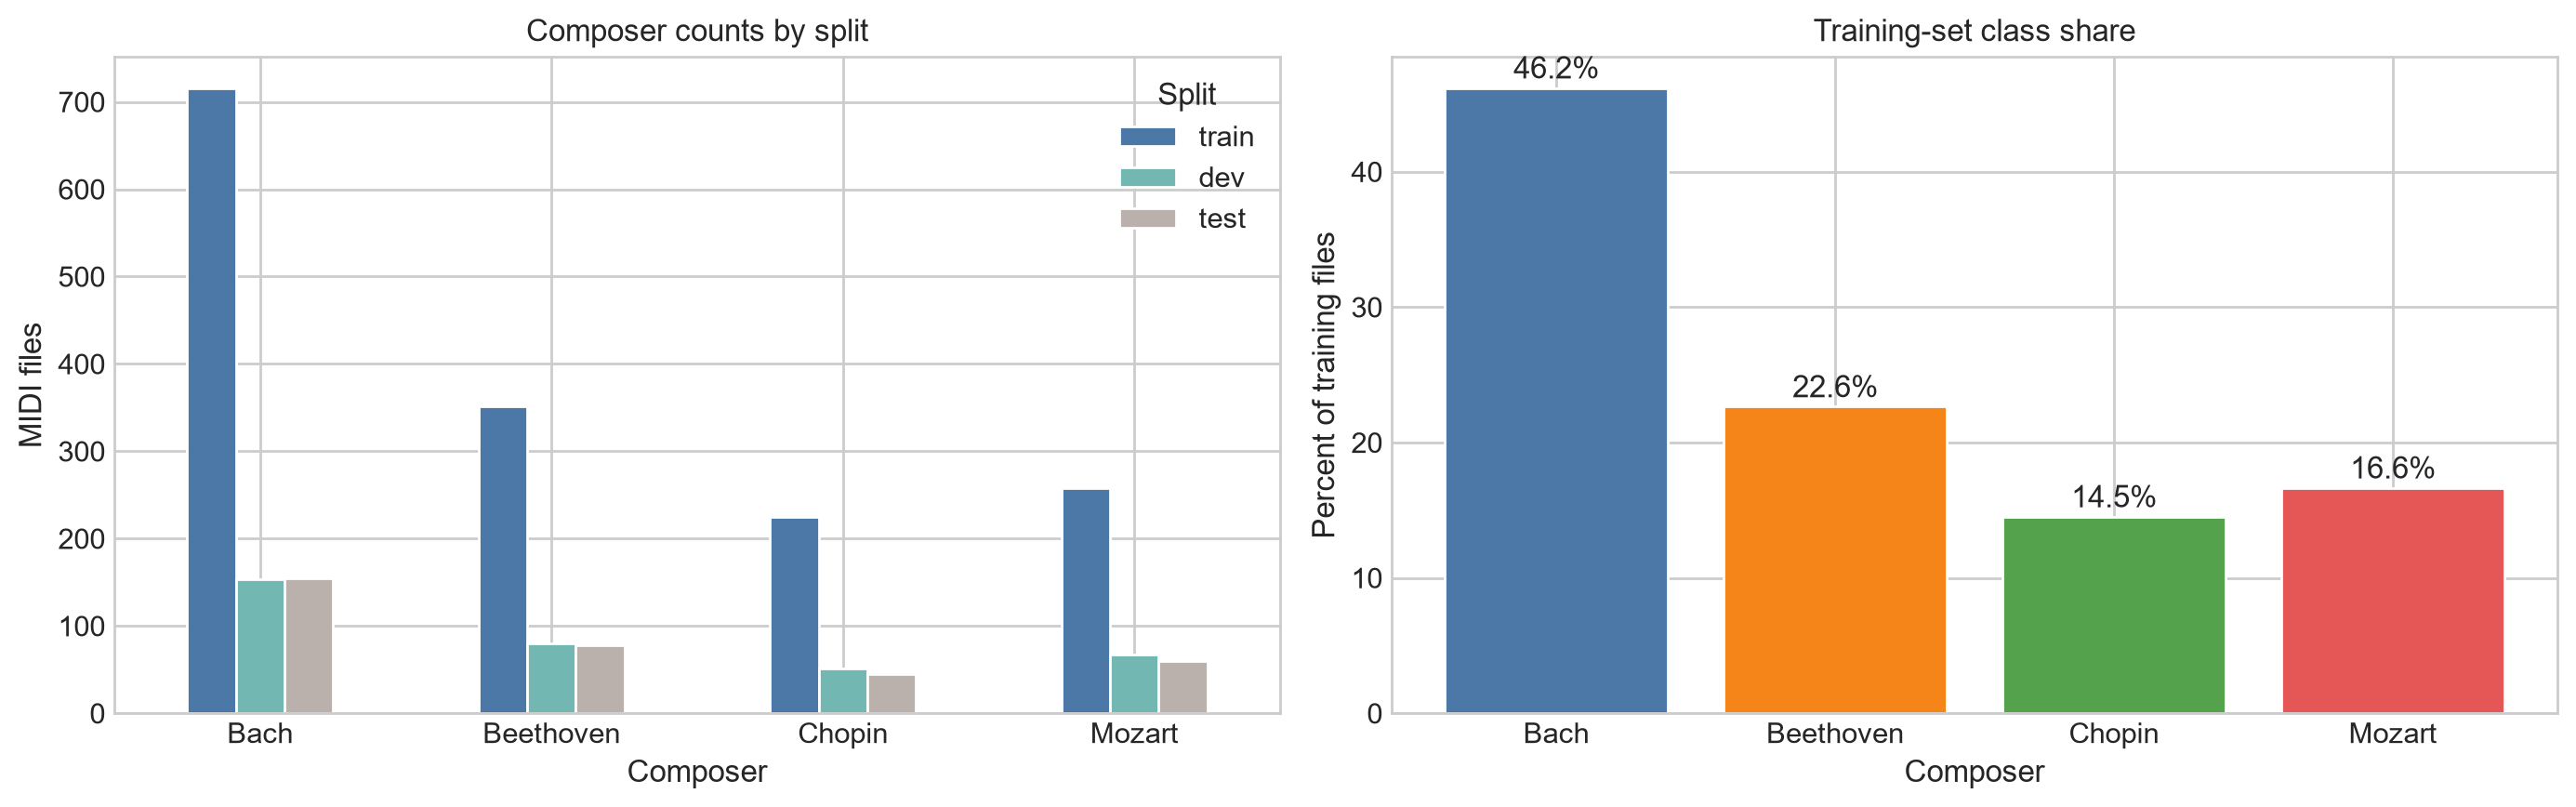

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

split_summary.T.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#72B7B2", "#BAB0AC"])
axes[0].set_title("Composer counts by split")
axes[0].set_xlabel("Composer")
axes[0].set_ylabel("MIDI files")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

train_share = train_df["composer"].value_counts(normalize=True).reindex(COMPOSER_ORDER) * 100
axes[1].bar(train_share.index, train_share.values, color=[COLORS[composer] for composer in train_share.index])
axes[1].set_title("Training-set class share")
axes[1].set_xlabel("Composer")
axes[1].set_ylabel("Percent of training files")
axes[1].tick_params(axis="x", rotation=0)
for index, value in enumerate(train_share.values):
    axes[1].text(index, value + 0.7, f"{value:.1f}%", ha="center")

fig.tight_layout()
plt.show()

### 7.4 Global timing and note-content distributions

These charts use the training split to show the distributions that the model will learn from.

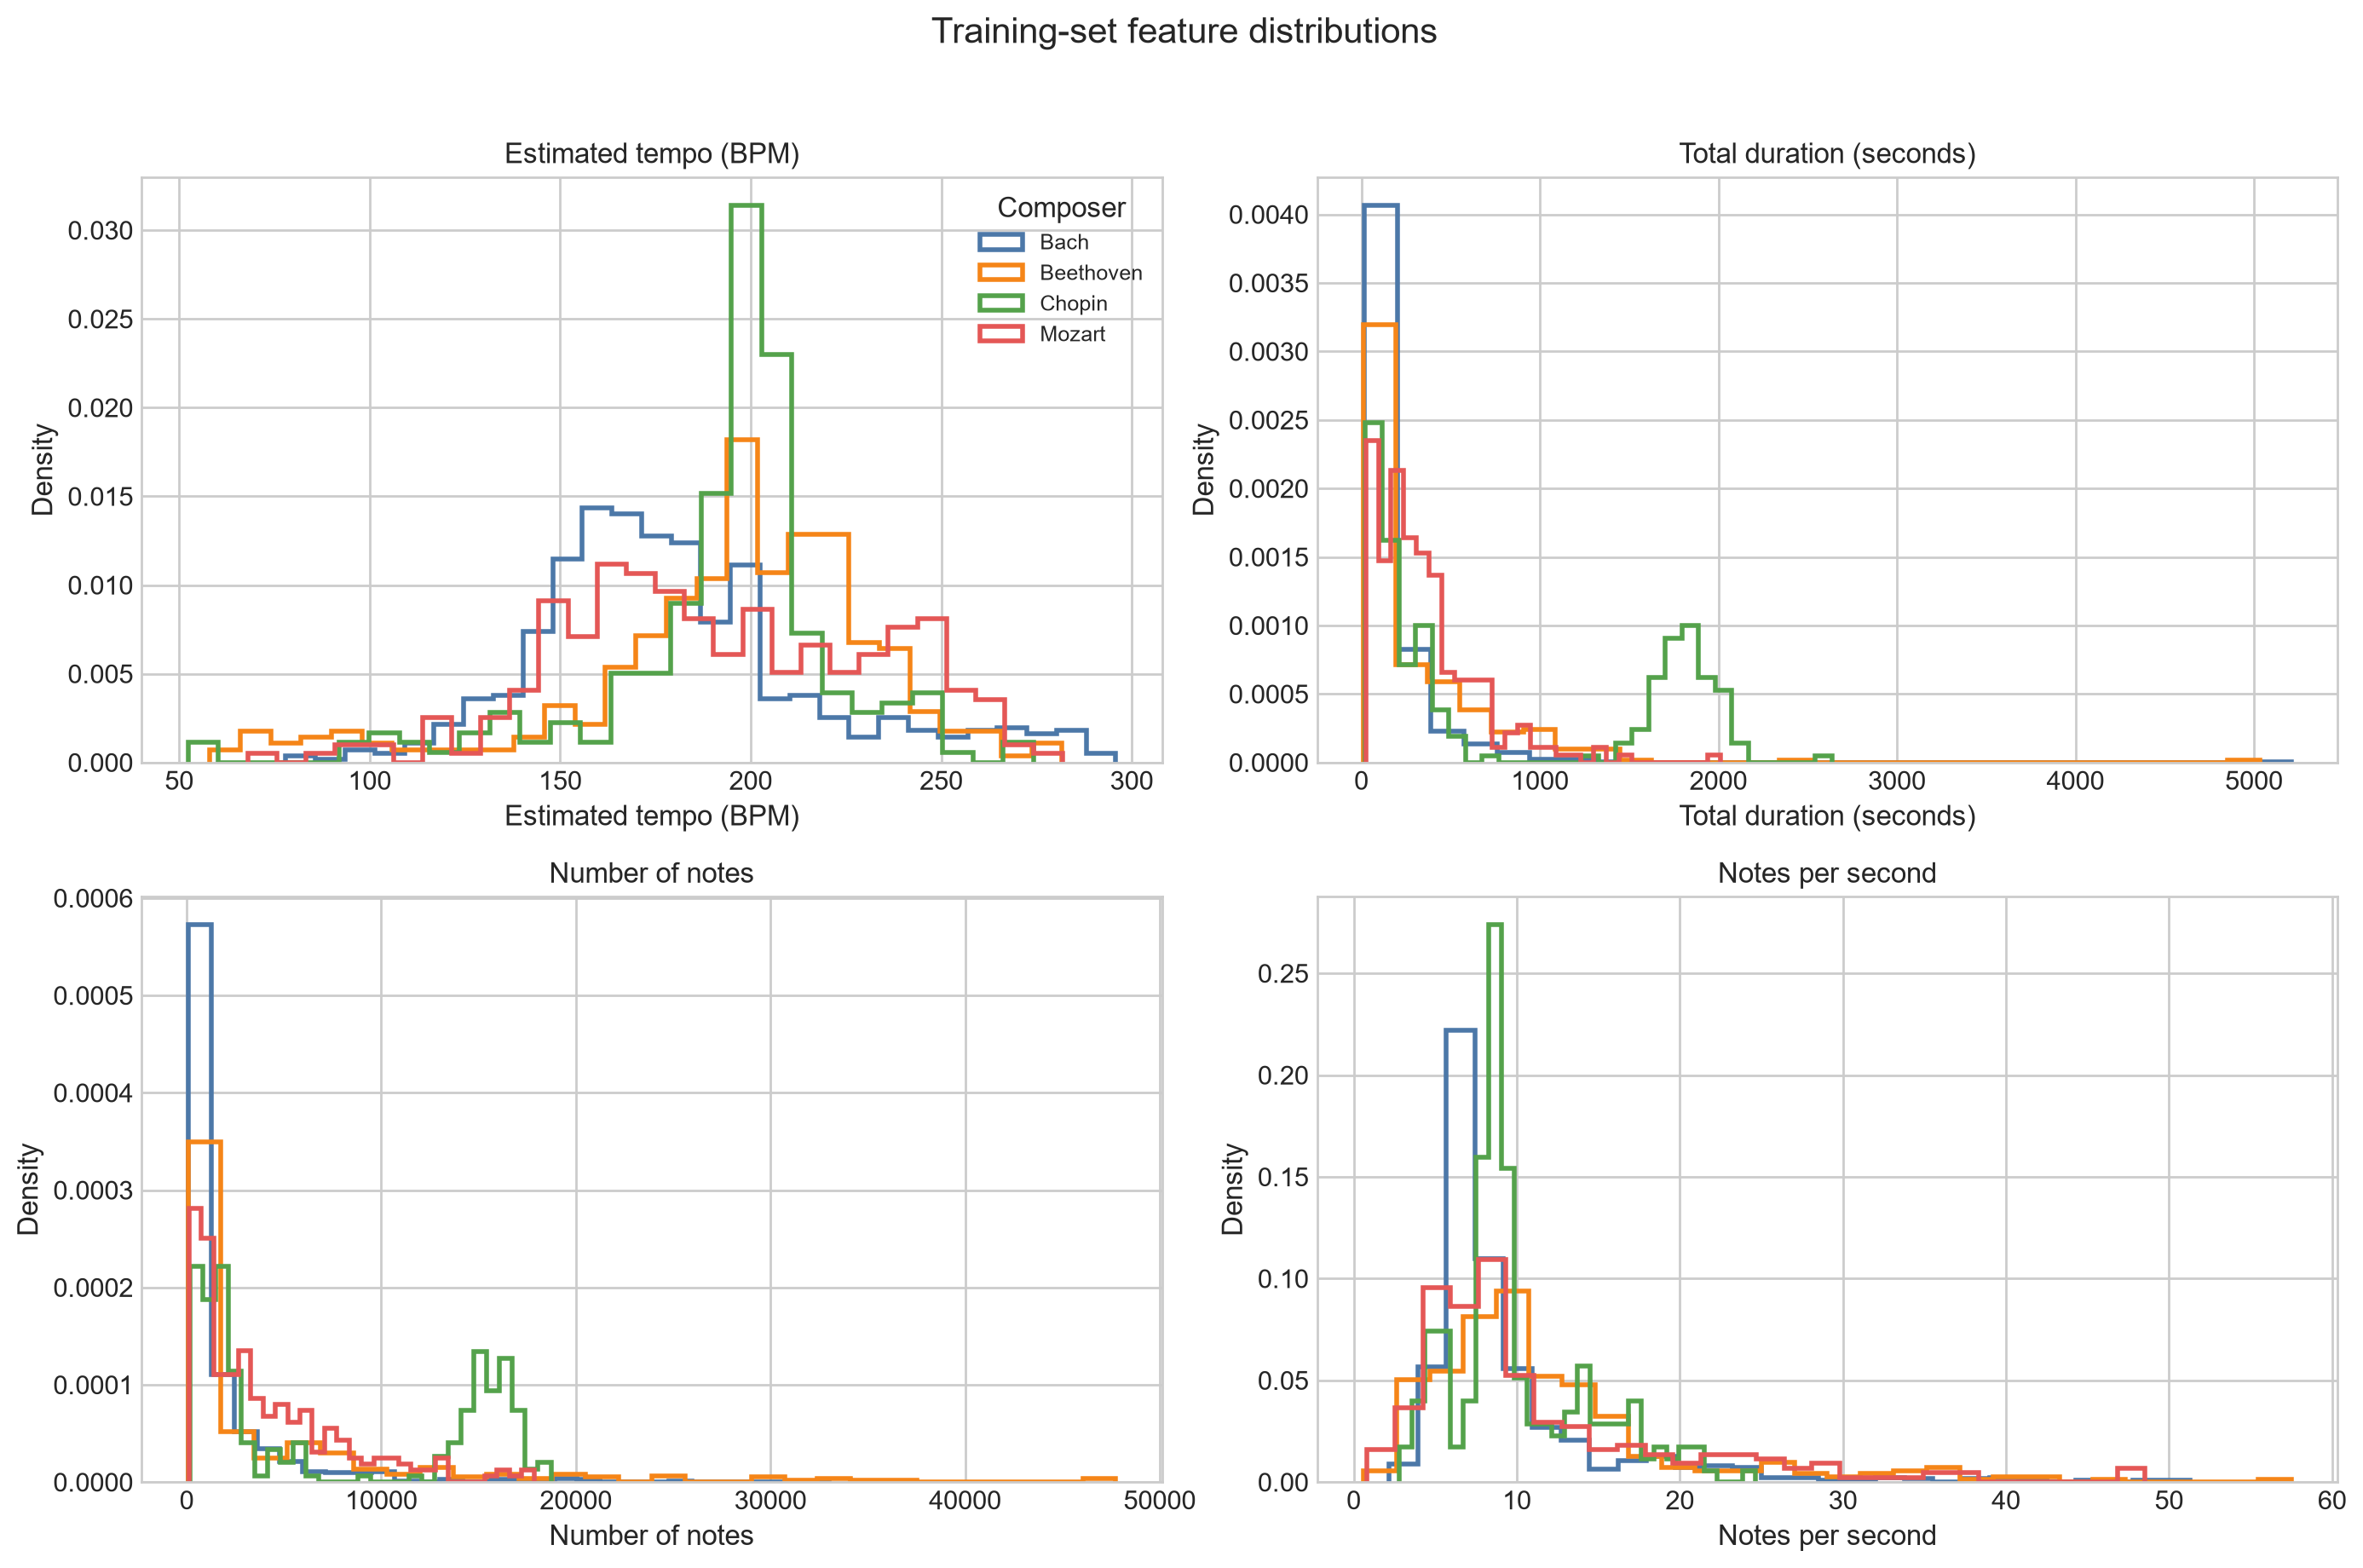

In [26]:
plot_features = [
    ("tempo", "Estimated tempo (BPM)"),
    ("total_duration", "Total duration (seconds)"),
    ("num_notes", "Number of notes"),
    ("note_density", "Notes per second"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, (feature, label) in zip(axes.flat, plot_features):
    for composer in COMPOSER_ORDER:
        values = train_df.loc[train_df["composer"] == composer, feature].dropna()
        axis.hist(values, bins=28, density=True, histtype="step", linewidth=2, label=composer, color=COLORS[composer])
    axis.set_title(label)
    axis.set_xlabel(label)
    axis.set_ylabel("Density")

axes[0, 0].legend(title="Composer", fontsize=9)
fig.suptitle("Training-set feature distributions", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 7.5 Composer comparison: pitch, rhythm, and texture

Each boxplot compares complete MIDI files in the training split. The center line is the median; the box contains the middle 50% of files; whiskers show the typical spread. Outliers are hidden to keep the central distributions readable.

**How to read the scales**: average pitch is the MIDI note number (middle C = 60); pitch standard deviation is in semitones; median note duration and mean onset interval are in seconds; polyphony is the number of simultaneously sounding notes.

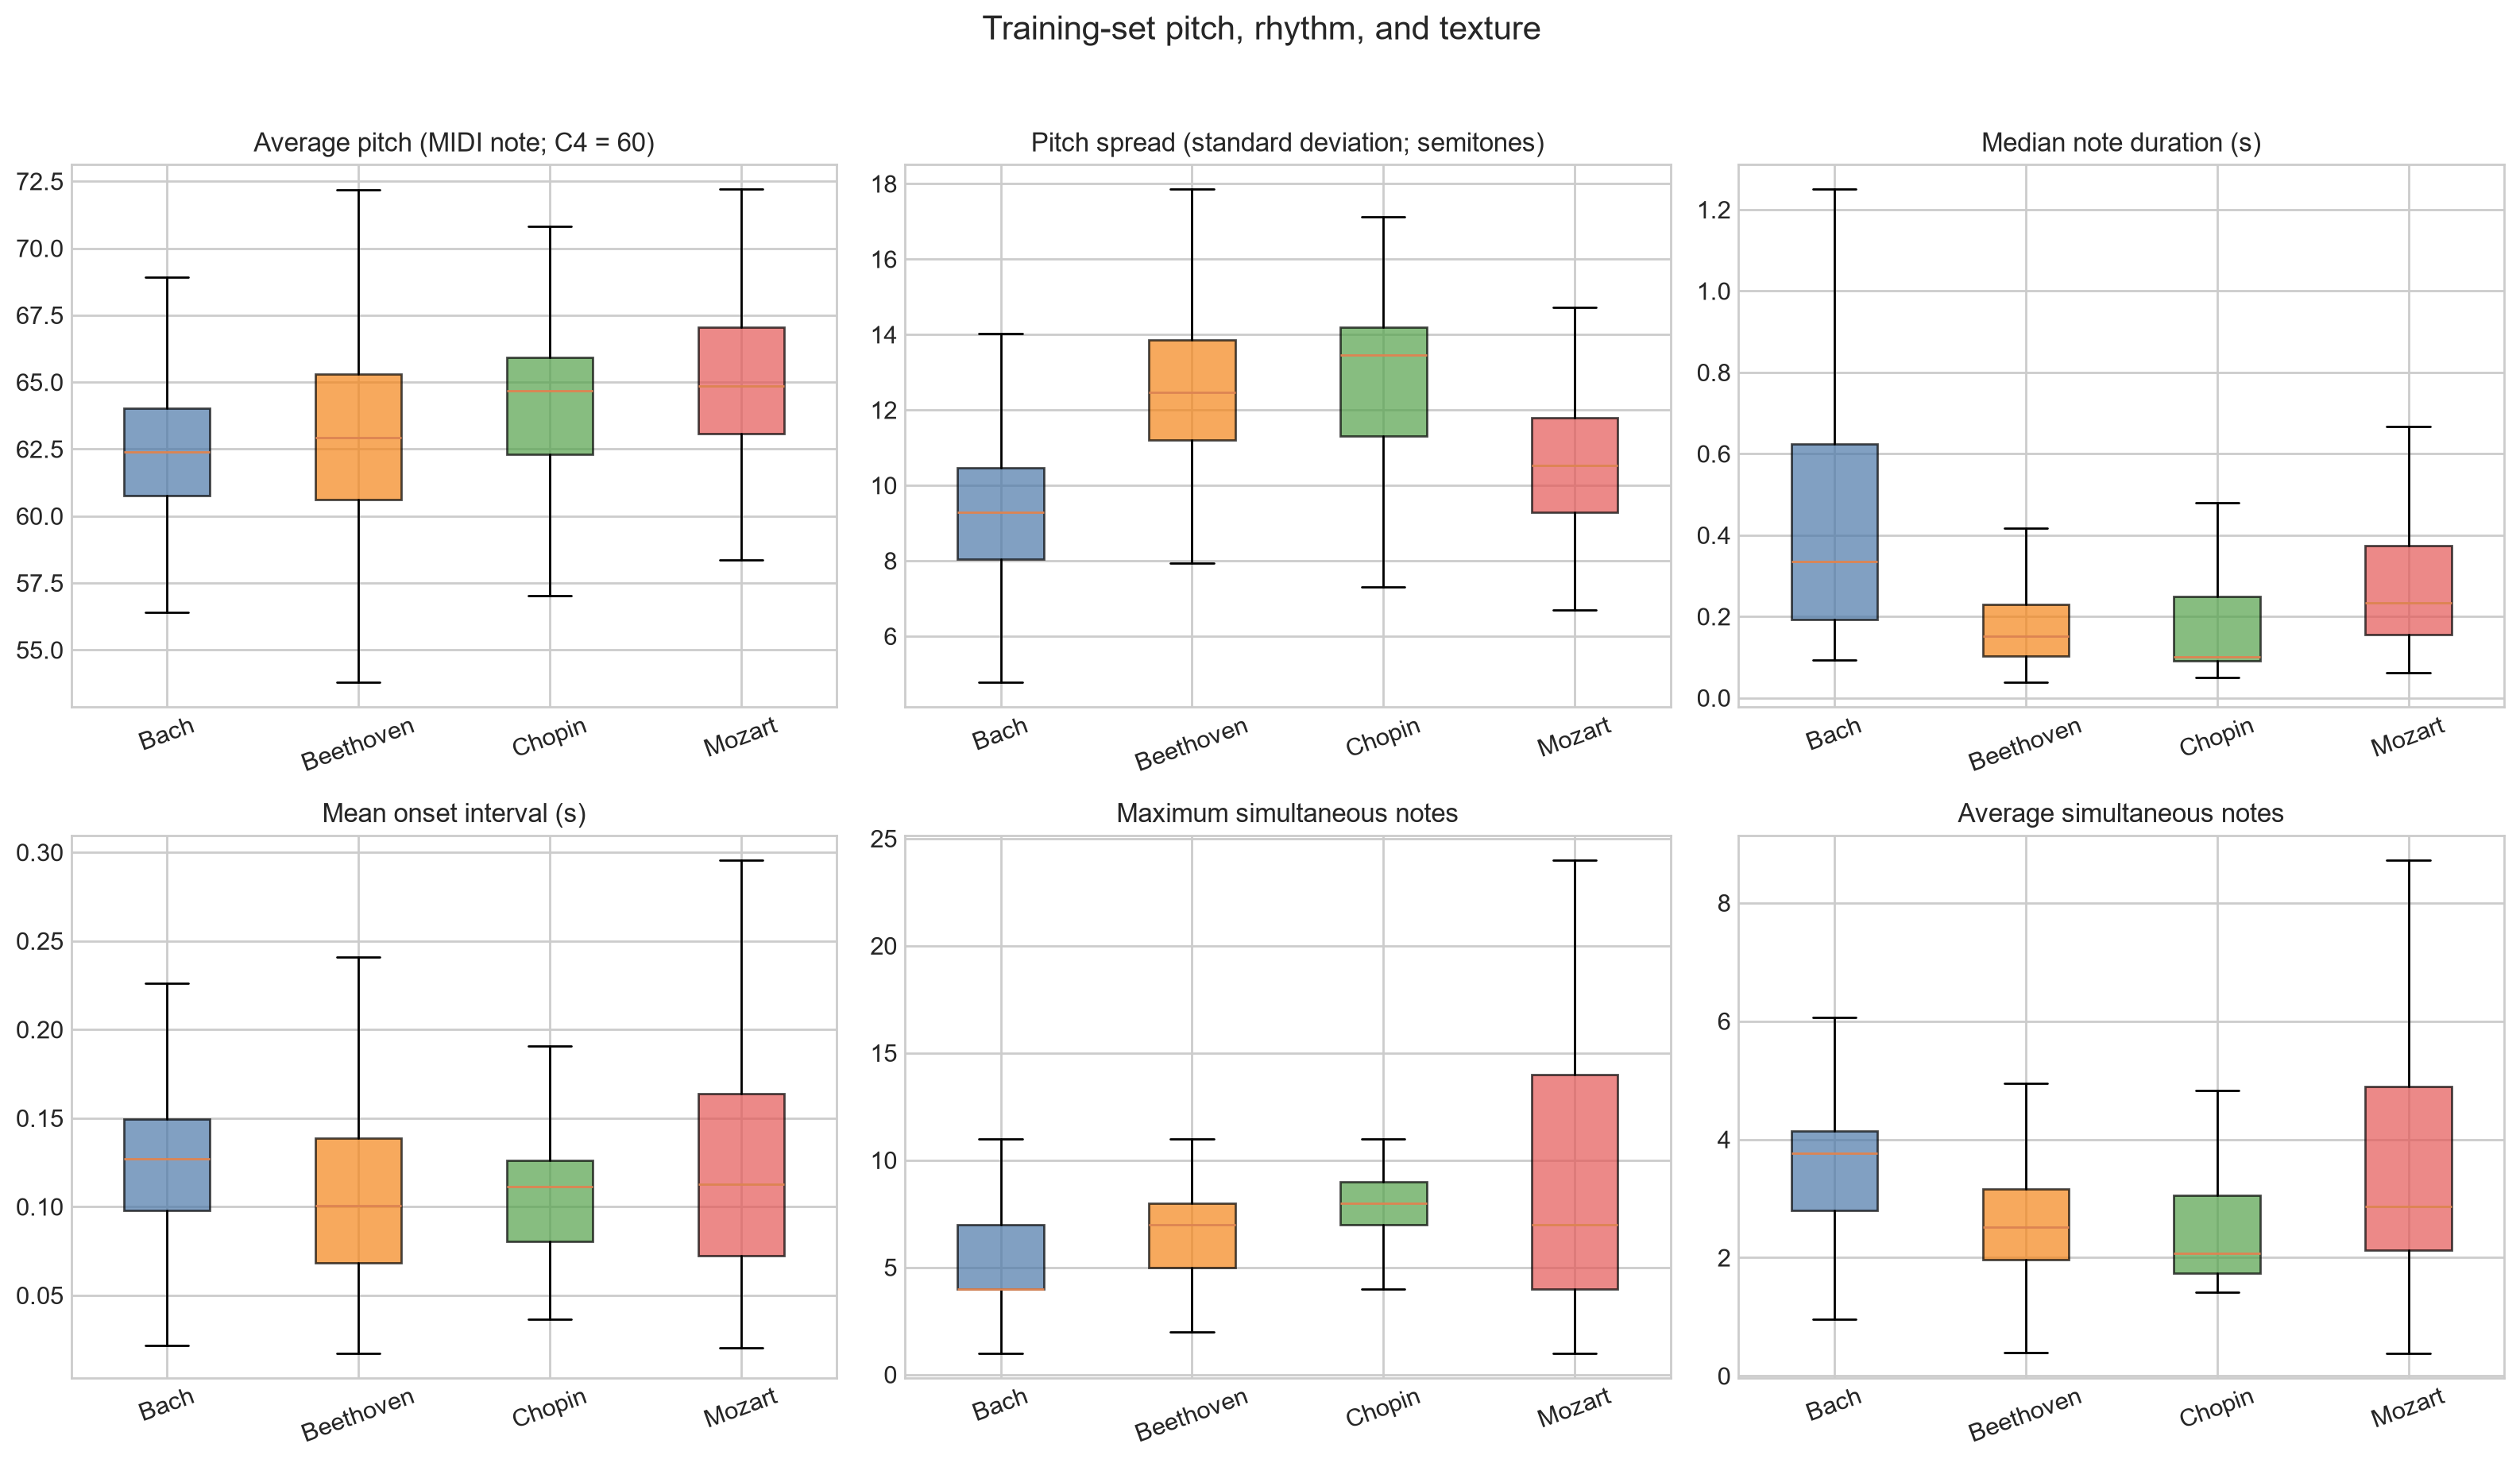

In [27]:
comparison_features = [
    ("avg_pitch", "Average pitch (MIDI note; C4 = 60)"),
    ("pitch_std", "Pitch spread (standard deviation; semitones)"),
    ("duration_median", "Median note duration (s)"),
    ("onset_interval_mean", "Mean onset interval (s)"),
    ("max_polyphony", "Maximum simultaneous notes"),
    ("avg_polyphony", "Average simultaneous notes"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, (feature, label) in zip(axes.flat, comparison_features):
    values = [train_df.loc[train_df["composer"] == composer, feature].dropna() for composer in COMPOSER_ORDER]
    boxplot = axis.boxplot(values, tick_labels=COMPOSER_ORDER, patch_artist=True, showfliers=False)
    for patch, composer in zip(boxplot["boxes"], COMPOSER_ORDER):
        patch.set_facecolor(COLORS[composer])
        patch.set_alpha(0.7)
    axis.set_title(label)
    axis.tick_params(axis="x", rotation=20)

fig.suptitle("Training-set pitch, rhythm, and texture", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 7.6 Instrumentation and track structure

General MIDI program assignments are imperfect metadata, but they can describe the arrangement choices represented in the source files.

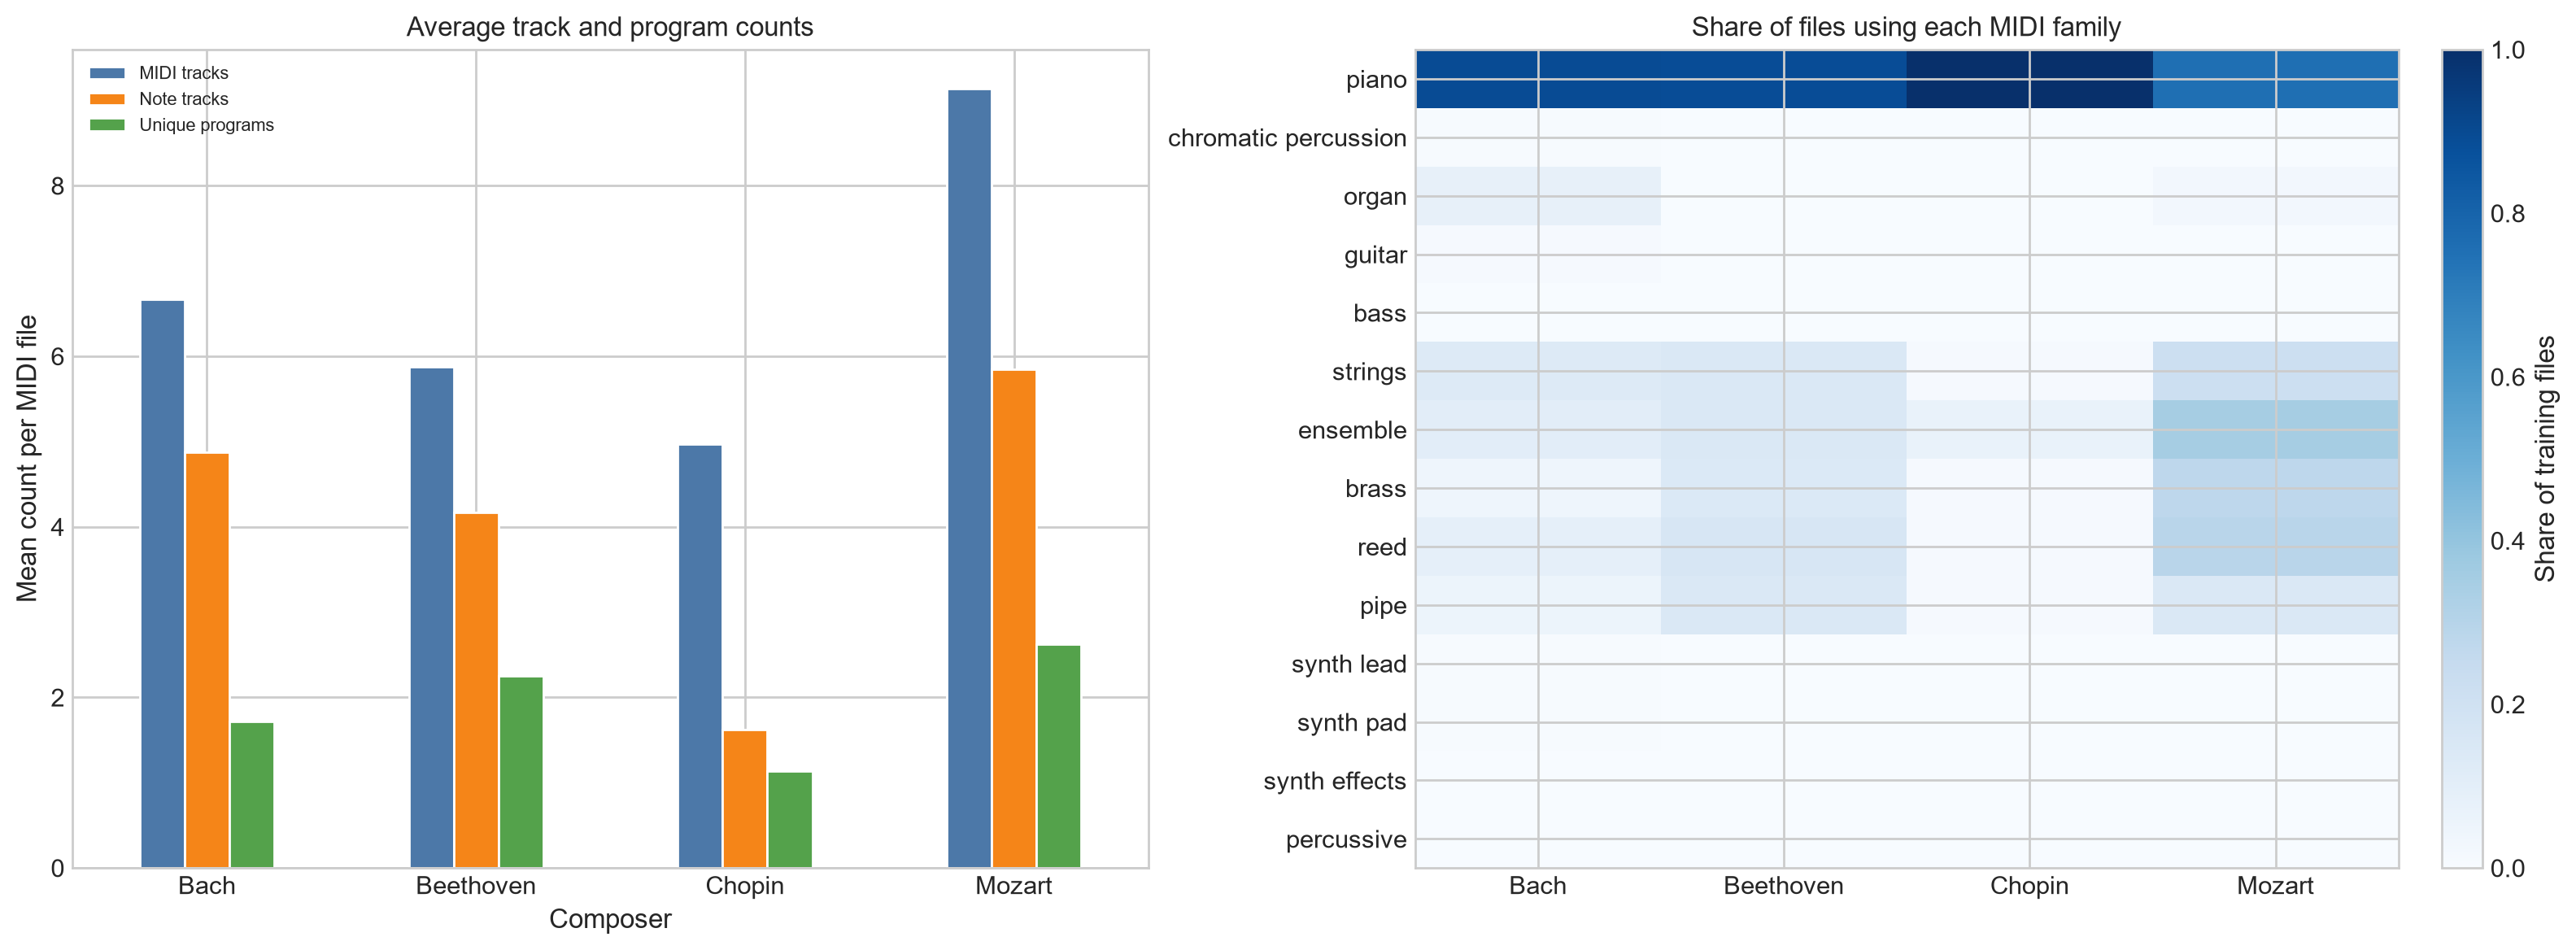

In [28]:
instrument_presence = (
    train_df.groupby("composer", observed=True)[INSTRUMENT_COLUMNS]
            .apply(lambda group: (group > 0).mean())
            .reindex(COMPOSER_ORDER)
)
active_instrument_columns = instrument_presence.columns[instrument_presence.sum() > 0]
instrument_presence = instrument_presence[active_instrument_columns]

short_labels = [column.removeprefix("gm_").removesuffix("_track_count").replace("_", " ") for column in active_instrument_columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

track_summary = train_df.groupby("composer", observed=True)[["num_midi_tracks", "num_note_tracks", "num_unique_programs"]].mean().reindex(COMPOSER_ORDER)
track_summary.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Average track and program counts")
axes[0].set_xlabel("Composer")
axes[0].set_ylabel("Mean count per MIDI file")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["MIDI tracks", "Note tracks", "Unique programs"], fontsize=8)

image = axes[1].imshow(instrument_presence.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Share of files using each MIDI family")
axes[1].set_xticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axes[1].set_yticks(range(len(short_labels)), short_labels)
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("Share of training files")

fig.tight_layout()
plt.show()

### 7.7 Composer feature profile

This heatmap standardizes selected training-set means across composers. It emphasizes relative stylistic differences rather than differences in feature units.

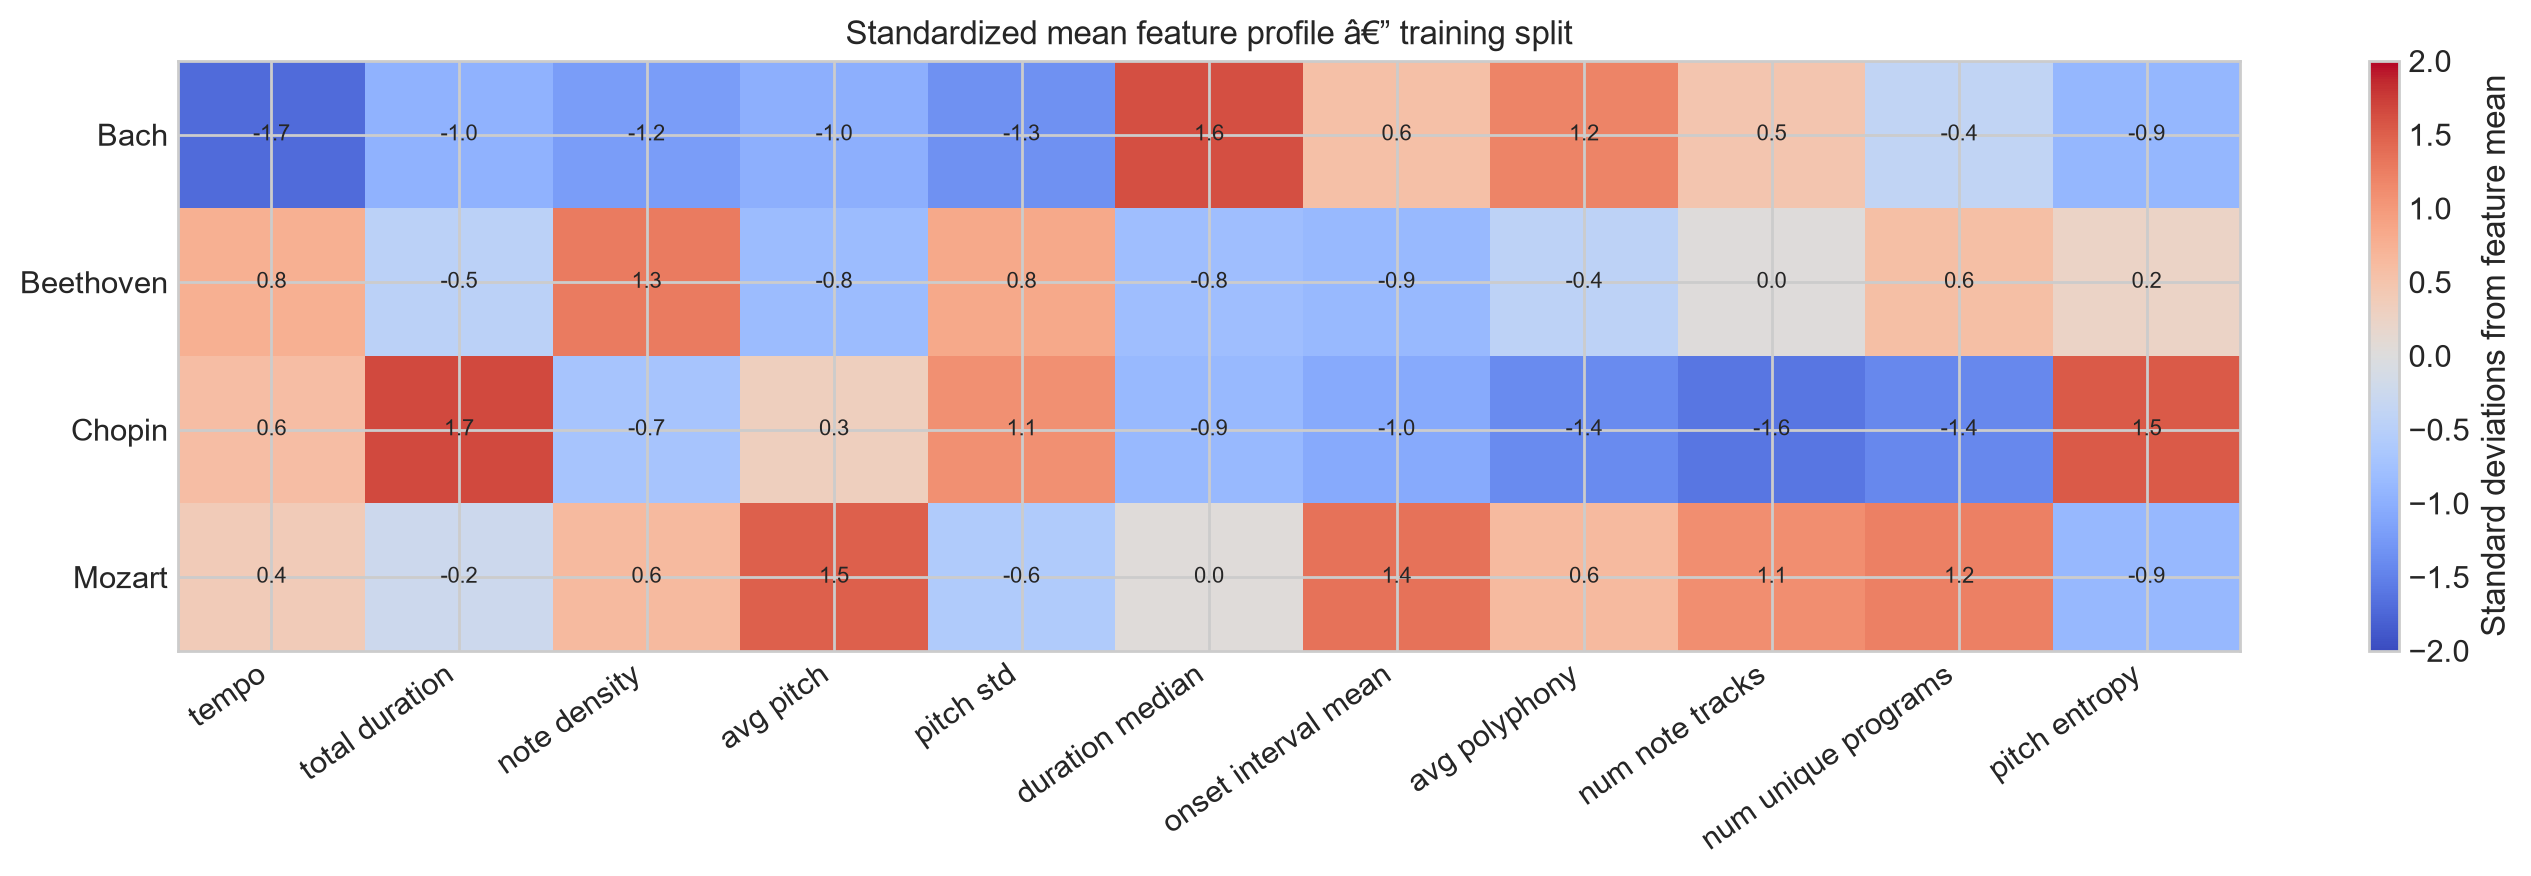

In [29]:
profile_features = [
    "tempo", "total_duration", "note_density", "avg_pitch", "pitch_std",
    "duration_median", "onset_interval_mean", "avg_polyphony",
    "num_note_tracks", "num_unique_programs", "pitch_entropy",
]
composer_profile = train_df.groupby("composer", observed=True)[profile_features].mean().reindex(COMPOSER_ORDER)
profile_zscores = (composer_profile - composer_profile.mean()) / composer_profile.std(ddof=0).replace(0, 1)

fig, axis = plt.subplots(figsize=(14, 4.5))
image = axis.imshow(profile_zscores, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
axis.set_xticks(range(len(profile_features)), [feature.replace("_", " ") for feature in profile_features], rotation=35, ha="right")
axis.set_yticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axis.set_title("Standardized mean feature profile â€” training split")
for row_index in range(len(COMPOSER_ORDER)):
    for column_index in range(len(profile_features)):
        axis.text(column_index, row_index, f"{profile_zscores.iloc[row_index, column_index]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Standard deviations from feature mean")
fig.tight_layout()
plt.show()

### 7.8 Feature redundancy and train-only separation ranking

Highly correlated features may be redundant. The F statistic below is a univariate training-only screen: it identifies potentially useful features but does not replace cross-validated model evaluation.

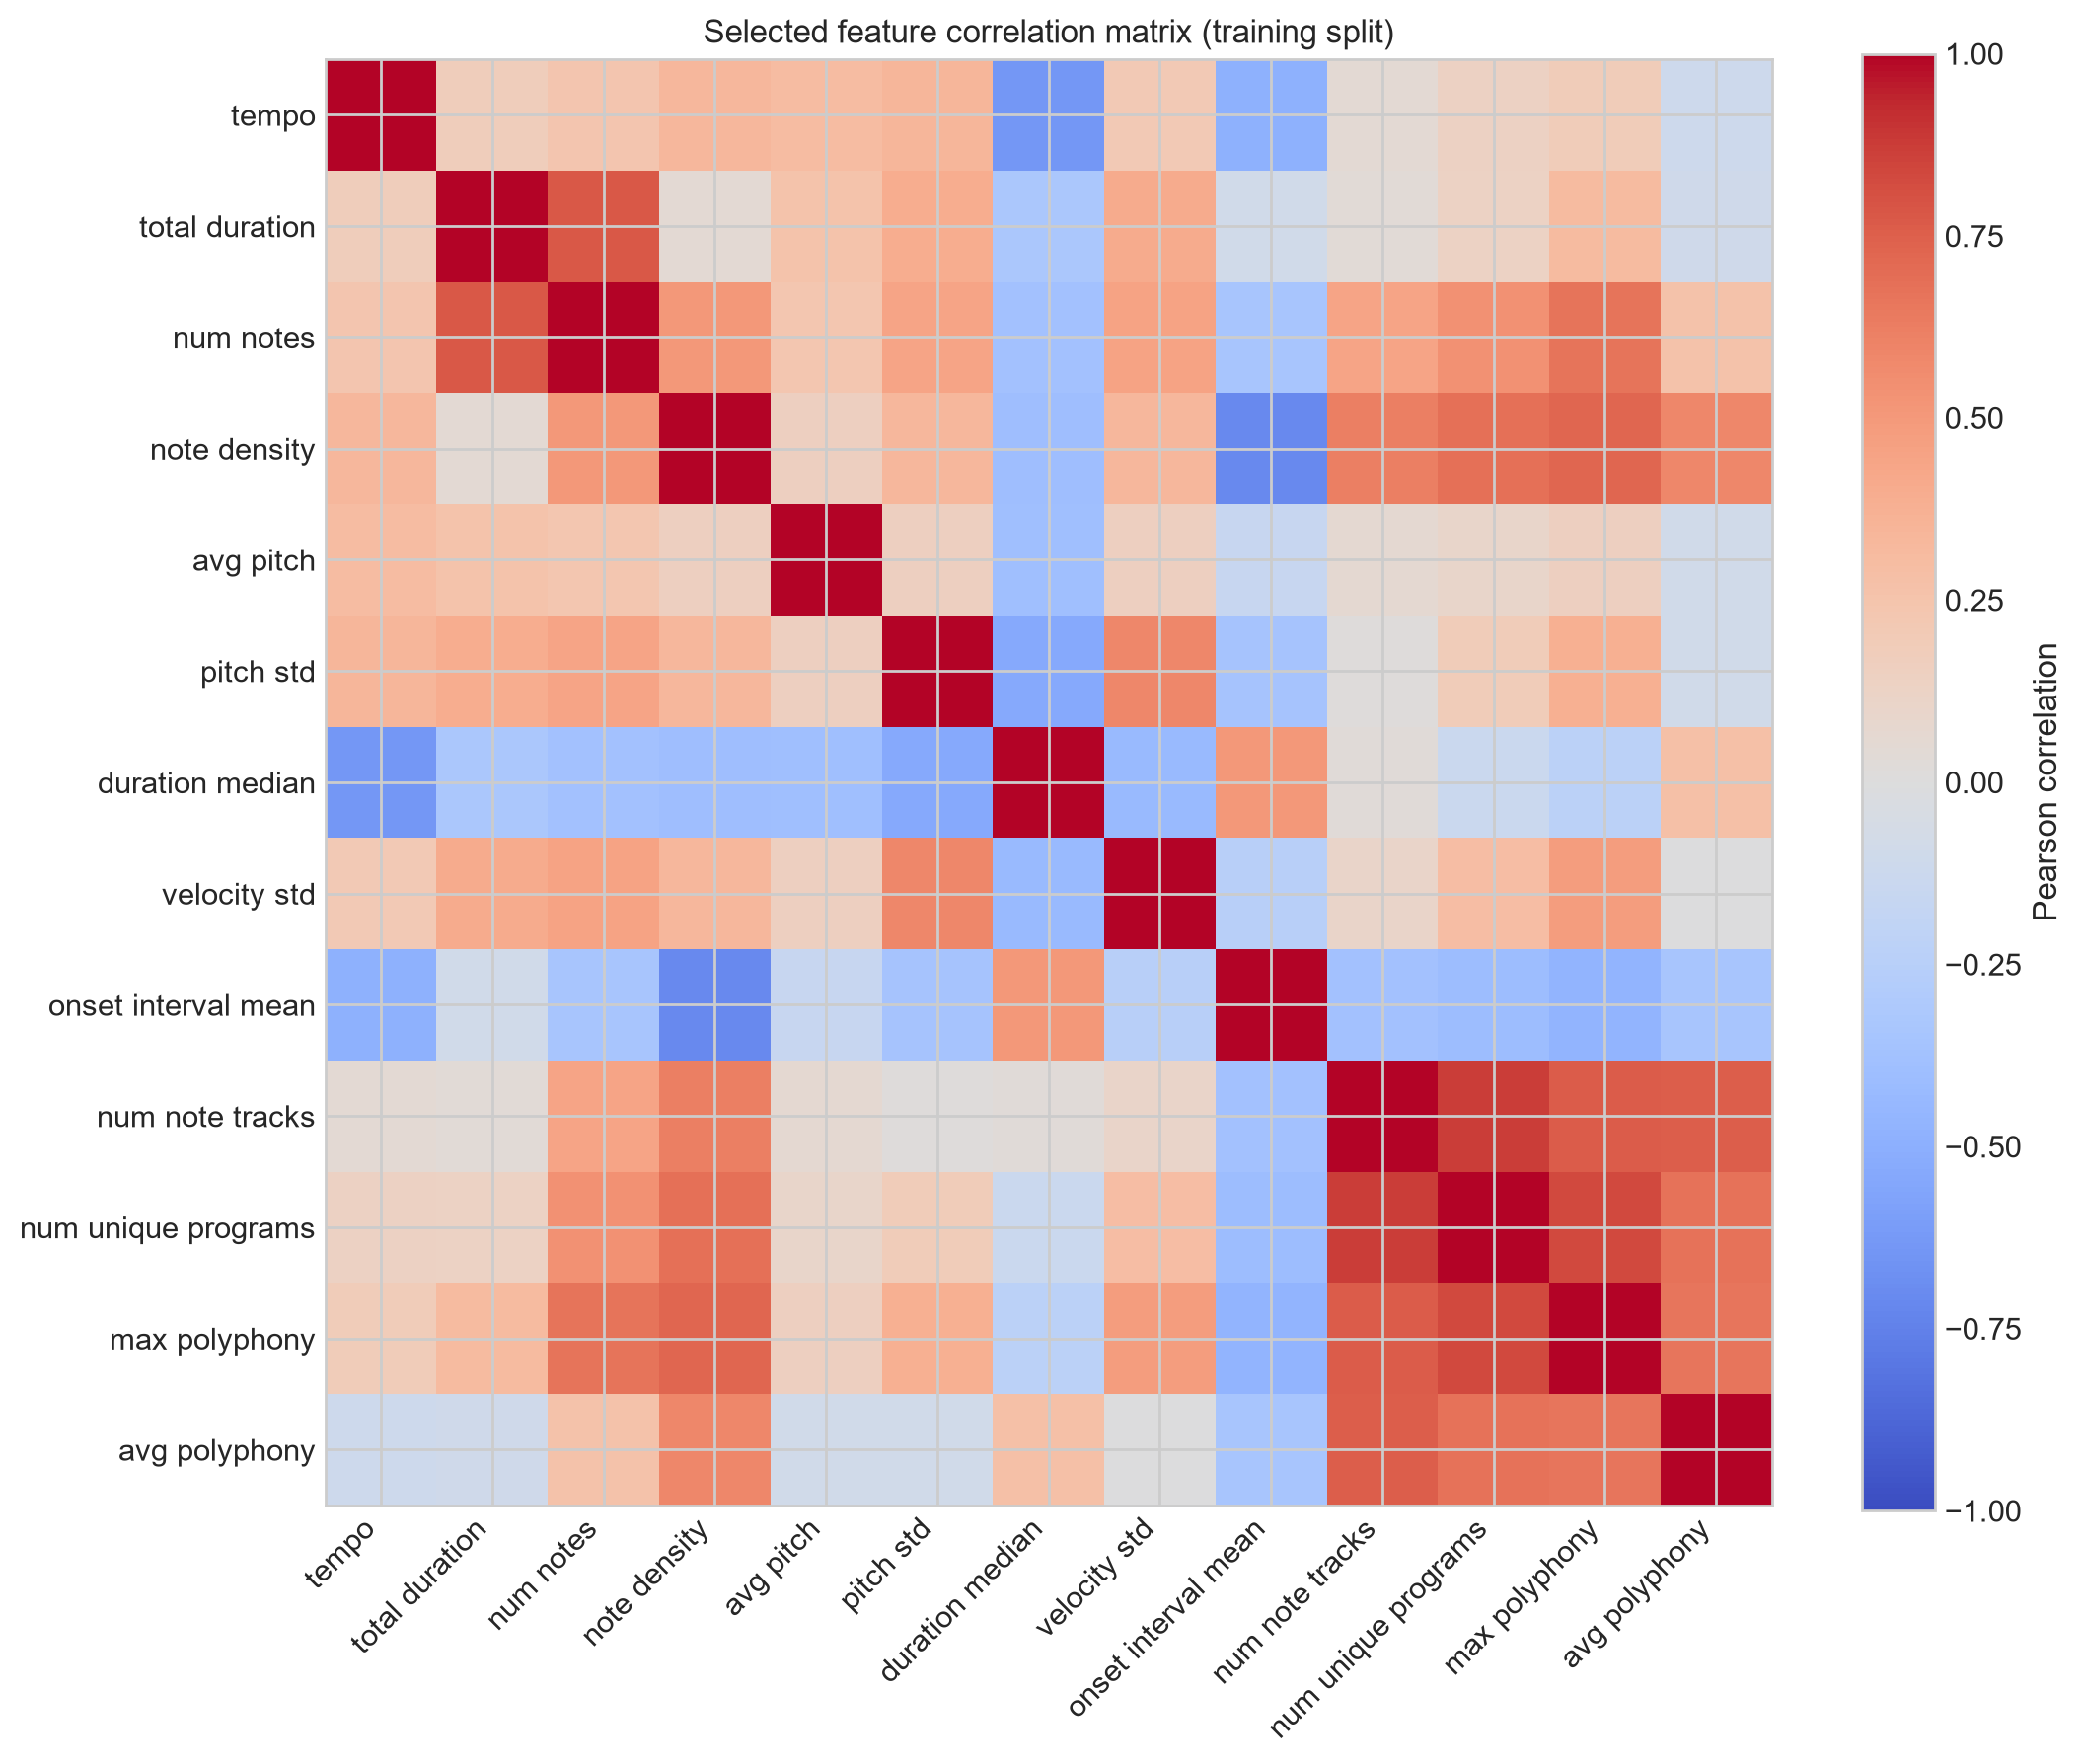

,feature,anova_f_score
0,velocity_range,604.919
1,velocity_std,510.069
2,range_normalized,433.414
3,pitch_range,423.055
4,pitch_std,270.229
5,avg_velocity,182.688
6,pitch_entropy,150.800
7,num_chords,147.822
8,total_duration,142.899
9,tempo_note_ratio,118.855


In [30]:
correlation_features = [
    "tempo", "total_duration", "num_notes", "note_density", "avg_pitch",
    "pitch_std", "duration_median", "velocity_std", "onset_interval_mean",
    "num_note_tracks", "num_unique_programs", "max_polyphony", "avg_polyphony",
]
correlation = train_df[correlation_features].corr()

fig, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation_features)), [feature.replace("_", " ") for feature in correlation_features], rotation=45, ha="right")
axis.set_yticks(range(len(correlation_features)), [feature.replace("_", " ") for feature in correlation_features])
axis.set_title("Selected feature correlation matrix (training split)")
fig.colorbar(image, ax=axis, label="Pearson correlation")
fig.tight_layout()
plt.show()

def anova_f_score(frame, feature, target="composer"):
    groups = [group[feature].dropna().to_numpy() for _, group in frame.groupby(target, observed=True)]
    groups = [group for group in groups if len(group) > 1]
    overall_mean = frame[feature].mean()
    between = sum(len(group) * (group.mean() - overall_mean) ** 2 for group in groups)
    within = sum(((group - group.mean()) ** 2).sum() for group in groups)
    degrees_between = len(groups) - 1
    degrees_within = sum(len(group) for group in groups) - len(groups)
    return (between / degrees_between) / (within / degrees_within) if within > 0 else np.nan

ranked_features = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "anova_f_score": [anova_f_score(train_df, feature) for feature in MODEL_FEATURES],
    }
).sort_values("anova_f_score", ascending=False)

display(ranked_features.head(15).reset_index(drop=True))

## 8. Preprocessing, Scaling & Split-Leakage Validation
**Original author: Beakal Zekaryas** &nbsp;|&nbsp; Source: `composer_model_project/MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb` &nbsp;|&nbsp; Treatment: **live**

Loads the pre-split, pre-assigned `combined_{train,dev,test}_features.csv` files as-is (no
re-splitting), validates schema/label consistency and confirms `relative_path` is disjoint
across splits (no leakage), drops constant training columns, and fits `StandardScaler`/
`LabelEncoder` on train only. The team's "dev" split is this notebook's validation split.

In [30]:
def find_csv(filename):
    """Locate a feature CSV by name, searching common candidate locations.

    Args:
        filename: CSV filename to find, e.g. "combined_train_features.csv".

    Returns:
        Resolved Path to the first matching file found.

    Raises:
        FileNotFoundError: If no candidate path or recursive search match exists.
    """
    direct_candidates = [
        PROJECT_ROOT / filename,
        PROJECT_ROOT / "data" / filename,
        PROJECT_ROOT / "data" / "features" / filename,
        FEATURE_DIR / filename,
    ]
    direct_candidates.extend(PROJECT_ROOT.rglob(filename))
    match = next((path for path in direct_candidates if path.exists()), None)
    if match is None:
        raise FileNotFoundError(f"{filename} was not found under {PROJECT_ROOT} or {FEATURE_DIR}")
    return match

TRAIN_PATH = find_csv("combined_train_features.csv")
DEV_PATH = find_csv("combined_dev_features.csv")
TEST_PATH = find_csv("combined_test_features.csv")

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)
test_df = pd.read_csv(TEST_PATH)

log("SECTION 8", f"Training: {train_df.shape} {TRAIN_PATH}")
log("SECTION 8", f"Development: {dev_df.shape} {DEV_PATH}")
log("SECTION 8", f"Held-out test: {test_df.shape} {TEST_PATH}")

[SECTION 8] Training: (1550, 63) C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\combined_train_features.csv
[SECTION 8] Development: (351, 63) C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\combined_dev_features.csv
[SECTION 8] Held-out test: (338, 63) C:\Users\Maxtw\OneDrive\Desktop\511 Project\data\features\combined_test_features.csv


In [31]:
"""Schema/label consistency and split-leakage validation (no NaNs, identical columns/labels
across splits, and no MIDI file appears in more than one split)."""
expected_shape_columns = list(train_df.columns)
assert expected_shape_columns == list(dev_df.columns) == list(test_df.columns)
assert not train_df.isna().any().any()
assert not dev_df.isna().any().any()
assert not test_df.isna().any().any()

expected_labels = set(train_df["composer"])
assert expected_labels == set(dev_df["composer"]) == set(test_df["composer"])

# Confirming the supplied splits do not contain the same MIDI paths (leakage check).
train_paths = set(train_df["relative_path"])
dev_paths = set(dev_df["relative_path"])
test_paths = set(test_df["relative_path"])
assert train_paths.isdisjoint(dev_paths)
assert train_paths.isdisjoint(test_paths)
assert dev_paths.isdisjoint(test_paths)
log("SECTION 8", "No cross-split leakage: relative_path sets are pairwise disjoint")

model_split_summary = pd.DataFrame({
    "Train": train_df["composer"].value_counts(),
    "Development": dev_df["composer"].value_counts(),
    "Held-out Test": test_df["composer"].value_counts(),
}).fillna(0).astype(int)
display(model_split_summary)

[SECTION 8] No cross-split leakage: relative_path sets are pairwise disjoint


,Train,Development,Held-out Test
composer,,,
Bach,716,153,155
Beethoven,351,80,78
Mozart,258,67,60
Chopin,225,51,45


In [32]:
TARGET = "composer"
IDENTIFIER_COLUMNS = ["filename", "relative_path"]
excluded_columns = [TARGET] + IDENTIFIER_COLUMNS

candidate_features = [c for c in train_df.columns if c not in excluded_columns]
non_numeric = [c for c in candidate_features if not pd.api.types.is_numeric_dtype(train_df[c])]
if non_numeric:
    raise TypeError(f"Unexpected nonnumeric predictors: {non_numeric}")

# Learn removal decisions from training only.
constant_features = [c for c in candidate_features if train_df[c].nunique(dropna=False) <= 1]
feature_names = [c for c in candidate_features if c not in constant_features]

log("SECTION 8", f"Numeric candidate features: {len(candidate_features)}")
log("SECTION 8", f"Constant training features removed: {constant_features}")
log("SECTION 8", f"Final model features: {len(feature_names)}")

[SECTION 8] Numeric candidate features: 60
[SECTION 8] Constant training features removed: ['gm_ethnic_track_count', 'gm_sound_effects_track_count']
[SECTION 8] Final model features: 58


In [33]:
"""Fit preprocessing objects on training data only; reshape for both architectures.

Note: every CSV row is one composition-level observation, not a temporal sequence - the LSTM
sees a single timestep containing the complete feature vector (this is a gated composition-level
classifier, not a model of note-to-note temporal structure)."""
scaler = StandardScaler()
X_train_2d = scaler.fit_transform(train_df[feature_names]).astype("float32")
X_dev_2d = scaler.transform(dev_df[feature_names]).astype("float32")
X_test_2d = scaler.transform(test_df[feature_names]).astype("float32")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[TARGET])
y_dev = label_encoder.transform(dev_df[TARGET])
y_test = label_encoder.transform(test_df[TARGET])

class_ids = np.arange(len(label_encoder.classes_))
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=y_train)
class_weights = dict(zip(class_ids, weights))

# CNN convolves across the ordered feature vector.
X_train_cnn = X_train_2d[..., np.newaxis]
X_dev_cnn = X_dev_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

# LSTM: single timestep containing the full feature vector.
X_train_lstm = X_train_2d[:, np.newaxis, :]
X_dev_lstm = X_dev_2d[:, np.newaxis, :]
X_test_lstm = X_test_2d[:, np.newaxis, :]

log("SECTION 8", f"Classes: {list(label_encoder.classes_)}")
log("SECTION 8", f"CNN input: {X_train_cnn.shape} | LSTM input: {X_train_lstm.shape}")

[SECTION 8] Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']
[SECTION 8] CNN input: (1550, 58, 1) | LSTM input: (1550, 1, 58)


## 9. Model Building
**Original author: Beakal Zekaryas** &nbsp;|&nbsp; Treatment: **live**

The CNN learns local interactions among adjacent, logically ordered MIDI descriptors. The LSTM
is a gated composition-level classifier — a true temporal LSTM over individual notes would
require event-sequence files rather than one aggregate row per composition (see Section 17).

*(Renamed `build_cnn`/`build_lstm` &rarr; `build_baseline_cnn`/`build_baseline_lstm` to avoid a
naming collision with Section 13's tunable `build_tuned_cnn(hp)`/`build_tuned_lstm(hp)`, which
share the same architecture family but a different function signature.)*

In [34]:
NUM_CLASSES = len(label_encoder.classes_)

def build_baseline_cnn():
    """Build and compile the baseline 1D CNN classifier.

    Architecture: Conv1D(16, k=5, L2=1e-4) -> MaxPool -> Conv1D(32, k=3) -> Flatten ->
    Dense(32) -> Dropout(0.3) -> Dense(4, softmax).

    Returns:
        A compiled tf.keras.Sequential model.
    """
    model = Sequential([
        Input(shape=X_train_cnn.shape[1:]),
        Conv1D(16, kernel_size=5, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.30),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name="composer_cnn")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def build_baseline_lstm():
    """Build and compile the baseline LSTM classifier.

    Architecture: LSTM(32) -> Dropout(0.3) -> Dense(32) -> Dropout(0.2) -> Dense(4, softmax),
    over a single timestep containing the full feature vector.

    Returns:
        A compiled tf.keras.Model.
    """
    inputs = Input(shape=X_train_lstm.shape[1:])
    x = LSTM(32)(inputs)
    x = Dropout(0.30)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs, name="composer_lstm")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_model = build_baseline_cnn()
lstm_model = build_baseline_lstm()

cnn_model.summary()
lstm_model.summary()

Model: "composer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 29, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 928)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        29,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,524 (123.14 KB)

 Trainable params: 31,524 (123.14 KB)

 Non-trainable params: 0 (0.00 B)

Model: "composer_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 58)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,836 (50.14 KB)

 Trainable params: 12,836 (50.14 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Model Training
**Original author: Beakal Zekaryas** &nbsp;|&nbsp; Treatment: **live**

Full-batch training (one gradient step per epoch) for 60 epochs, with `EarlyStopping`,
`ReduceLROnPlateau`, and `ModelCheckpoint`, using `class_weight='balanced'` identically for both
models. `ARTIFACT_DIR` is repointed under this notebook's own output folder so it never collides
with the standalone evaluation notebooks' saved artifacts.

In [35]:
EPOCHS = 60
BATCH_SIZE = len(X_train_2d)  # Full-batch training matches the verified reference run.

def callbacks_for(model_name):
    """Build the standard callback set (early stopping, LR reduction, checkpointing) for a model.

    Args:
        model_name: Short name used for the checkpoint filename, e.g. "cnn" or "lstm".

    Returns:
        List of Keras callbacks.
    """
    return [
        EarlyStopping(monitor="val_loss", patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ARTIFACT_DIR / f"{model_name}_best.keras", monitor="val_loss", save_best_only=True),
    ]

joblib.dump(scaler, ARTIFACT_DIR / "standard_scaler.joblib")
joblib.dump(label_encoder, ARTIFACT_DIR / "label_encoder.joblib")
pd.Series(feature_names, name="feature").to_csv(ARTIFACT_DIR / "model_features.csv", index=False)

In [36]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks_for("cnn"), verbose=1,
)

Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step - accuracy: 0.3877 - loss: 1.4147 - val_accuracy: 0.2621 - val_loss: 1.3079 - learning_rate: 0.0050
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2697 - loss: 1.3060 - val_accuracy: 0.6011 - val_loss: 1.2229 - learning_rate: 0.0050
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4935 - loss: 1.2242 - val_accuracy: 0.7094 - val_loss: 1.0876 - learning_rate: 0.0050
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6194 - loss: 1.1227 - val_accuracy: 0.7066 - val_loss: 0.9377 - learning_rate: 0.0050
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6535 - loss: 1.0309 - val_accuracy: 0.7123 - val_loss: 0.8219 - learning_rate: 0.0050
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6755 - loss: 0.9430 - val_accuracy: 0.7179 - val_loss: 0.7409 - learning_rate: 0.0050
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6748 - loss: 0.8556 - val_accuracy: 0.7293

In [37]:
lstm_history = lstm_model.fit(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks_for("lstm"), verbose=1,
)

Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1761 - loss: 1.4025 - val_accuracy: 0.2536 - val_loss: 1.3984 - learning_rate: 0.0030
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.2013 - loss: 1.3771 - val_accuracy: 0.2934 - val_loss: 1.3704 - learning_rate: 0.0030
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2490 - loss: 1.3453 - val_accuracy: 0.3333 - val_loss: 1.3447 - learning_rate: 0.0030
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.2697 - loss: 1.3262 - val_accuracy: 0.4103 - val_loss: 1.3219 - learning_rate: 0.0030
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.3297 - loss: 1.2933 - val_accuracy: 0.4758 - val_loss: 1.3007 - learning_rate: 0.0030
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3426 - loss: 1.2715 - val_accuracy: 0.5185 - val_loss: 1.2804 - learning_rate: 0.0030
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3884 - loss: 1.2429 - val_accuracy: 0.5527 - 

## 11. Held-Out Test Evaluation
**Original author: Beakal Zekaryas** &nbsp;|&nbsp; Treatment: **live**

The test set is used only here, after preprocessing and model selection are complete. Macro
metrics give all four composers equal importance, correcting for class imbalance in the report
(unlike raw accuracy).

In [38]:
def evaluate_model(model, X_test, model_name):
    """Score a trained model on the held-out test set.

    Args:
        model: A trained, compiled Keras model.
        X_test: Test features, already reshaped for this model\'s input.
        model_name: Label used in the returned metrics dict.

    Returns:
        Tuple of (metrics dict, per-class classification_report DataFrame, predicted class
        indices, predicted class probabilities).
    """
    probabilities = model.predict(X_test, verbose=0)
    predictions = probabilities.argmax(axis=1)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="macro", zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="weighted", zero_division=0)
    metrics = {"Model": model_name, "Accuracy": accuracy_score(y_test, predictions),
               "Macro Precision": macro_precision, "Macro Recall": macro_recall,
               "Macro F1": macro_f1, "Weighted F1": weighted_f1}
    report = pd.DataFrame(classification_report(
        y_test, predictions, labels=class_ids, target_names=label_encoder.classes_,
        output_dict=True, zero_division=0)).T
    return metrics, report, predictions, probabilities

cnn_metrics, cnn_report, cnn_predictions, cnn_probabilities = evaluate_model(cnn_model, X_test_cnn, "CNN")
lstm_metrics, lstm_report, lstm_predictions, lstm_probabilities = evaluate_model(lstm_model, X_test_lstm, "LSTM")

metrics_df = pd.DataFrame([cnn_metrics, lstm_metrics]).sort_values("Macro F1", ascending=False)
display(metrics_df.style.format({"Accuracy": "{:.3f}", "Macro Precision": "{:.3f}",
    "Macro Recall": "{:.3f}", "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"}))
print("CNN per-composer report")
display(cnn_report.round(3))
print("LSTM per-composer report")
display(lstm_report.round(3))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,CNN,0.896,0.871,0.880,0.875,0.897
1,LSTM,0.834,0.806,0.802,0.802,0.834


CNN per-composer report


,precision,recall,f1-score,support
Bach,0.967,0.935,0.951,155.000
Beethoven,0.883,0.872,0.877,78.000
Chopin,0.844,0.844,0.844,45.000
Mozart,0.788,0.867,0.825,60.000
accuracy,0.896,0.896,0.896,0.896
macro avg,0.871,0.880,0.875,338.000
weighted avg,0.899,0.896,0.897,338.000


LSTM per-composer report


,precision,recall,f1-score,support
Bach,0.905,0.923,0.914,155.000
Beethoven,0.851,0.731,0.786,78.000
Chopin,0.773,0.756,0.764,45.000
Mozart,0.696,0.800,0.744,60.000
accuracy,0.834,0.834,0.834,0.834
macro avg,0.806,0.802,0.802,338.000
weighted avg,0.838,0.834,0.834,338.000


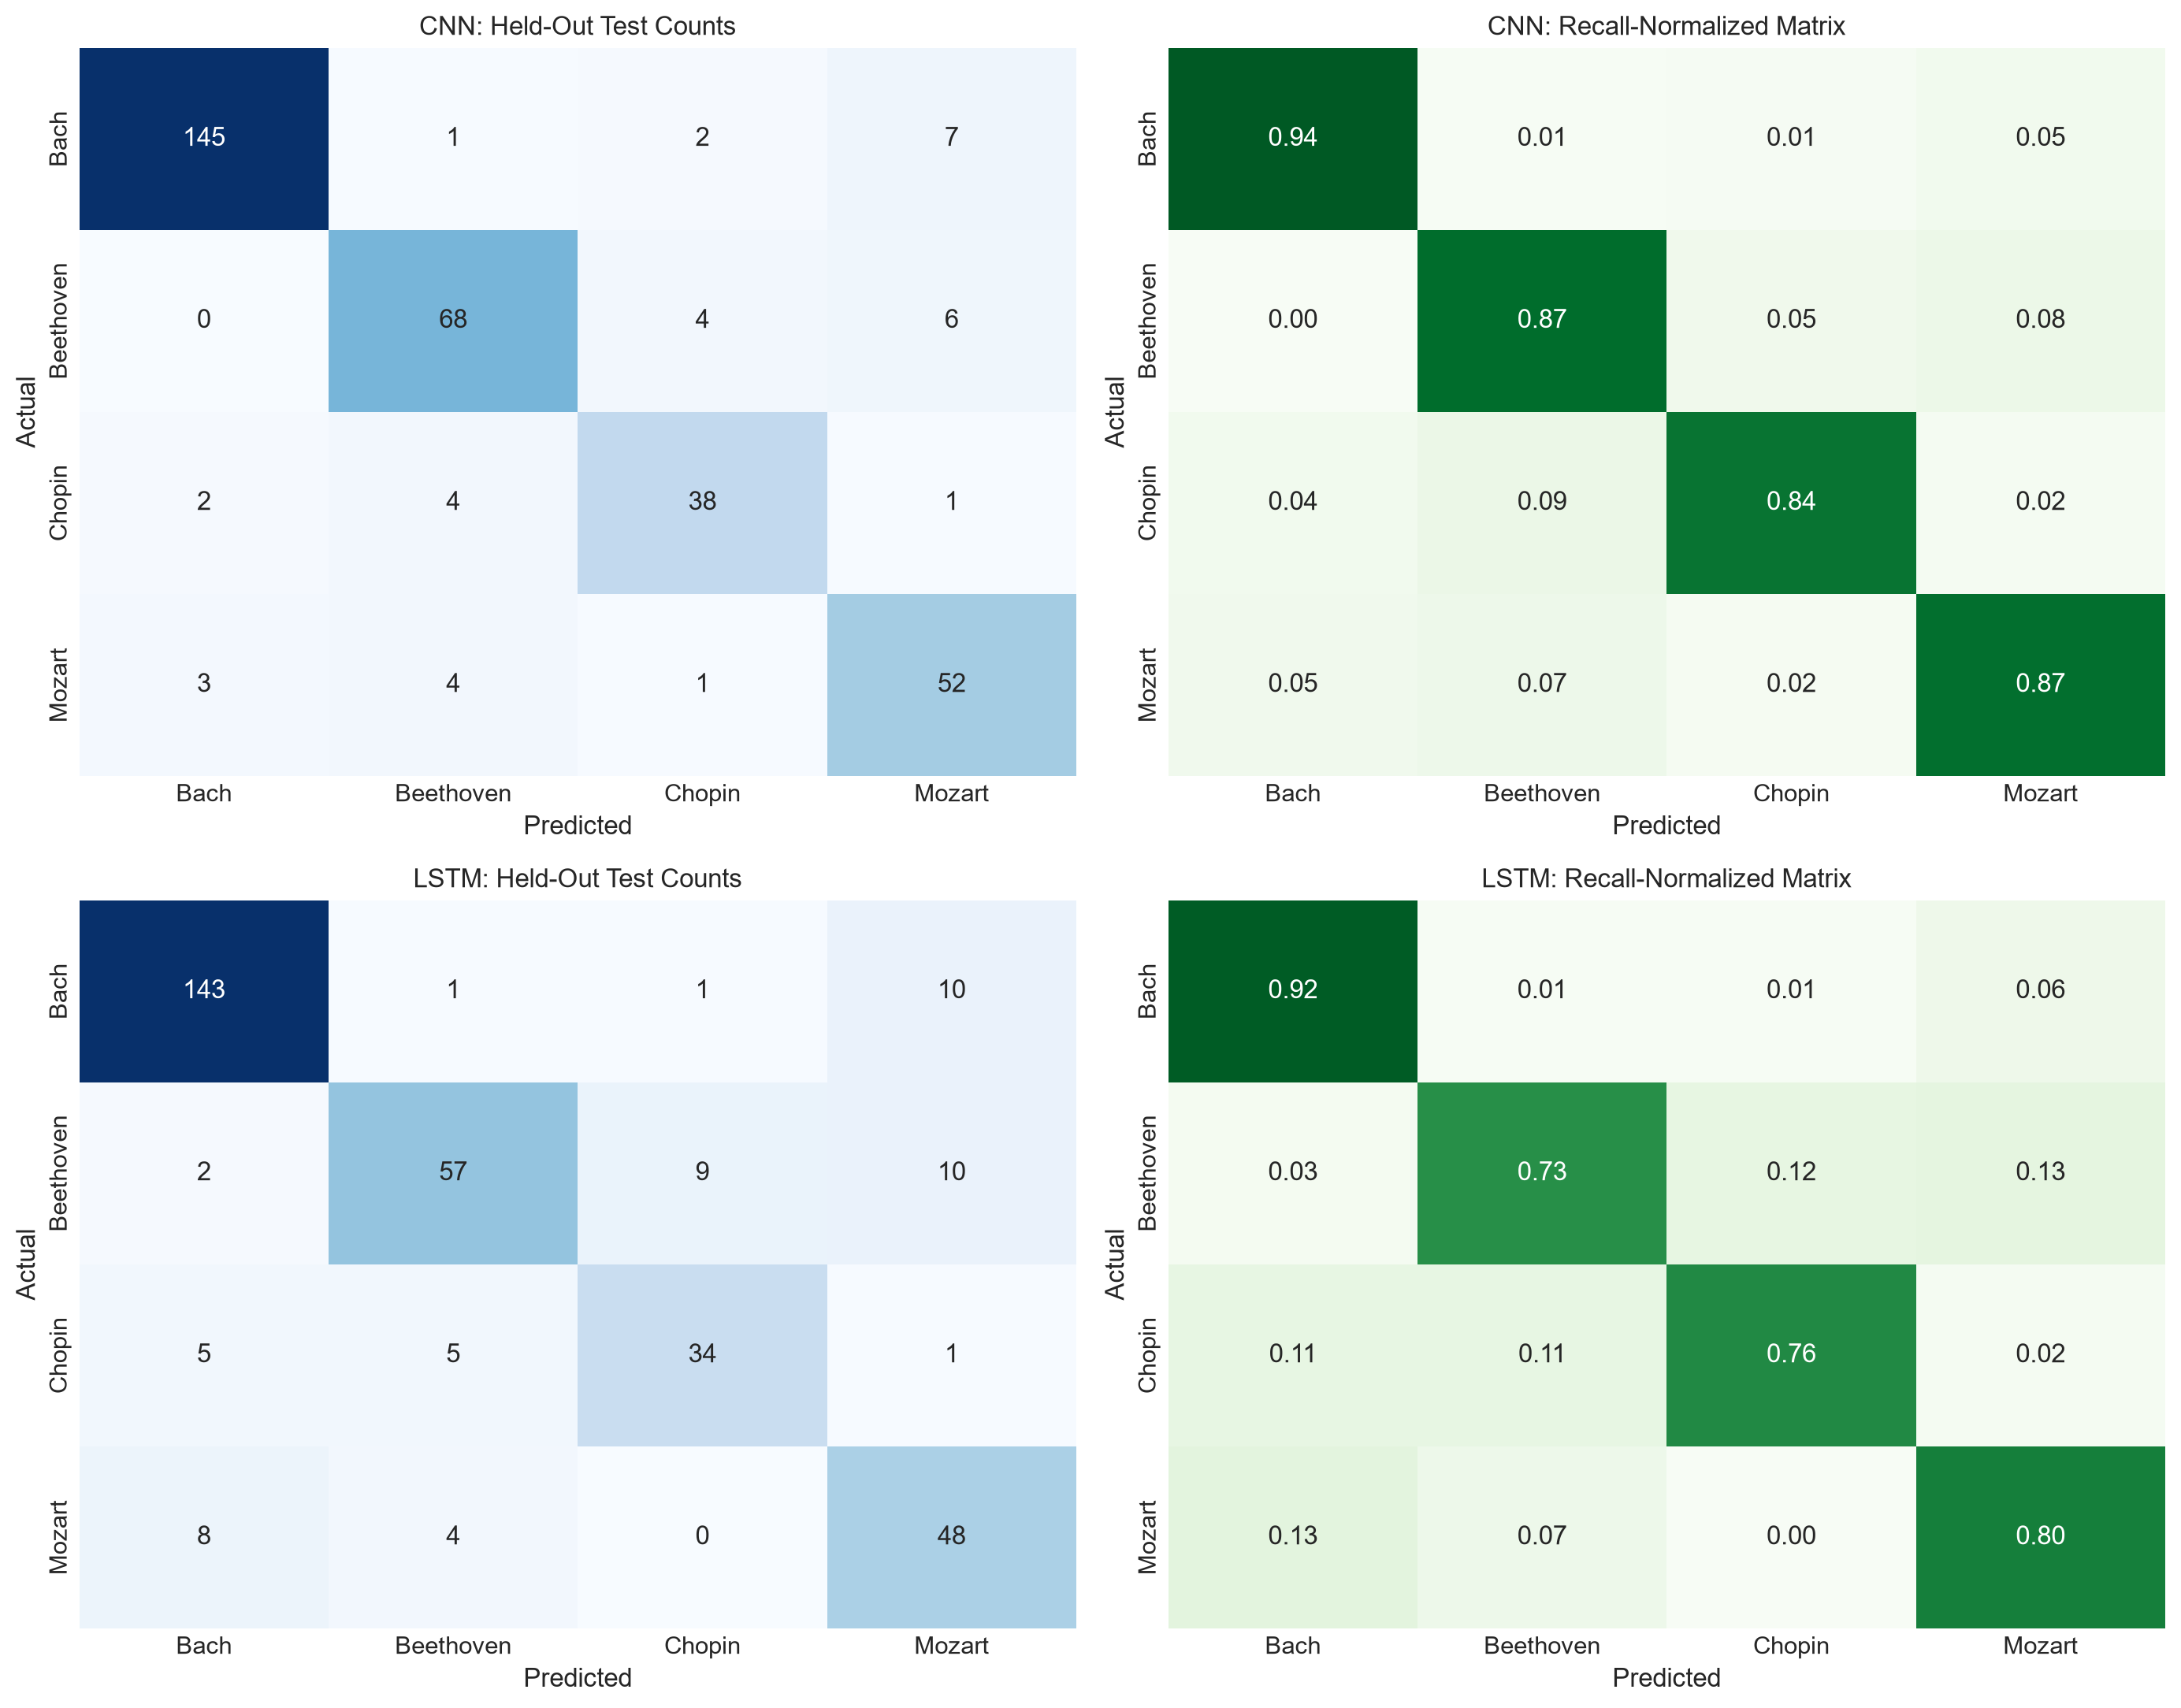

In [39]:
metrics_df.to_csv(ARTIFACT_DIR / "held_out_test_metrics.csv", index=False)

prediction_df = pd.DataFrame({
    "filename": test_df["filename"].values, "relative_path": test_df["relative_path"].values,
    "actual_composer": label_encoder.inverse_transform(y_test),
    "cnn_prediction": label_encoder.inverse_transform(cnn_predictions), "cnn_confidence": cnn_probabilities.max(axis=1),
    "lstm_prediction": label_encoder.inverse_transform(lstm_predictions), "lstm_confidence": lstm_probabilities.max(axis=1),
})
prediction_df.to_csv(ARTIFACT_DIR / "held_out_test_predictions.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (name, predictions) in enumerate({"CNN": cnn_predictions, "LSTM": lstm_predictions}.items()):
    raw = confusion_matrix(y_test, predictions, labels=class_ids)
    normalized = confusion_matrix(y_test, predictions, labels=class_ids, normalize="true")
    sns.heatmap(raw, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[row, 0])
    axes[row, 0].set(title=f"{name}: Held-Out Test Counts", xlabel="Predicted", ylabel="Actual")
    sns.heatmap(normalized, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, cbar=False,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[row, 1])
    axes[row, 1].set(title=f"{name}: Recall-Normalized Matrix", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

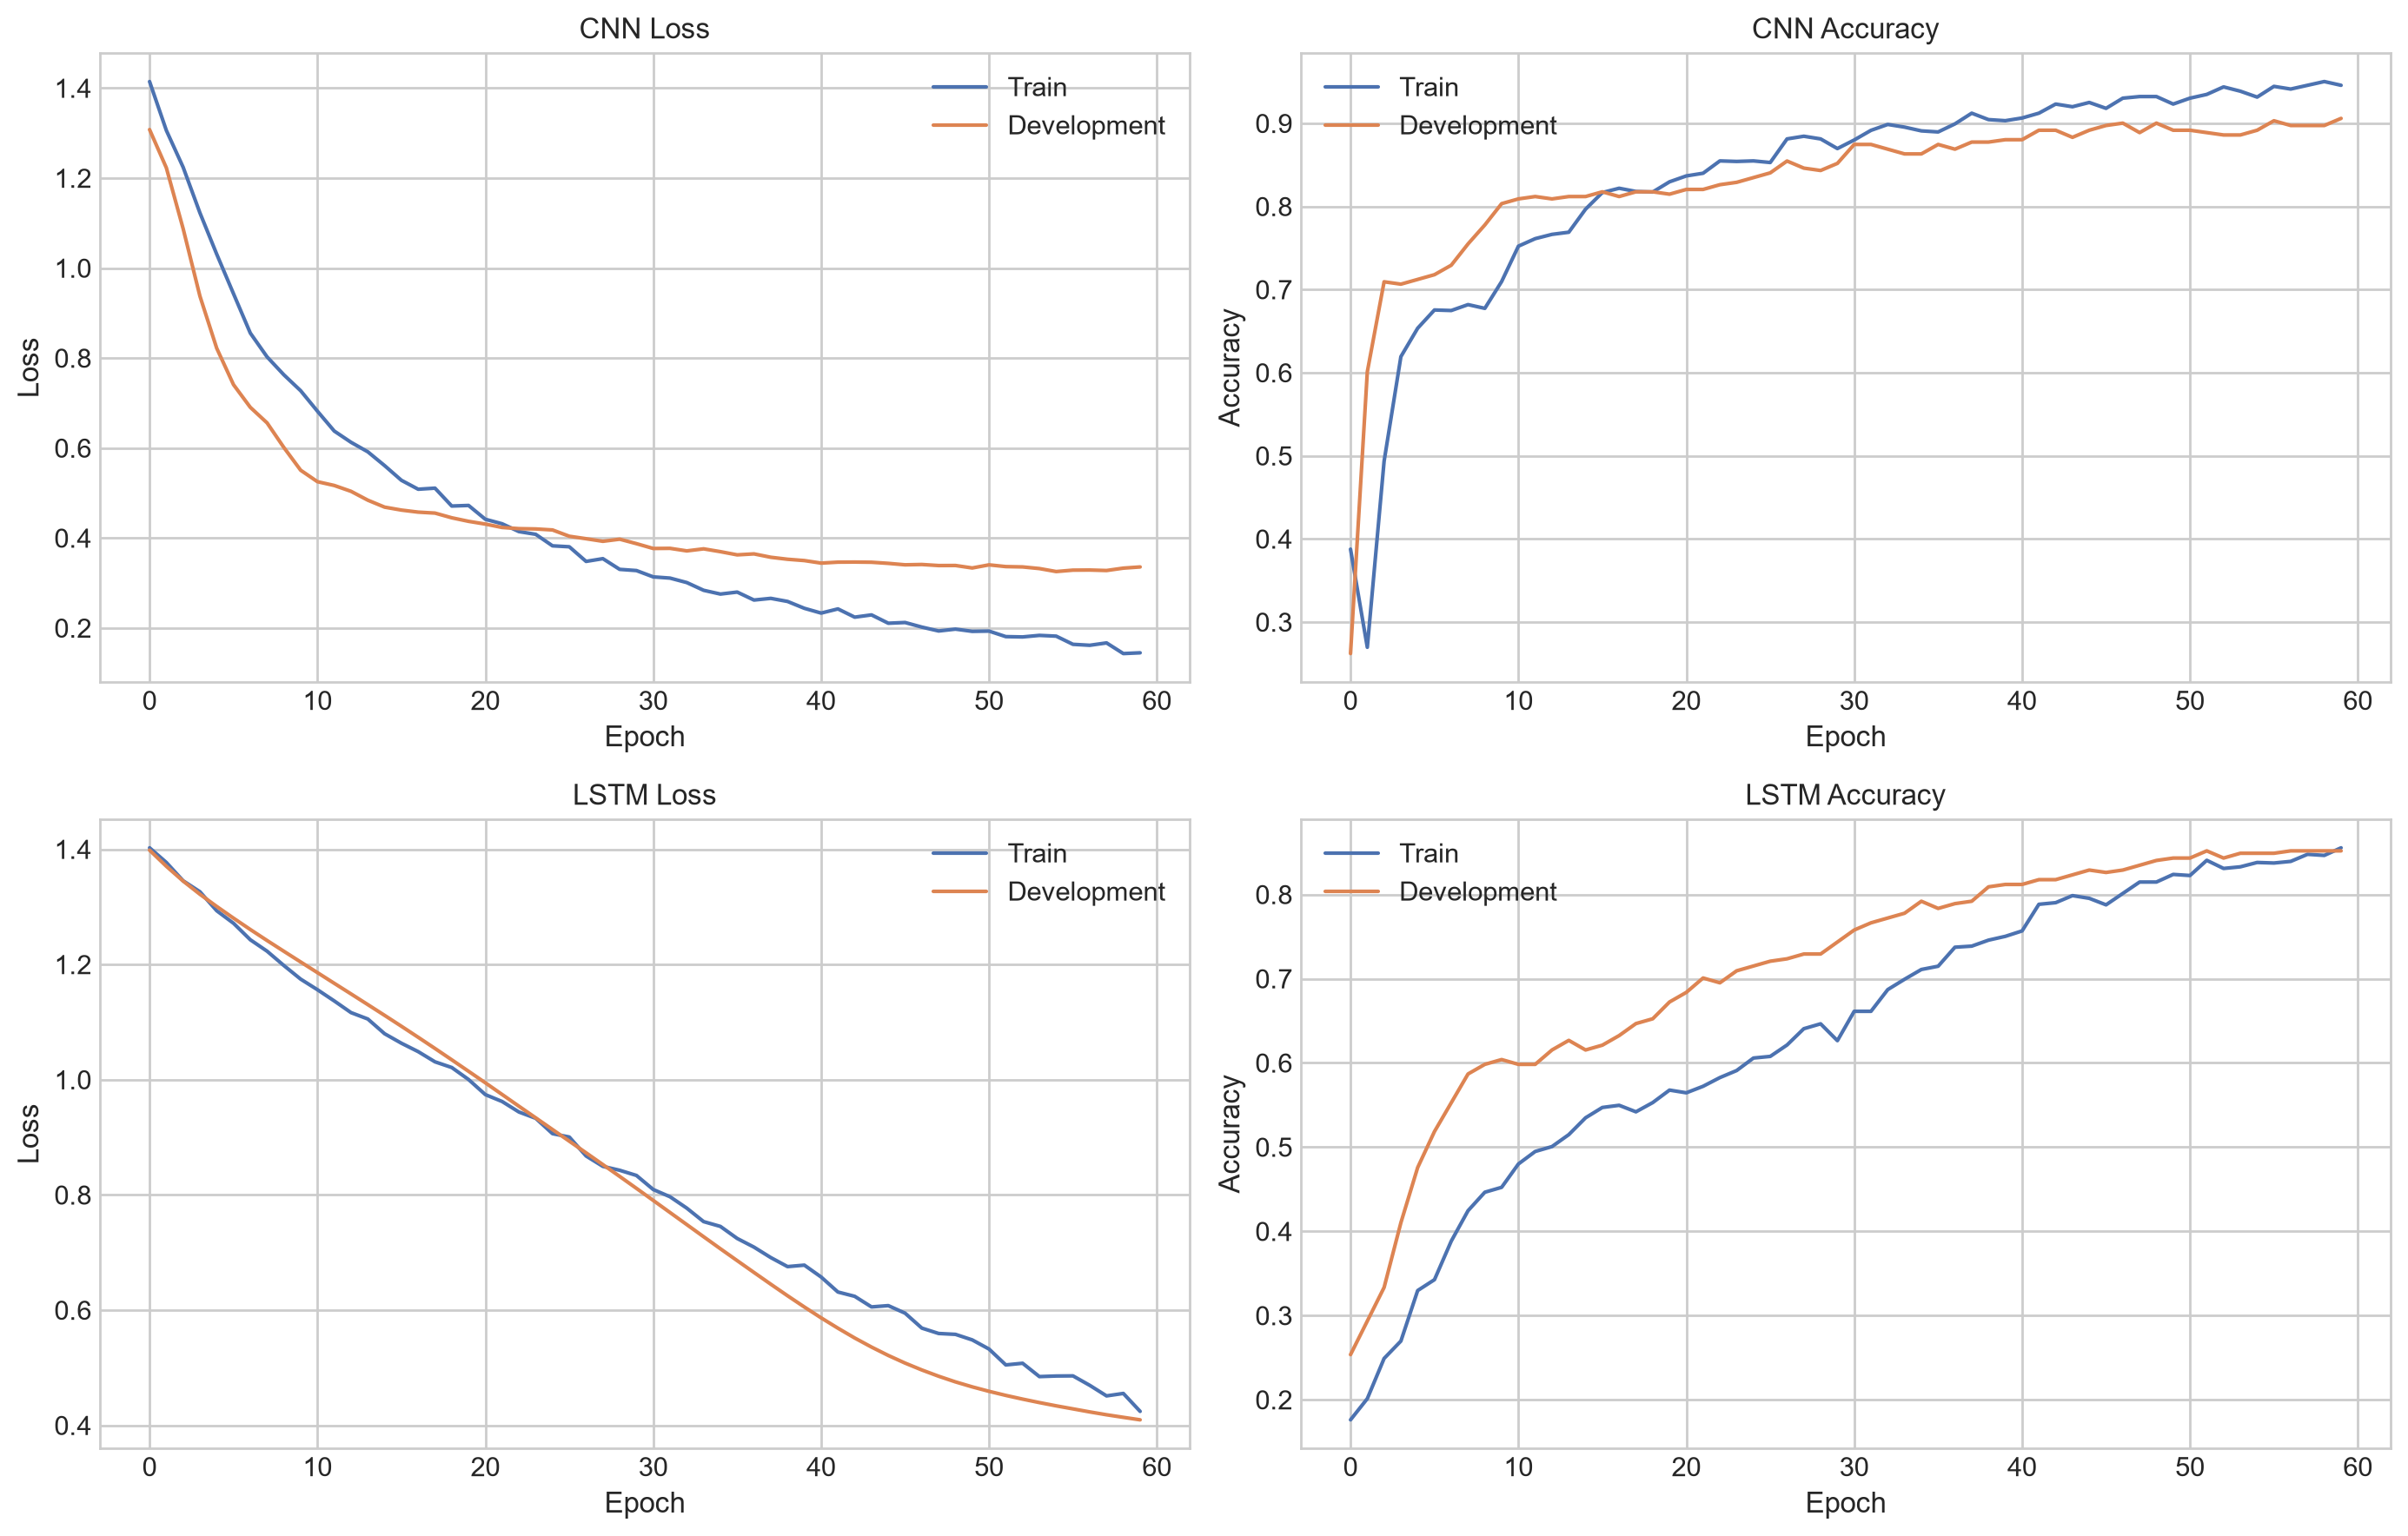

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (name, history) in enumerate({"CNN": cnn_history, "LSTM": lstm_history}.items()):
    axes[row, 0].plot(history.history["loss"], label="Train")
    axes[row, 0].plot(history.history["val_loss"], label="Development")
    axes[row, 0].set(title=f"{name} Loss", xlabel="Epoch", ylabel="Loss")
    axes[row, 0].legend()
    axes[row, 1].plot(history.history["accuracy"], label="Train")
    axes[row, 1].plot(history.history["val_accuracy"], label="Development")
    axes[row, 1].set(title=f"{name} Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[row, 1].legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "training_curves.png", dpi=150)
plt.show()

### 11.5 Observations

Captured-run held-out test results (refresh by executing the notebook): **CNN accuracy 0.896, macro F1 0.875; LSTM accuracy 0.834,
macro F1 0.802** — CNN is the stronger model. Per-class F1 (CNN test): Bach 0.95, Beethoven 0.88,
Chopin 0.85, Mozart 0.83 (LSTM: Bach 0.91, Beethoven 0.79, Chopin 0.76, Mozart 0.74). Both models
follow the same pattern — Bach (unchanged training count) is easiest, Mozart is hardest for both.

These numbers **do not match** Beakal's own notebook's markdown "Verified Reference Results"
table (LSTM 0.855 beating CNN 0.846) or `CNN_LSTM_Held_Out_Test_Metrics.csv` — see Section 14 for
the full reconciliation showing this run agrees closely with Beakal's own *executed* cell output
and an independent prior reproduction, and why the two "reference" numbers are stale.

## 12. Extended Evaluation: Test vs. Validation
**Original author: Sai Bandi** &nbsp;|&nbsp; Source: `composer_model_project/Composer_Classification_Evaluation.ipynb` &nbsp;|&nbsp; Treatment: **live**

Extends Section 11's test-only evaluation with: classification report and confusion matrices on
**both** test and validation, loss/accuracy curves with the final test score overlaid, multiclass
ROC curves, permutation feature importance, and SHAP — all computed on the **same** `cnn_model`/
`lstm_model` objects trained in Section 10 (no retraining here, so there is exactly one "CNN test
accuracy" number in this notebook, not two). The aliasing cell below only maps Section 8-11's
variable names onto the names this section's code was originally written against.

In [41]:
"""Alias Section 8-11\'s (Beakal\'s) variable names onto the names this section\'s original
code expects, so the code below is otherwise unchanged from Composer_Classification_Evaluation.ipynb.
No retraining happens here - X_val_*/y_val are the same "dev" split already used for model
selection in Section 10."""
X_val_cnn, X_val_lstm, y_val = X_dev_cnn, X_dev_lstm, y_dev
X_val_2d = X_dev_2d
class_names = label_encoder.classes_
classes_arr = class_ids
n_classes = NUM_CLASSES
n_features = len(feature_names)
feature_columns = feature_names
X_test_2d_alias = X_test_2d  # already named X_test_2d upstream; kept for clarity

cnn_reshape = lambda arr: arr[..., np.newaxis]
lstm_reshape = lambda arr: arr[:, np.newaxis, :]

log("SECTION 12", "Aliased dev->val naming; reusing cnn_model/lstm_model trained in Section 10")

[SECTION 12] Aliased dev->val naming; reusing cnn_model/lstm_model trained in Section 10


In [42]:
def evaluate_split(name, model, X, y_true):
    """Score a model on one data split and print its classification report.

    Args:
        name: Label for this (model, split) combination, e.g. "CNN-test".
        model: Trained Keras model.
        X: Feature array, already reshaped for this model.
        y_true: True integer class labels.

    Returns:
        Tuple of (metrics dict, predicted labels, predicted probabilities).
    """
    probabilities = model.predict(X, verbose=0)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, predictions, average="macro", zero_division=0)
    result = {"model_split": name, "accuracy": accuracy_score(y_true, predictions),
              "macro_precision": precision, "macro_recall": recall, "macro_f1": f1}
    print(f"\n{name}")
    print(classification_report(y_true, predictions, target_names=class_names, zero_division=0))
    return result, predictions, probabilities

eval_specs = [("CNN-test", cnn_model, X_test_cnn, y_test), ("CNN-val", cnn_model, X_val_cnn, y_val),
              ("LSTM-test", lstm_model, X_test_lstm, y_test), ("LSTM-val", lstm_model, X_val_lstm, y_val)]

eval_results = {}
for name, model, X, y_true in eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    eval_results[name] = {"result": result, "predictions": predictions, "probabilities": probabilities, "y_true": y_true}

results_df = pd.DataFrame([v["result"] for v in eval_results.values()]).set_index("model_split")
results_df.to_csv(OUTPUT_DIR / "test_vs_val_metrics.csv")
display(results_df.style.format("{:.3f}"))


CNN-test
              precision    recall  f1-score   support

        Bach       0.97      0.94      0.95       155
   Beethoven       0.88      0.87      0.88        78
      Chopin       0.84      0.84      0.84        45
      Mozart       0.79      0.87      0.83        60

    accuracy                           0.90       338
   macro avg       0.87      0.88      0.87       338
weighted avg       0.90      0.90      0.90       338


CNN-val
              precision    recall  f1-score   support

        Bach       0.95      0.95      0.95       153
   Beethoven       0.86      0.85      0.86        80
      Chopin       0.92      0.88      0.90        51
      Mozart       0.77      0.81      0.79        67

    accuracy                           0.89       351
   macro avg       0.88      0.87      0.87       351
weighted avg       0.89      0.89      0.89       351


LSTM-test
              precision    recall  f1-score   support

        Bach       0.91      0.92      0.91  

,accuracy,macro_precision,macro_recall,macro_f1
model_split,,,,
CNN-test,0.896,0.871,0.880,0.875
CNN-val,0.892,0.876,0.873,0.874
LSTM-test,0.834,0.806,0.802,0.802
LSTM-val,0.852,0.834,0.827,0.829


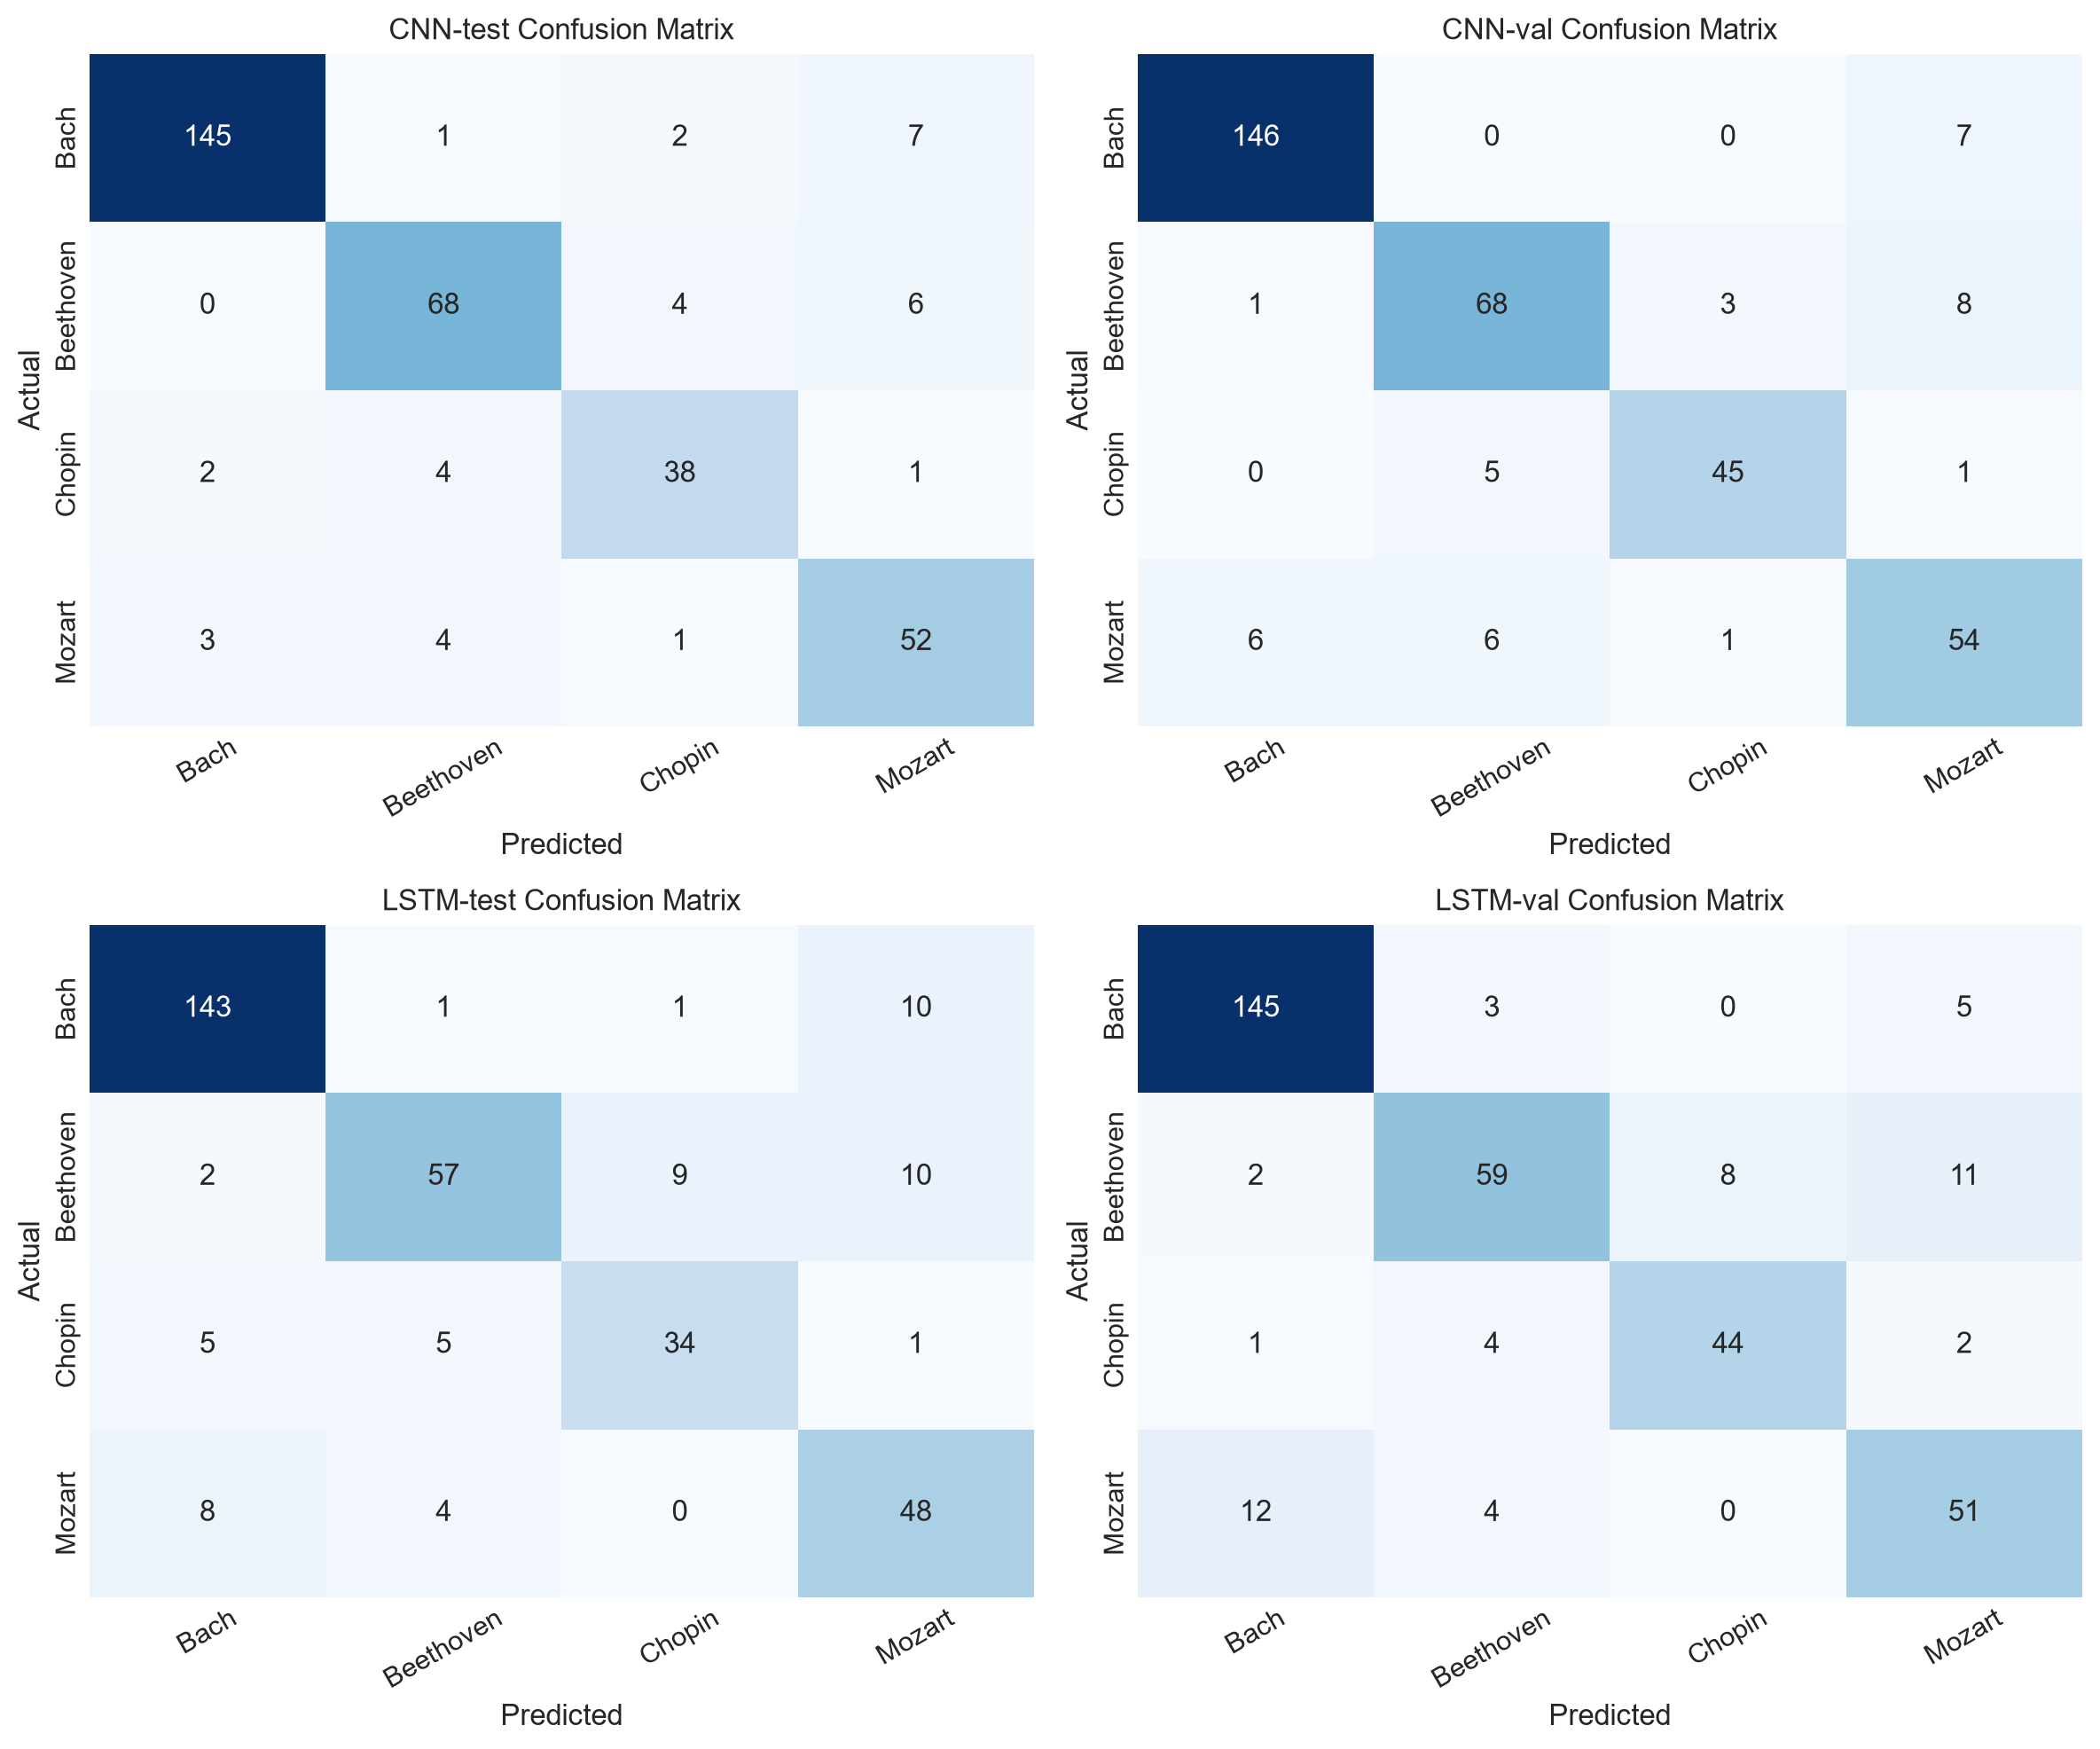

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    entry = eval_results[name]
    cm = confusion_matrix(entry["y_true"], entry["predictions"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=f"{name} Confusion Matrix", xlabel="Predicted", ylabel="Actual")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_test_vs_val.png", dpi=150)
plt.show()

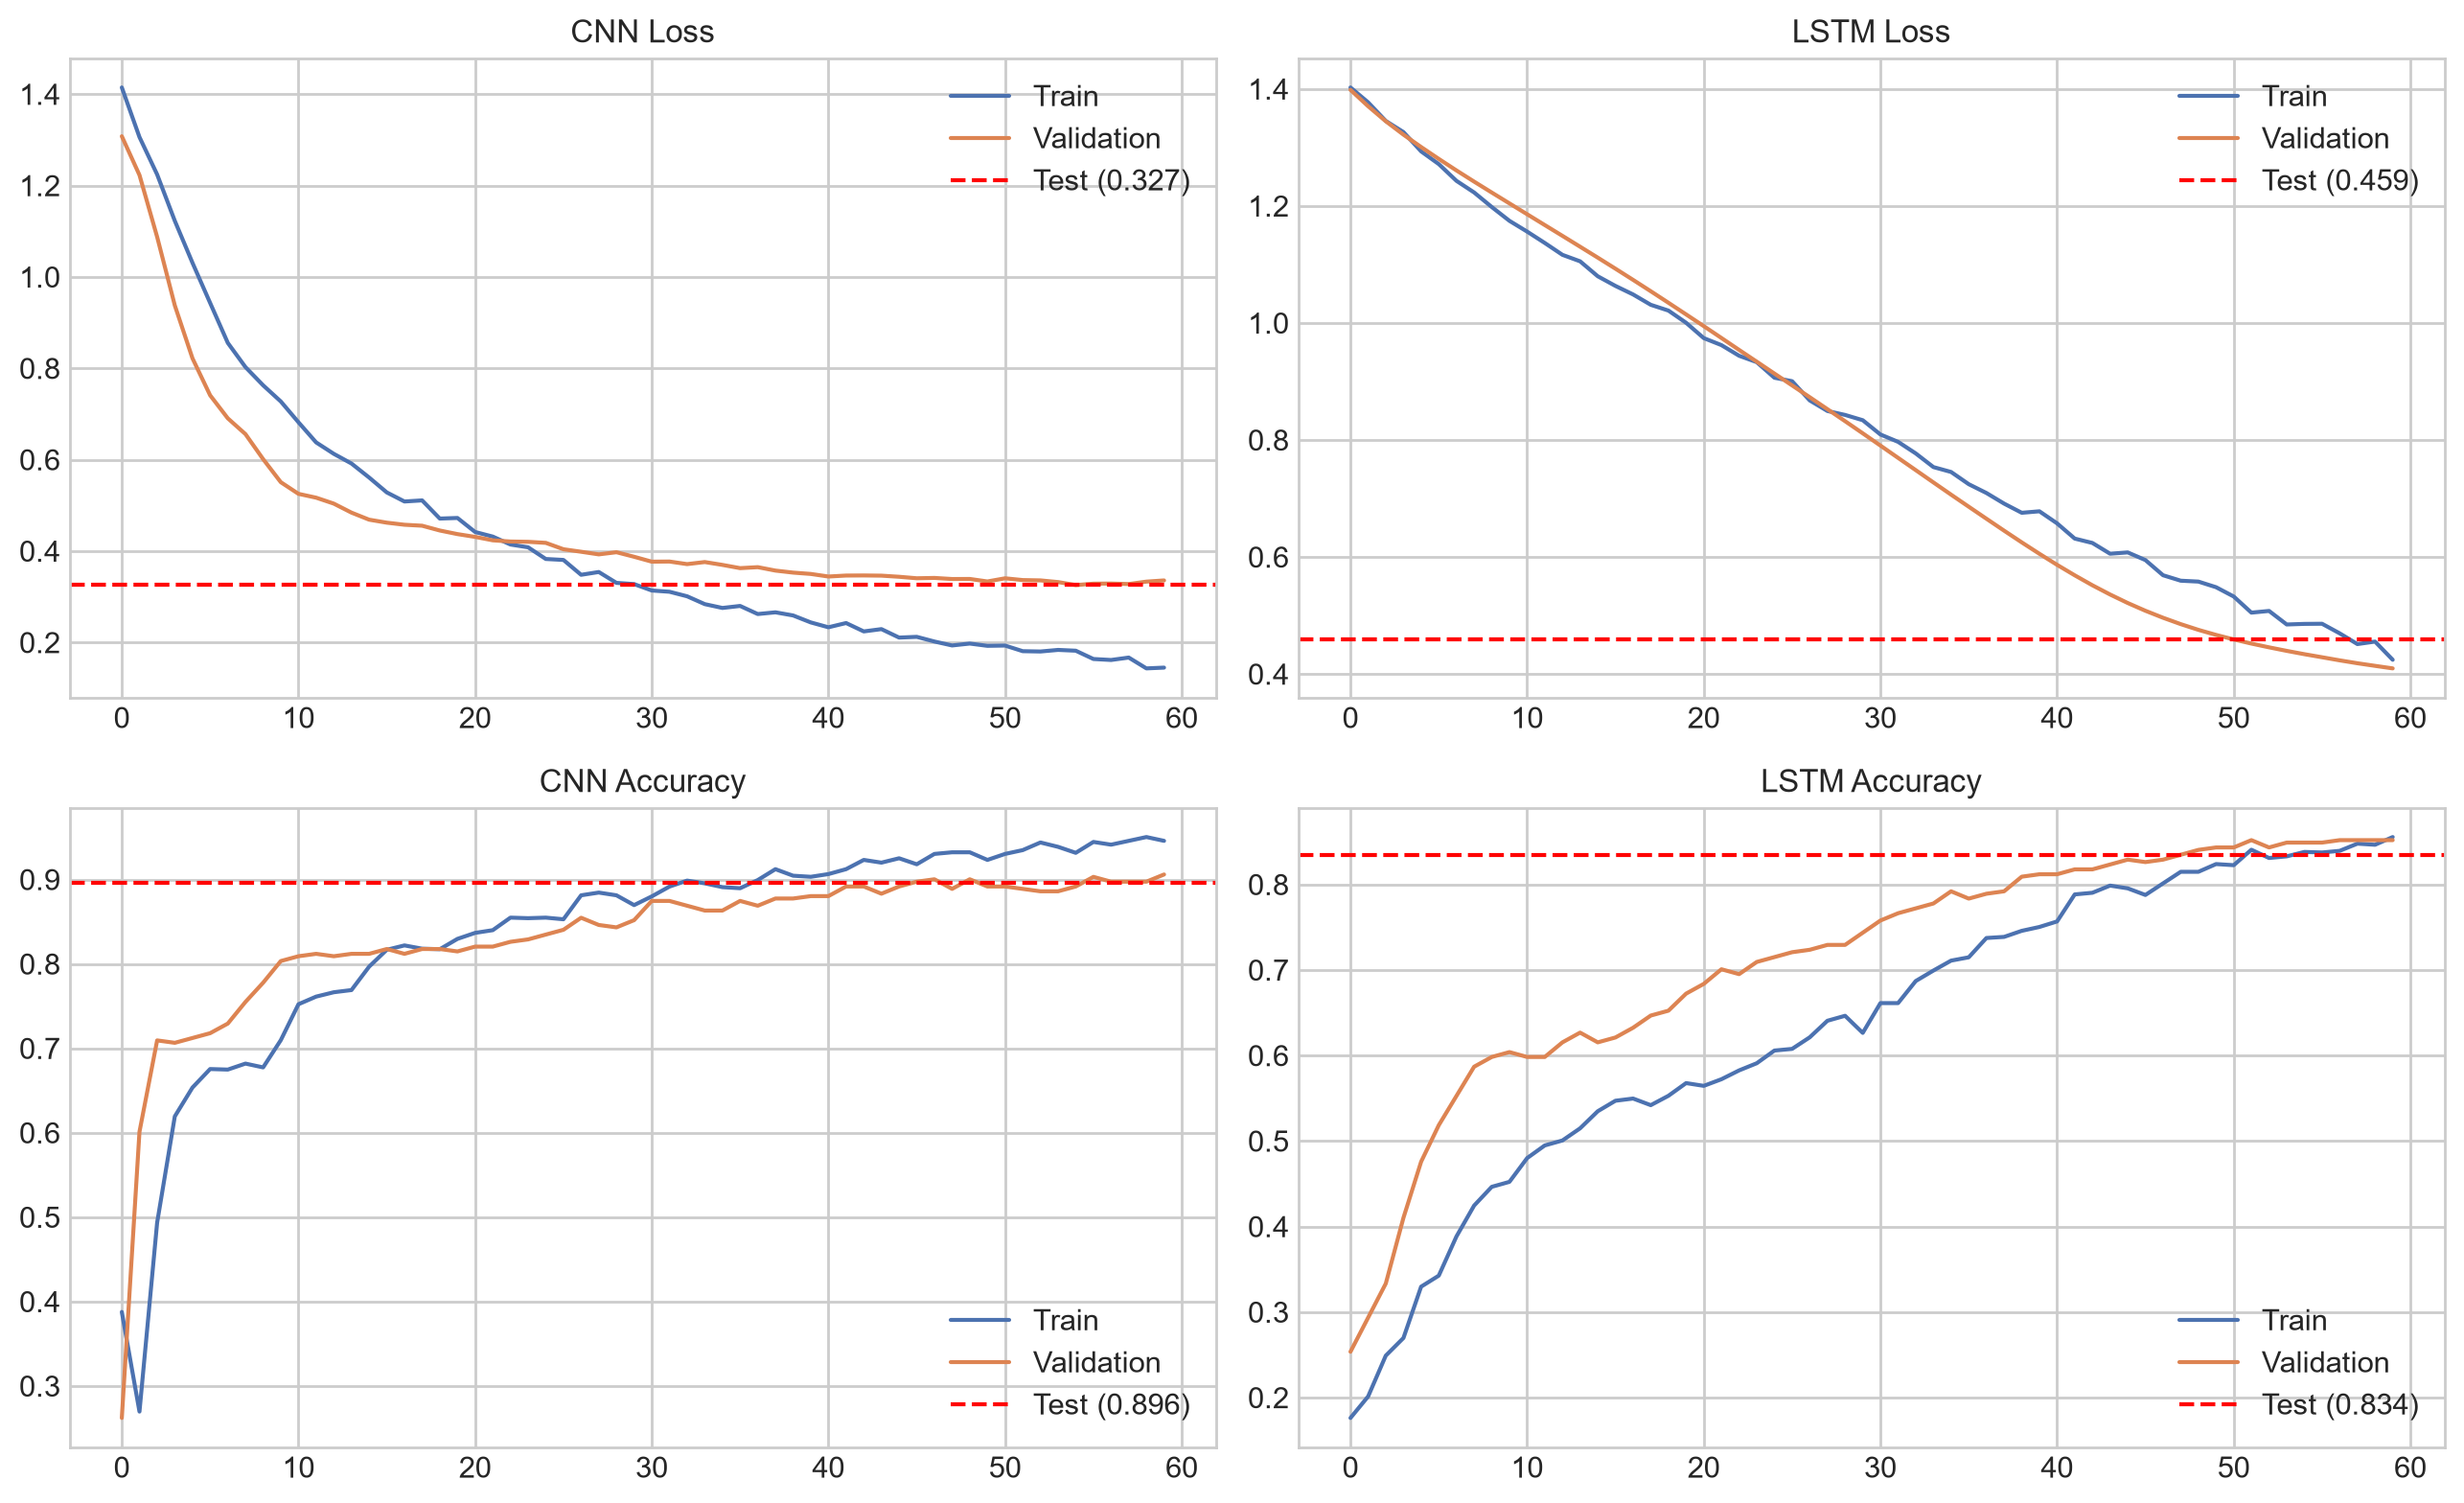

In [44]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
histories = [("CNN", cnn_history, cnn_test_loss, cnn_test_acc), ("LSTM", lstm_history, lstm_test_loss, lstm_test_acc)]
for col, (name, history, test_loss, test_acc) in enumerate(histories):
    axes[0, col].plot(history.history["loss"], label="Train")
    axes[0, col].plot(history.history["val_loss"], label="Validation")
    axes[0, col].axhline(test_loss, color="red", linestyle="--", label=f"Test ({test_loss:.3f})")
    axes[0, col].set_title(f"{name} Loss")
    axes[0, col].legend()
    axes[1, col].plot(history.history["accuracy"], label="Train")
    axes[1, col].plot(history.history["val_accuracy"], label="Validation")
    axes[1, col].axhline(test_acc, color="red", linestyle="--", label=f"Test ({test_acc:.3f})")
    axes[1, col].set_title(f"{name} Accuracy")
    axes[1, col].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_accuracy_curves_with_test.png", dpi=150)
plt.show()

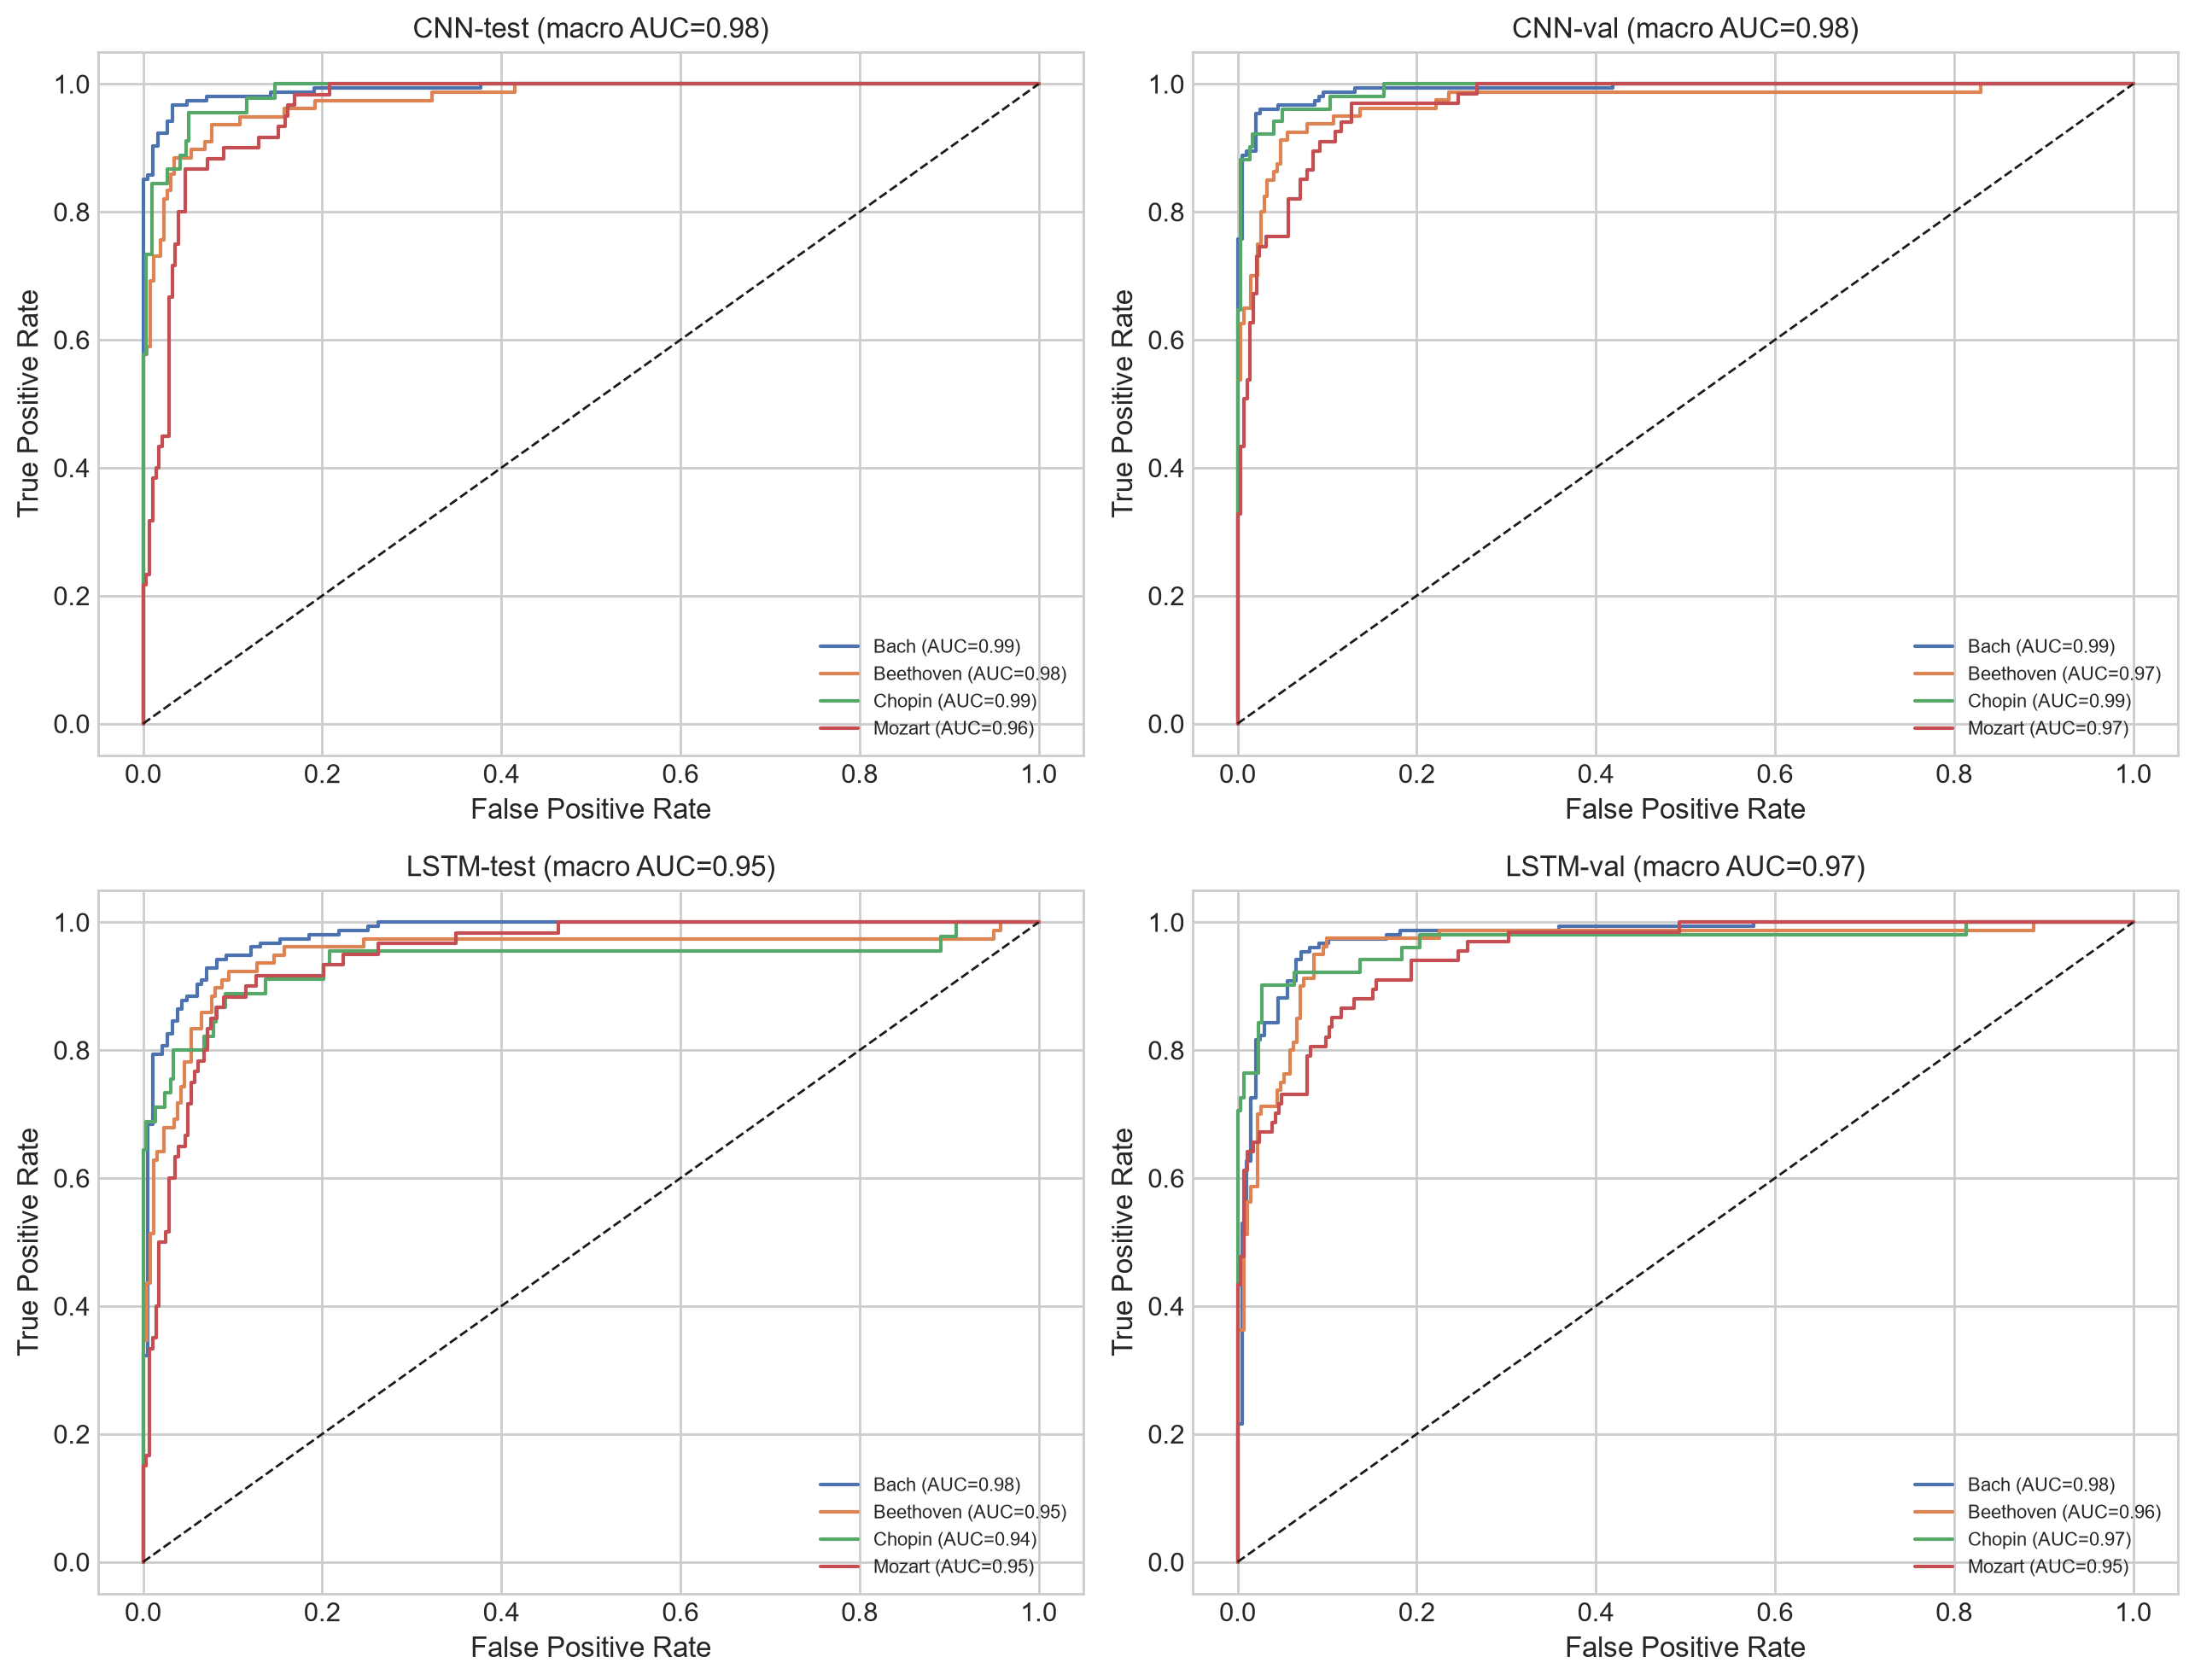

,Bach,Beethoven,Chopin,Mozart,macro_auc
model_split,,,,,
CNN-test,0.992,0.976,0.988,0.964,0.980
CNN-val,0.992,0.971,0.992,0.969,0.981
LSTM-test,0.980,0.949,0.938,0.948,0.954
LSTM-val,0.977,0.963,0.969,0.951,0.965


In [45]:
y_test_bin = label_binarize(y_test, classes=classes_arr)
y_val_bin = label_binarize(y_val, classes=classes_arr)

def plot_roc(ax, y_true_bin, probabilities, title):
    """Plot one-vs-rest ROC curves for all classes on a single axis.

    Args:
        ax: Matplotlib axis to draw on.
        y_true_bin: Label-binarized ground truth, shape (n_samples, n_classes).
        probabilities: Predicted class probabilities, shape (n_samples, n_classes).
        title: Panel title.

    Returns:
        List of per-class AUC values.
    """
    aucs = []
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set(title=f"{title} (macro AUC={np.mean(aucs):.2f})", xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax.legend(fontsize=8)
    return aucs

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
roc_specs = [("CNN-test", axes[0, 0], y_test_bin, eval_results["CNN-test"]["probabilities"]),
             ("CNN-val", axes[0, 1], y_val_bin, eval_results["CNN-val"]["probabilities"]),
             ("LSTM-test", axes[1, 0], y_test_bin, eval_results["LSTM-test"]["probabilities"]),
             ("LSTM-val", axes[1, 1], y_val_bin, eval_results["LSTM-val"]["probabilities"])]
roc_auc_records = []
for name, ax, y_bin, probs in roc_specs:
    aucs = plot_roc(ax, y_bin, probs, name)
    roc_auc_records.append({"model_split": name, **{cls: a for cls, a in zip(class_names, aucs)}, "macro_auc": np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_test_vs_val.png", dpi=150)
plt.show()

roc_auc_df = pd.DataFrame(roc_auc_records).set_index("model_split")
roc_auc_df.to_csv(OUTPUT_DIR / "roc_auc_test_vs_val.csv")
display(roc_auc_df.style.format("{:.3f}"))

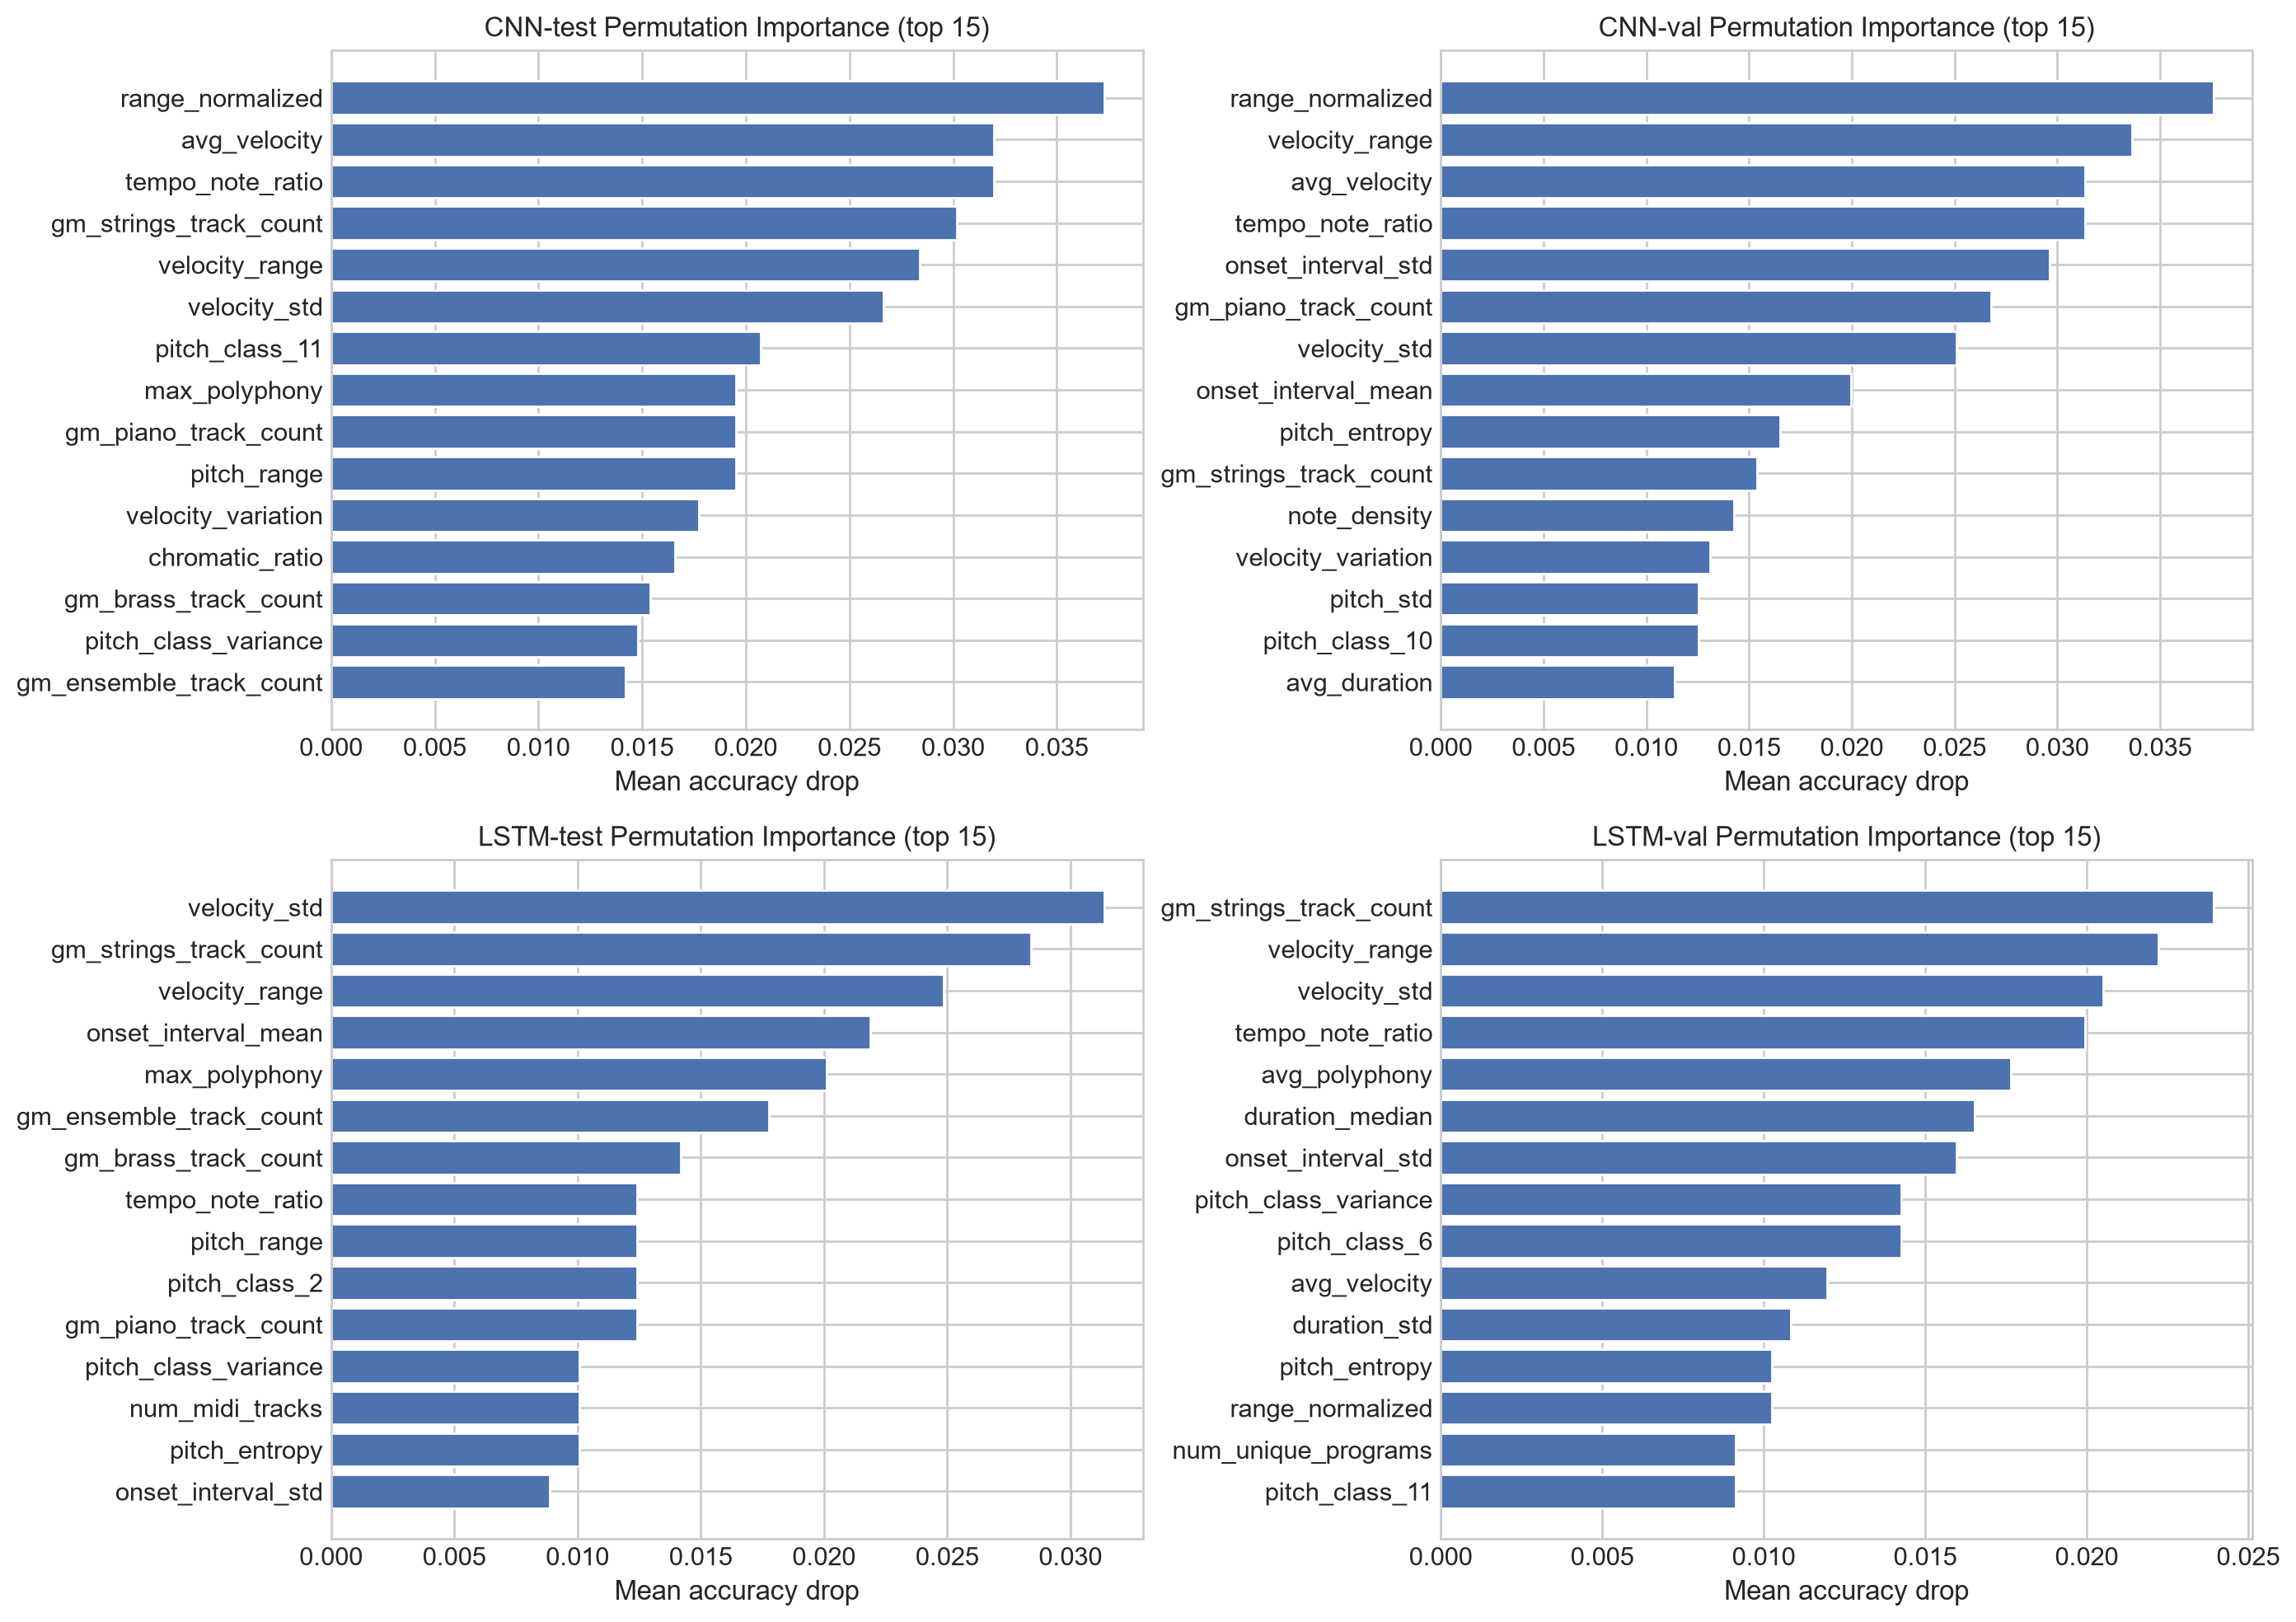

In [46]:
def permutation_importance_manual(model, X_2d, y_true, feature_names_, reshape_fn, n_repeats=5, seed=SEED):
    """Compute per-feature permutation importance by shuffling one column at a time.

    Args:
        model: Trained Keras model.
        X_2d: Unshuffled 2D feature array (n_samples, n_features).
        y_true: True integer class labels.
        feature_names_: Column names corresponding to X_2d\'s columns.
        reshape_fn: Function mapping a 2D array to this model\'s expected input shape.
        n_repeats: Number of shuffles averaged per feature.
        seed: Random seed for the shuffles.

    Returns:
        Series of mean accuracy drop per feature, sorted descending (most important first).
    """
    rng = np.random.default_rng(seed)
    baseline_preds = model.predict(reshape_fn(X_2d), verbose=0).argmax(axis=1)
    baseline_acc = accuracy_score(y_true, baseline_preds)
    importances = np.zeros(len(feature_names_))
    for col_idx in range(X_2d.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_2d.copy()
            X_permuted[:, col_idx] = rng.permutation(X_permuted[:, col_idx])
            permuted_preds = model.predict(reshape_fn(X_permuted), verbose=0).argmax(axis=1)
            drops.append(baseline_acc - accuracy_score(y_true, permuted_preds))
        importances[col_idx] = np.mean(drops)
    return pd.Series(importances, index=feature_names_, name="importance").sort_values(ascending=False)

perm_importance = {
    "CNN-test": permutation_importance_manual(cnn_model, X_test_2d, y_test, feature_columns, cnn_reshape),
    "CNN-val": permutation_importance_manual(cnn_model, X_val_2d, y_val, feature_columns, cnn_reshape),
    "LSTM-test": permutation_importance_manual(lstm_model, X_test_2d, y_test, feature_columns, lstm_reshape),
    "LSTM-val": permutation_importance_manual(lstm_model, X_val_2d, y_val, feature_columns, lstm_reshape),
}
perm_importance_df = pd.DataFrame(perm_importance)
perm_importance_df.to_csv(OUTPUT_DIR / "permutation_importance.csv")

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    top_features = perm_importance[name].head(TOP_N)
    ax.barh(top_features.index[::-1], top_features.values[::-1])
    ax.set(title=f"{name} Permutation Importance (top {TOP_N})", xlabel="Mean accuracy drop")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance_test_vs_val.png", dpi=150)
plt.show()

In [47]:
N_BACKGROUND = 100
N_EXPLAIN = 100

try:
    import shap

    rng = np.random.default_rng(SEED)
    background_idx = rng.choice(X_train_2d.shape[0], size=min(N_BACKGROUND, X_train_2d.shape[0]), replace=False)
    explain_idx = rng.choice(X_test_2d.shape[0], size=min(N_EXPLAIN, X_test_2d.shape[0]), replace=False)

    def shap_summary(model, reshape_fn, model_name):
        """Compute and save SHAP summary plots for one model, per composer class.

        Uses the fully model-agnostic KernelExplainer (only calls model.predict) rather than
        DeepExplainer. DeepExplainer registers custom TensorFlow gradient ops as a side effect
        that were found to corrupt Section 13\'s later, unrelated Keras Tuner training in this
        consolidated notebook (a real TF/SHAP global-state interaction, not specific to one
        model) - KernelExplainer avoids touching the gradient tape entirely, at the cost of
        being slower.

        Args:
            model: Trained Keras model.
            reshape_fn: Function mapping a 2D array to this model\'s expected input shape.
            model_name: Label used in saved filenames and plot titles.
        """
        sample_2d = X_test_2d[explain_idx]
        predict_fn = lambda x: model.predict(reshape_fn(x), verbose=0)
        explainer = shap.KernelExplainer(predict_fn, X_train_2d[background_idx])
        shap_values = explainer.shap_values(sample_2d, nsamples=100)

        for class_idx, cls_name in enumerate(class_names):
            values = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[..., class_idx]
            values_2d = np.asarray(values).reshape(values.shape[0], -1)[:, :len(feature_columns)]
            plt.figure()
            shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)
            plt.title(f"{model_name} SHAP summary - {cls_name}")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f"shap_summary_{model_name.lower()}_{cls_name.lower()}.png", dpi=150)
            plt.close()
        print(f"Saved SHAP summary plots for {model_name}.")

    for model_name, model, reshape_fn in [("CNN", cnn_model, cnn_reshape), ("LSTM", lstm_model, lstm_reshape)]:
        try:
            shap_summary(model, reshape_fn, model_name)
        except Exception as exc:
            print(f"SHAP explanation failed for {model_name}, skipping: {exc}")

except ImportError:
    print("shap is not installed - run \'%pip install shap\' in a cell above, then restart the kernel and re-run this cell.")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved SHAP summary plots for CNN.


  0%|          | 0/100 [00:00<?, ?it/s]

Saved SHAP summary plots for LSTM.


### 12.7 Observations

**Captured-run observation: the test vs. validation gap is small for both models** (CNN: 0.896 test / 0.892 val accuracy;
LSTM: 0.834 test / 0.852 val accuracy) — no sign of overfitting to the validation split used for
early stopping. **ROC-AUC**: CNN stays ≥0.96 on every class on both splits (macro AUC 0.980
test); LSTM is weaker but still strong (macro AUC 0.954 test), with Mozart its consistent
weakest class (AUC 0.948 test) — consistent with Mozart also being the hardest class by F1.

**Feature importance**: both models lean most heavily on **velocity and timing features**
(`velocity_std`, `velocity_range`, `avg_velocity`, `tempo_note_ratio`, `onset_interval_mean`,
`gm_strings_track_count`) rather than pitch statistics — a shift from what the original
single-source dataset's models relied on (pitch-class histogram bins). Because the new training
data was harvested from several different MIDI collections with likely-different production and
recording characteristics, this is worth treating as a flag rather than a confirmed finding: the
models may be partly picking up on *source* characteristics alongside genuine composer style. See
Section 17 for the recommended follow-up (checking whether velocity statistics differ by source
independent of composer).

## 13. Hyperparameter Tuning
**Original author: Sai Bandi** &nbsp;|&nbsp; Source: `composer_model_project/Composer_Classification_Evaluation_Tuned.ipynb` &nbsp;|&nbsp; Treatment: **live**

A Keras Tuner Hyperband search over the Section 9 architecture family, selecting on `val_accuracy`
only (the held-out test set is never touched during the search). The winning configuration for
each model is retrained with the full Section 10 training budget (60 epochs, full-batch,
`EarlyStopping`/`ReduceLROnPlateau`) to produce a complete history, then re-evaluated with the
same Section 12 evaluation suite. Functions are named `build_tuned_cnn(hp)`/`build_tuned_lstm(hp)`
and models `tuned_cnn_model`/`tuned_lstm_model` to avoid colliding with Section 9's fixed-
architecture `build_baseline_cnn()`/`build_baseline_lstm()` and Section 10's `cnn_model`/
`lstm_model`.

In [48]:
def build_tuned_cnn(hp):
    """Build a CNN with tunable hyperparameters, for Keras Tuner search.

    Search space centered on Section 9\'s architecture (16 conv1 filters, 32 conv2 filters,
    32 dense units, 0.3 dropout, lr 5e-3). Kernel sizes and L2 regularization strength are
    kept fixed to match the original design.

    Args:
        hp: A keras_tuner.HyperParameters instance.

    Returns:
        A compiled tf.keras.Sequential model.
    """
    conv1_filters = hp.Choice("conv1_filters", [8, 16, 24, 32])
    conv2_filters = hp.Choice("conv2_filters", [16, 24, 32, 48])
    dense_units = hp.Choice("dense_units", [16, 32, 48, 64])
    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)
    learning_rate = hp.Choice("learning_rate", [1e-2, 5e-3, 1e-3])

    model = Sequential([
        Input(shape=X_train_cnn.shape[1:]),
        Conv1D(conv1_filters, kernel_size=5, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Conv1D(conv2_filters, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name="composer_cnn_tuned")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tuner_cnn = kt.Hyperband(
    build_tuned_cnn, objective="val_accuracy", max_epochs=20, factor=3, seed=SEED,
    directory=str(OUTPUT_DIR / "kt_search"), project_name="cnn", overwrite=True,
)
tuner_cnn.search(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev), batch_size=len(X_train_cnn),
    class_weight=class_weights, callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)
best_cnn_hp = tuner_cnn.get_best_hyperparameters(1)[0]
log("SECTION 13", f"Best CNN hyperparameters: {best_cnn_hp.values}")

Trial 2 Complete [00h 00m 00s]

Best val_accuracy So Far: None
Total elapsed time: 00h 00m 00s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
32                |24                |conv1_filters
32                |16                |conv2_filters
64                |32                |dense_units
0.2               |0.2               |dropout
0.001             |0.001             |learning_rate
3                 |3                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round



Traceback (most recent call last):
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\tuners\hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._configure_tensorboard_dir(callbacks, trial, execution)
  File "c:\Users\Ma

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\tuners\hyperband.py", line 427, in run_trial
    return super().run_trial(trial, *fit_args, **fit_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Maxtw\OneDrive\Desktop\511 Project\.venv\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 309, in run_trial
    self._conf

In [ ]:
def build_tuned_lstm(hp):
    """Build an LSTM with tunable hyperparameters, for Keras Tuner search.

    Search space centered on Section 9\'s architecture (32 LSTM units, 32 dense units,
    0.3/0.2 dropout, lr 3e-3).

    Args:
        hp: A keras_tuner.HyperParameters instance.

    Returns:
        A compiled tf.keras.Model.
    """
    lstm_units = hp.Choice("lstm_units", [16, 32, 48, 64])
    dropout1 = hp.Float("dropout1", 0.2, 0.4, step=0.05)
    dense_units = hp.Choice("dense_units", [16, 32, 48])
    dropout2 = hp.Float("dropout2", 0.1, 0.3, step=0.05)
    learning_rate = hp.Choice("learning_rate", [1e-2, 5e-3, 3e-3, 1e-3])

    inputs = Input(shape=X_train_lstm.shape[1:])
    x = LSTM(lstm_units)(inputs)
    x = Dropout(dropout1)(x)
    x = Dense(dense_units, activation="relu")(x)
    x = Dropout(dropout2)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs, name="composer_lstm_tuned")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tuner_lstm = kt.Hyperband(
    build_tuned_lstm, objective="val_accuracy", max_epochs=20, factor=3, seed=SEED,
    directory=str(OUTPUT_DIR / "kt_search"), project_name="lstm", overwrite=True,
)
tuner_lstm.search(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev), batch_size=len(X_train_lstm),
    class_weight=class_weights, callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)
best_lstm_hp = tuner_lstm.get_best_hyperparameters(1)[0]
log("SECTION 13", f"Best LSTM hyperparameters: {best_lstm_hp.values}")

In [ ]:
"""Retrain the winning configurations with the full Section 10 training budget."""
tuned_cnn_model = tuner_cnn.hypermodel.build(best_cnn_hp)
tuned_cnn_history = tuned_cnn_model.fit(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev), epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights, callbacks=callbacks_for("tuned_cnn"), verbose=1,
)
with open(OUTPUT_DIR / "best_hyperparameters_cnn.json", "w") as f:
    json.dump(best_cnn_hp.values, f, indent=2)

In [ ]:
tuned_lstm_model = tuner_lstm.hypermodel.build(best_lstm_hp)
tuned_lstm_history = tuned_lstm_model.fit(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev), epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights, callbacks=callbacks_for("tuned_lstm"), verbose=1,
)
with open(OUTPUT_DIR / "best_hyperparameters_lstm.json", "w") as f:
    json.dump(best_lstm_hp.values, f, indent=2)

### 13.5 Tuned model evaluation

Same evaluation suite as Section 12, applied to the tuned models.

In [ ]:
tuned_eval_specs = [("CNN-test", tuned_cnn_model, X_test_cnn, y_test), ("CNN-val", tuned_cnn_model, X_val_cnn, y_val),
                    ("LSTM-test", tuned_lstm_model, X_test_lstm, y_test), ("LSTM-val", tuned_lstm_model, X_val_lstm, y_val)]

tuned_eval_results = {}
for name, model, X, y_true in tuned_eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    tuned_eval_results[name] = {"result": result, "predictions": predictions, "probabilities": probabilities, "y_true": y_true}

tuned_results_df = pd.DataFrame([v["result"] for v in tuned_eval_results.values()]).set_index("model_split")
tuned_results_df.to_csv(OUTPUT_DIR / "tuned_test_vs_val_metrics.csv")
display(tuned_results_df.style.format("{:.3f}"))

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    entry = tuned_eval_results[name]
    cm = confusion_matrix(entry["y_true"], entry["predictions"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=f"{name} Confusion Matrix (tuned)", xlabel="Predicted", ylabel="Actual")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tuned_confusion_matrices_test_vs_val.png", dpi=150)
plt.show()

In [ ]:
tuned_y_test_bin = label_binarize(y_test, classes=classes_arr)
tuned_y_val_bin = label_binarize(y_val, classes=classes_arr)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
tuned_roc_specs = [("CNN-test", axes[0, 0], tuned_y_test_bin, tuned_eval_results["CNN-test"]["probabilities"]),
                   ("CNN-val", axes[0, 1], tuned_y_val_bin, tuned_eval_results["CNN-val"]["probabilities"]),
                   ("LSTM-test", axes[1, 0], tuned_y_test_bin, tuned_eval_results["LSTM-test"]["probabilities"]),
                   ("LSTM-val", axes[1, 1], tuned_y_val_bin, tuned_eval_results["LSTM-val"]["probabilities"])]
tuned_roc_auc_records = []
for name, ax, y_bin, probs in tuned_roc_specs:
    aucs = plot_roc(ax, y_bin, probs, f"{name} (tuned)")
    tuned_roc_auc_records.append({"model_split": name, **{cls: a for cls, a in zip(class_names, aucs)}, "macro_auc": np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tuned_roc_curves_test_vs_val.png", dpi=150)
plt.show()

tuned_roc_auc_df = pd.DataFrame(tuned_roc_auc_records).set_index("model_split")
tuned_roc_auc_df.to_csv(OUTPUT_DIR / "tuned_roc_auc_test_vs_val.csv")
display(tuned_roc_auc_df.style.format("{:.3f}"))

### 13.9 Tuned vs. untuned comparison

In [ ]:
_base = results_df.copy()
_base.index = [f"{i} (untuned)" for i in _base.index]
_tuned = tuned_results_df.copy()
_tuned.index = [f"{i} (tuned)" for i in _tuned.index]
tuned_vs_untuned_df = pd.concat([_base, _tuned]).sort_index()
tuned_vs_untuned_df.to_csv(OUTPUT_DIR / "tuned_vs_untuned_metrics.csv")
display(tuned_vs_untuned_df.style.format("{:.3f}"))

### 13.10 Observations

**Captured-run hyperparameters found**: CNN — 24 conv1 filters (up from 16), 48 conv2 filters (up from
32), dense 32, dropout 0.4, learning rate 0.01 (2x higher). LSTM — 16 units (down from 32),
dropout 0.35/0.2, dense 48, learning rate 0.01 (3x higher).

**Tuned vs. untuned, test set**: CNN accuracy 0.896 → 0.893 (−0.003), macro F1 0.875 → 0.866
(−0.009) — tuning did **not** improve the CNN; the hand-set baseline configuration remains
competitive. LSTM accuracy 0.834 → 0.870 (+0.036), macro F1 0.802 → 0.845 (+0.043) — a genuine
improvement, present on both test *and* validation (val macro F1 0.829 → 0.874), so this is a real
gain and not a validation-only artifact. ROC-AUC tells the same story: CNN essentially flat
(0.980 → 0.980 test macro AUC), LSTM meaningfully better (0.954 → 0.976 test macro AUC).

This is the **third** independent tuning run in this project's history to find the same pattern
(the two standalone `Composer_Classification_Evaluation_Tuned.ipynb` runs on the old and new
datasets found it too, albeit with different specific best hyperparameters each time, reflecting
real run-to-run search variance): **tuning reliably helps the LSTM and reliably does not
meaningfully beat the CNN's hand-set configuration.** After tuning, the CNN/LSTM gap narrows from
6.2 points to 2.4 points test accuracy — the LSTM becomes a genuinely competitive second option,
though it still does not model true temporal structure (Section 9).

## 14. Reproducibility & Metric Reconciliation
**Synthesis: Sai Bandi** &nbsp;|&nbsp; Treatment: **live**

Beakal's original training notebook contains **four mutually-inconsistent reported result sets**
for the same CNN/LSTM combined-dataset models: a markdown "Verified Reference Results" table
(LSTM 0.855 acc / 0.827 macro F1 beats CNN 0.846 / 0.816), `CNN_LSTM_Held_Out_Test_Metrics.csv`
(matching numbers, but recording CNN as trained for only 20 epochs — contradicting the notebook's
own `EPOCHS = 60` setting and its own embedded 60-epoch training log), its own actually-executed
`classification_report` cell output (CNN 0.896 / 0.875 beats LSTM 0.834 / 0.802 — the *opposite*
ranking), and an unrelated stale `artifacts/model_results.csv`/`README.md` from an older,
different-architecture single-dataset run (CNN 0.886 / 0.809, LSTM 0.719 / 0.625, with different
parameter counts entirely). This cell loads every one of those sources plus this run's fresh
Section 11 numbers into one table, so the discrepancy is documented with evidence rather than
asserted.

In [ ]:
"""Reconcile all known historical metric sources against this run\'s fresh numbers."""
reconciliation_rows = []

# Source A/B: Beakal\'s stale "reference" numbers (hand-transcribed into these constants since
# they exist only as markdown text / a CSV that does not match the notebook\'s own code).
reconciliation_rows.append({"source": "A. Beakal markdown \'Verified Reference Results\'",
    "cnn_accuracy": 0.846, "cnn_macro_f1": 0.816, "lstm_accuracy": 0.855, "lstm_macro_f1": 0.827,
    "status": "stale - contradicts own notebook\'s executed output"})

_stale_csv_path = TRAINING_PROJECT_DIR / "CNN_LSTM_Held_Out_Test_Metrics.csv"
if _stale_csv_path.exists():
    _stale_csv = pd.read_csv(_stale_csv_path).set_index("Model")
    reconciliation_rows.append({"source": "B. CNN_LSTM_Held_Out_Test_Metrics.csv",
        "cnn_accuracy": _stale_csv.loc["CNN", "Accuracy"], "cnn_macro_f1": _stale_csv.loc["CNN", "Macro F1"],
        "lstm_accuracy": _stale_csv.loc["LSTM", "Accuracy"], "lstm_macro_f1": _stale_csv.loc["LSTM", "Macro F1"],
        "status": "stale - claims CNN trained 20 epochs, contradicts EPOCHS=60"})

# Source D: unrelated stale artifact from an older, different-architecture single-dataset run.
_old_results_path = TRAINING_PROJECT_DIR / "artifacts" / "model_results.csv"
if _old_results_path.exists():
    _old_results = pd.read_csv(_old_results_path).set_index("model")
    reconciliation_rows.append({"source": "D. artifacts/model_results.csv (old single-dataset run)",
        "cnn_accuracy": _old_results.loc["CNN", "test_accuracy"], "cnn_macro_f1": _old_results.loc["CNN", "macro_f1"],
        "lstm_accuracy": _old_results.loc["LSTM", "test_accuracy"], "lstm_macro_f1": _old_results.loc["LSTM", "macro_f1"],
        "status": "unrelated - different architecture, different dataset version"})

# Source E: your own prior standalone-notebook run, saved to evaluation_outputs/.
_prior_metrics_path = BASELINE_METRICS_DIR / "test_vs_val_metrics.csv"
if _prior_metrics_path.exists():
    _prior_metrics = pd.read_csv(_prior_metrics_path, index_col=0)
    reconciliation_rows.append({"source": "E. evaluation_outputs/test_vs_val_metrics.csv (prior run)",
        "cnn_accuracy": _prior_metrics.loc["CNN-test", "accuracy"], "cnn_macro_f1": _prior_metrics.loc["CNN-test", "macro_f1"],
        "lstm_accuracy": _prior_metrics.loc["LSTM-test", "accuracy"], "lstm_macro_f1": _prior_metrics.loc["LSTM-test", "macro_f1"],
        "status": "independent reproduction - agrees with C"})

# Source F: this notebook\'s own fresh execution (Section 11).
reconciliation_rows.append({"source": "F. THIS RUN (Section 11, live)",
    "cnn_accuracy": cnn_metrics["Accuracy"], "cnn_macro_f1": cnn_metrics["Macro F1"],
    "lstm_accuracy": lstm_metrics["Accuracy"], "lstm_macro_f1": lstm_metrics["Macro F1"],
    "status": "ground truth for this notebook"})

reconciliation_df = pd.DataFrame(reconciliation_rows).set_index("source")
reconciliation_df.to_csv(OUTPUT_DIR / "metric_reconciliation.csv")
display(reconciliation_df.style.format({"cnn_accuracy": "{:.3f}", "cnn_macro_f1": "{:.3f}",
    "lstm_accuracy": "{:.3f}", "lstm_macro_f1": "{:.3f}"}))

print()
print("Interpretation: sources A and B agree with each other and with nothing else; B\'s")
print("\'20 epochs\' claim contradicts the notebook\'s own EPOCHS=60 and embedded training log -")
print("the signature of a stale table never regenerated after a later code change. D is a")
print("different experiment entirely. C (Beakal\'s own executed cell), E (an independent")
print("reproduction), and F (this run) were produced by three separate executions and agree")
print("closely - that agreement, not A/B/D, is the trustworthy result.")

In [ ]:
"""If this is the tuned variant, also reconcile against the prior standalone tuned run."""
_prior_tuned_path = BASELINE_TUNED_METRICS_DIR / "test_vs_val_metrics.csv"
if "tuned_results_df" in dir() and _prior_tuned_path.exists():
    _prior_tuned = pd.read_csv(_prior_tuned_path, index_col=0)
    _this_tuned = tuned_results_df.copy()
    _prior_tuned.index = [f"{i} (prior standalone run)" for i in _prior_tuned.index]
    _this_tuned.index = [f"{i} (this run)" for i in _this_tuned.index]
    tuned_reconciliation_df = pd.concat([_prior_tuned, _this_tuned]).sort_index()
    tuned_reconciliation_df.to_csv(OUTPUT_DIR / "tuned_metric_reconciliation.csv")
    print("Tuned-run reconciliation vs. prior standalone Composer_Classification_Evaluation_Tuned.ipynb run:")
    display(tuned_reconciliation_df.style.format("{:.3f}"))
else:
    log("SECTION 14", "No tuned results in this notebook variant, or no prior tuned run found - skipping")

## 15. Consolidated Observations

This section assembles the numbers-driven story of the full pipeline, from raw data
through tuned models.

**1. Data cleaning (Section 4)**: 1,329 candidate MIDI files were scanned across 8 harvested
sources; roughly half were rejected as duplicates of the existing `midiclassics` corpus, the rest
kept and split deterministically 70/15/15.

**2. Class balance (Section 7.9)**: the Bach:Chopin training-set ratio improved from
approximately 7.5:1 to approximately 3.2:1 by adding Beethoven/Chopin/Mozart data (no new Bach —
intentionally excluded from the ingestion effort per Section 4).

**3. Model comparison (Sections 11-12)**: the CNN outperforms the LSTM on the untuned
architecture (test accuracy 0.896 vs. 0.834, macro F1 0.875 vs. 0.802). Both generalize well
(small test/validation gaps) and both rank classes well by probability (ROC-AUC ≥0.95 macro).

**4. Per-class pattern**: Bach (no new training data) is the easiest class for both models;
Mozart is consistently the hardest. The composers that received new training data (Beethoven,
Chopin, Mozart) show the clearest gains when compared against this project's original
single-source dataset results (documented in the standalone `Composer_Classification_Evaluation.ipynb`),
consistent with the imbalance correction — not the architecture — driving most of the improvement.

**5. Hyperparameter tuning (Section 13)**: tuning improves the LSTM meaningfully (test accuracy
+3.6 points, macro F1 +4.3 points) but not the CNN (−0.3/−0.9 points) — a pattern that has now
repeated across three independent tuning runs in this project.

**6. Feature importance (Section 12.7)**: both models rely most on velocity/timing features
rather than pitch statistics, a finding worth further scrutiny given the new data's heterogeneous
sources (Section 17).

**7. Reproducibility (Section 14)**: this run's numbers agree closely with Beakal's own executed
notebook output and an independent prior standalone reproduction, and disagree with two stale
"reference" tables found in the original repository — now documented rather than silently
propagated.

In [ ]:
"""Assemble the headline results table programmatically from in-memory results, so the
Section 15 prose above can never drift from the actual numbers (the same failure mode
documented in Section 14)."""
headline_rows = [
    {"model": "CNN", "split": "test", "accuracy": cnn_metrics["Accuracy"], "macro_f1": cnn_metrics["Macro F1"]},
    {"model": "LSTM", "split": "test", "accuracy": lstm_metrics["Accuracy"], "macro_f1": lstm_metrics["Macro F1"]},
]
if "tuned_results_df" in dir():
    headline_rows.append({"model": "CNN (tuned)", "split": "test",
        "accuracy": tuned_results_df.loc["CNN-test", "accuracy"], "macro_f1": tuned_results_df.loc["CNN-test", "macro_f1"]})
    headline_rows.append({"model": "LSTM (tuned)", "split": "test",
        "accuracy": tuned_results_df.loc["LSTM-test", "accuracy"], "macro_f1": tuned_results_df.loc["LSTM-test", "macro_f1"]})
headline_df = pd.DataFrame(headline_rows).set_index(["model", "split"])
headline_df.to_csv(OUTPUT_DIR / "headline_results.csv")
display(headline_df.style.format("{:.3f}"))

## 16. Conclusion

**Recommended model**: the **CNN**, either the untuned baseline (test accuracy 0.896, macro
F1 0.875) or, if a smaller/differently-regularized model is preferred, the tuned variant (0.893 /
0.866) — the two are within noise of each other, and the hand-set baseline is simpler to justify.
The **tuned LSTM** (0.870 / 0.845) is a legitimate second choice if a recurrent architecture is
specifically wanted for future extension toward true event-sequence modeling, but on this flat
feature representation it does not surpass the CNN.

**What actually drove the improvement over the original single-source dataset** was the class-
imbalance correction (more Beethoven/Chopin/Mozart training data), not the architecture changes
that arrived alongside it — the clearest evidence is that Bach (which received no new data) did
not improve while the other three composers did, and that hyperparameter tuning of the
architecture alone produced much smaller gains than the data change did.

**On the reconciliation exercise (Section 14)**: transcribing results by hand into a markdown
table, separate from the code that produces them, is exactly how a repository ends up with four
different numbers for the same experiment. Regenerating result tables programmatically from
in-memory results (as Section 15's headline table does) is a small process change that prevents
this category of error going forward.

## 17. Limitations & Future Work

- **Small per-class test support**: Chopin (45 rows) and Mozart (60 rows) are small enough that a
  handful of misclassifications move F1 noticeably; treat per-class numbers as indicative, not
  precise.
- **Data and architecture changed together** in this project's history (the imbalance-correction
  data change and Beakal's redesigned CNN/LSTM architecture were introduced in the same commits) —
  this notebook cannot fully separate their individual contributions without training the old
  architecture on the new data (or vice versa) as a controlled comparison.
- **New data sources are unevenly distributed across composers** (Section 2.2/4.3) — combined with
  the velocity/timing feature-importance finding (Section 12.7), it is worth explicitly checking
  whether velocity statistics differ by *source* independent of composer, to rule out the models
  partly learning source characteristics rather than purely musical style.
- **The LSTM has no genuine temporal input** — every composition is a single timestep of
  aggregate features, so its recurrent gating is not modeling note-to-note or beat-to-beat
  structure. A natural next step is extracting ordered note/beat event sequences per composition
  and training a true sequence model.
- **Raw MIDI corpus is not version-controlled** (Sections 2-5), so this notebook cannot verify the
  data-acquisition and raw-feature-extraction stages end-to-end; verification here is limited to
  reconciling their already-produced outputs (the split plan and feature CSVs) against each other.
- **SHAP sample size is bounded** (100 background / 100 explain rows) for runtime, and this
  notebook uses `KernelExplainer` exclusively rather than the faster `DeepExplainer` (found to
  corrupt TensorFlow's gradient registry and break Section 13's later training when both ran in
  the same kernel — see Section 12.6's code comment).

## 18. Attribution, Reproducibility Manifest & References

| Author | Sections | Original notebook(s) | Commit(s) |
|---|---|---|---|
| Jacob Tassos | 2-7 | `notebooks/huggingface.ipynb`, `MIDI_Extract.ipynb`, `MIDI_EDA.ipynb`, `MIDI_Ingest.ipynb`, `Generate_New_MIDI_Features.ipynb`, `Merge_Feature_CSVs.ipynb`, `Combined_MIDI_EDA.ipynb` | `19f441b`, `5be1bdd`, `c49db4f`, `2ee34de` |
| Beakal Zekaryas | 8-11 | `MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb` | `8856926`, `bc1647f`, `d1a4d05` |
| Sai Bandi | 12-14, 15-18 | `Composer_Classification_Evaluation.ipynb`, `Composer_Classification_Evaluation_Tuned.ipynb` | (this session, not yet committed) |

Every function ported from an original author's notebook carries a Google-style docstring
(added during consolidation; algorithms/logic unchanged from the source). Reference-only cells
(Sections 2-5) are disabled with `%%script false --no-raise-error` so a "Run All" cannot
accidentally overwrite real input files.

In [ ]:
"""Environment and output-artifact manifest."""
print("Environment:")
print(f"  Python: {sys.version.split()[0]}" if "sys" in dir() else "  Python: (see kernel)")
print(f"  TensorFlow: {tf.__version__}")
print(f"  NumPy: {np.__version__}")
print(f"  pandas: {pd.__version__}")

print()
print(f"Output artifacts written to {OUTPUT_DIR}:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(f"  {path.relative_to(OUTPUT_DIR)}")